# Classical Machine Learning

## AAPL 5-Day Forward Return Prediction

### Objective

Build and benchmark classical machine-learning regressors for predicting
AAPL's 5-trading-day forward return.


In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)


In [2]:
# LOAD MODELING DATASET

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

DATA_DIR = PROJECT_ROOT / "data"
MODEL_DATA_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

INPUT_FILE = (
    MODEL_DATA_DIR /
    "aapl_features_with_target.parquet")

df = pd.read_parquet(INPUT_FILE)

df["date"] = pd.to_datetime(df["date"])

df = (
    df
    .sort_values("date")
    .reset_index(drop=True))

In [3]:
print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "→", df["date"].max())

Dataset shape: (2931, 291)
Date range: 2015-01-02 00:00:00 → 2026-08-28 00:00:00


In [5]:
# TARGET DEFINITION

REGRESSION_TARGET = "future_return_5d"
DIRECTION_TARGET = "target"

print("Regression target :", REGRESSION_TARGET)
print("Direction target  :", DIRECTION_TARGET)

print("\nTarget statistics:")
display(
    df[[
        REGRESSION_TARGET,
        DIRECTION_TARGET
    ]].describe())

Regression target : future_return_5d
Direction target  : target

Target statistics:


,future_return_5d,target
count,2931.000000,2931.000000
mean,0.004978,0.573524
std,0.038425,0.494649
min,-0.227474,0.000000
25%,-0.017252,0.000000
50%,0.006478,1.000000
75%,0.027398,1.000000
max,0.184141,1.000000


In [6]:
# FEATURE SELECTION + LEAKAGE CONTROL

EXCLUDE_COLUMNS = [
    "date",
    "target",
    "future_return_5d"]

FEATURE_COLUMNS = [
    column
    for column in df.columns
    if column not in EXCLUDE_COLUMNS
    and pd.api.types.is_numeric_dtype(df[column])]

# Explicit leakage audit
leakage_candidates = [
    column
    for column in FEATURE_COLUMNS
    if any(
        keyword in column.lower()
        for keyword in [
            "future",
            "target",
            "forward",
            "next",
            "lead"])]

In [7]:
print("Number of model features:", len(FEATURE_COLUMNS))
print("\nPotential leakage features:", leakage_candidates)

Number of model features: 288

Potential leakage features: []


In [8]:
# MODELING DATASET CLEANUP

model_df = df[
    ["date"] +
    FEATURE_COLUMNS +
    [REGRESSION_TARGET]
].copy()

before = len(model_df)

model_df = model_df.dropna().reset_index(drop=True)

after = len(model_df)

In [9]:
print("Rows before:", before)
print("Rows after :", after)
print("Rows removed:", before - after)

print("Remaining missing values:",
    model_df.isna().sum().sum())

Rows before: 2931
Rows after : 2732
Rows removed: 199
Remaining missing values: 0


In [10]:
# CHRONOLOGICAL TRAIN / VALIDATION / TEST

n = len(model_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end].copy()
val_df = model_df.iloc[train_end:val_end].copy()
test_df = model_df.iloc[val_end:].copy()

print("TRAIN:", len(train_df))
print("VALIDATION:", len(val_df))
print("TEST:", len(test_df))

TRAIN: 1912
VALIDATION: 410
TEST: 410


In [11]:
print("\nDate ranges:")
print(
    "Train      :",
    train_df["date"].min(),
    "→",
    train_df["date"].max())

print(
    "Validation :",
    val_df["date"].min(),
    "→",
    val_df["date"].max())

print(
    "Test       :",
    test_df["date"].min(),
    "→",
    test_df["date"].max())
    


Date ranges:
Train      : 2015-10-16 00:00:00 → 2023-05-22 00:00:00
Validation : 2023-05-23 00:00:00 → 2025-01-08 00:00:00
Test       : 2025-01-10 00:00:00 → 2026-08-28 00:00:00


In [12]:
# X / y MATRICES

X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[REGRESSION_TARGET]

X_val = val_df[FEATURE_COLUMNS]
y_val = val_df[REGRESSION_TARGET]

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[REGRESSION_TARGET]

In [13]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1912, 288)
y_train: (1912,)
X_val: (410, 288)
y_val: (410,)
X_test: (410, 288)
y_test: (410,)


In [14]:
# NAIVE ZERO-RETURN BASELINE

baseline_pred = np.zeros(len(y_test))

print(
    "Baseline prediction:",
    "0.0 future return for every test observation")

Baseline prediction: 0.0 future return for every test observation


In [15]:
# EVALUATION METRICS

def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred))

    mae = mean_absolute_error(
        y_true,
        y_pred)

    non_zero = np.abs(y_true) > 1e-10

    if non_zero.any():
        mape = np.mean(
            np.abs(
                (y_true[non_zero] - y_pred[non_zero])
                / y_true[non_zero]
            )
        ) * 100
    else:
        mape = np.nan

    r2 = r2_score(
        y_true,
        y_pred)

    # Directional accuracy
    directional_accuracy = np.mean(
        np.sign(y_true) == np.sign(y_pred)
    ) * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy}

In [16]:
# BASELINE EVALUATION

baseline_metrics = calculate_metrics(
    y_test,
    baseline_pred)

baseline_metrics

{'RMSE': np.float64(0.044298668563217396),
 'MAE': 0.033239494451874206,
 'MAPE': np.float64(100.0),
 'R2': -0.012460409350187662,
 'Directional_Accuracy': np.float64(0.0)}

In [17]:
# LINEAR REGRESSION

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())])

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

linear_metrics = calculate_metrics(
    y_test,
    linear_pred)

linear_metrics

{'RMSE': np.float64(1.2612987170811156),
 'MAE': 1.2041049123230292,
 'MAPE': np.float64(21868.2319934593),
 'R2': -819.7910481249735,
 'Directional_Accuracy': np.float64(50.97560975609756)}

In [18]:
# RIDGE REGRESSION

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))])

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

ridge_metrics = calculate_metrics(
    y_test,
    ridge_pred)

ridge_metrics

{'RMSE': np.float64(1.7794221534436154),
 'MAE': 1.7677200764616472,
 'MAPE': np.float64(30008.161318193965),
 'R2': -1632.6337213323256,
 'Directional_Accuracy': np.float64(54.390243902439025)}

In [20]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("SEED =", SEED)

SEED = 42


In [21]:
# RANDOM FOREST REGRESSOR

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=SEED,
    n_jobs=-1)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_metrics = calculate_metrics(
    y_test,
    rf_pred)

rf_metrics

{'RMSE': np.float64(0.054995287699858654),
 'MAE': 0.04404606947013682,
 'MAPE': np.float64(454.9201939804023),
 'R2': -0.5604421037118565,
 'Directional_Accuracy': np.float64(45.609756097560975)}

In [24]:
%pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 787.7 kB/s eta 0:01:02
    --------------------------------------- 1.0/48.9 MB 1.6 MB/s eta 0:00:31
   - -------------------------------------- 1.3/48.9 MB 1.4 MB/s eta 0:00:34
   - -------------------------------------- 2.1/48.9 MB 1.7 MB/s eta 0:00:28
   -- ------------------------------------- 3.1/48.9 MB 2.2 MB/s eta 0:00:21
   --- ------------------------------------ 3.9/48.9 MB 2.4 MB/s eta 0:00:19
   --- ------------------------------------ 4.7/48.9 MB 2.6 MB/s eta 0:00:18
   ---- ----------------------------------- 6.0/48.9 MB 2.9 MB/s eta 0:00:15
   ----- ---------------------------------- 6.8/48.9 MB 3.0 MB/s eta 0:00:14
   ----- ---------------------------------- 7.3/48.9 MB 3.0 MB/s eta 0:00:14
   ------ --------


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# XGBoost availability check

try:
    import xgboost as xgb
    print("XGBoost:", xgb.__version__)
    print("XGBoost available")
except ImportError:
    print("XGBoost is not installed.")

XGBoost: 3.4.1
XGBoost available


In [26]:
# XGBOOST REGRESSOR

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1)

xgb_model.fit(
    X_train,
    y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_metrics = calculate_metrics(
    y_test,
    xgb_pred)

xgb_metrics

{'RMSE': np.float64(0.05018658248716802),
 'MAE': 0.040078499399007754,
 'MAPE': np.float64(374.6023507804166),
 'R2': -0.299487029432179,
 'Directional_Accuracy': np.float64(47.3170731707317)}

In [27]:
# SUPPORT VECTOR REGRESSION

svr_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "model",
        SVR(
            kernel="rbf",
            C=1.0,
            epsilon=0.01,
            gamma="scale"))
            ])

svr_model.fit(
    X_train,
    y_train)

svr_pred = svr_model.predict(X_test)

svr_metrics = calculate_metrics(
    y_test,
    svr_pred)

svr_metrics

{'RMSE': np.float64(0.04408010018999004),
 'MAE': 0.03303633037823338,
 'MAPE': np.float64(182.49605668686343),
 'R2': -0.002494154923231573,
 'Directional_Accuracy': np.float64(54.390243902439025)}

In [29]:
# MANUAL GRADIENT-DESCENT LINEAR REGRESSION

class ManualGradientDescent:
    
    def __init__(
        self,
        learning_rate=0.01,
        epochs=2000):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        
        for epoch in range(self.epochs):
            
            predictions = (
                X @ self.weights
                + self.bias)
            
            errors = predictions - y
            
            dw = (
                2 / n_samples
            ) * (X.T @ errors)
            
            db = (
                2 / n_samples
            ) * errors.sum()
            
            self.weights -= (
                self.learning_rate * dw)
            
            self.bias -= (
                self.learning_rate * db)
            
            loss = np.mean(errors ** 2)
            self.loss_history.append(loss)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        
        return (
            X @ self.weights
            + self.bias)

In [30]:
# TRAIN MANUAL GD

gd_scaler = StandardScaler()

X_train_gd = gd_scaler.fit_transform(X_train)
X_test_gd = gd_scaler.transform(X_test)

gd_model = ManualGradientDescent(
    learning_rate=0.01,
    epochs=2000)

gd_model.fit(
    X_train_gd,
    y_train.values)

gd_pred = gd_model.predict(
    X_test_gd)

gd_metrics = calculate_metrics(
    y_test,
    gd_pred)

gd_metrics

{'RMSE': np.float64(0.5910652825969324),
 'MAE': 0.5843859131329565,
 'MAPE': np.float64(9790.95912921138),
 'R2': -179.24681737399956,
 'Directional_Accuracy': np.float64(54.390243902439025)}

In [32]:
%pip install jinja2

  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   -------------------- ------------------- 1/2 [jinja2]
   ---------------------------------------- 2/2 [jinja2]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
# INITIAL MODEL LEADERBOARD

results = {
    "Naive Random Walk": baseline_metrics,
    "Linear Regression": linear_metrics,
    "Ridge Regression": ridge_metrics,
    "Random Forest": rf_metrics,
    "SVR": svr_metrics,
    "Manual Gradient Descent": gd_metrics}

if "xgb_metrics" in globals():
    results["XGBoost"] = xgb_metrics

leaderboard = (
    pd.DataFrame(results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"}))

leaderboard = leaderboard.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(
    leaderboard.style.format({
        "RMSE": "{:.6f}",
        "MAE": "{:.6f}",
        "MAPE": "{:.2f}%",
        "R2": "{:.4f}",
        "Directional_Accuracy": "{:.2f}%"}))

,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,SVR,0.044080,0.033036,182.50%,-0.0025,54.39%
1,Naive Random Walk,0.044299,0.033239,100.00%,-0.0125,0.00%
2,XGBoost,0.050187,0.040078,374.60%,-0.2995,47.32%
3,Random Forest,0.054995,0.044046,454.92%,-0.5604,45.61%
4,Manual Gradient Descent,0.591065,0.584386,9790.96%,-179.2468,54.39%
5,Linear Regression,1.261299,1.204105,21868.23%,-819.7910,50.98%
6,Ridge Regression,1.779422,1.767720,30008.16%,-1632.6337,54.39%


In [34]:
# SAVE INITIAL LEADERBOARD

ML_RESULTS_DIR = RESULTS_DIR / "classical_ml"
ML_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True)

leaderboard.to_csv(
    ML_RESULTS_DIR / "initial_model_leaderboard.csv",
    index=False)

print("Initial classical ML leaderboard saved")
print("Location:", ML_RESULTS_DIR)

Initial classical ML leaderboard saved
Location: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml


In [35]:
# TIME-SERIES CROSS-VALIDATION SETUP

from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

print("TimeSeriesSplit configured successfully")
print("Number of folds:", tscv.n_splits)

TimeSeriesSplit configured successfully
Number of folds: 5


In [36]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [37]:
# RIDGE REGRESSION — TIME-SERIES CV TUNING

ridge_alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_cv_results = []

for alpha in ridge_alphas:

    fold_rmse = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train), start=1):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        ridge_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha))])

        ridge_pipeline.fit(X_fold_train, y_fold_train)

        fold_pred = ridge_pipeline.predict(X_fold_val)

        rmse = np.sqrt(
            mean_squared_error(y_fold_val, fold_pred))

        fold_rmse.append(rmse)

    ridge_cv_results.append({
        "alpha": alpha,
        "CV_RMSE": np.mean(fold_rmse)})

ridge_cv_results = pd.DataFrame(ridge_cv_results)

ridge_cv_results = ridge_cv_results.sort_values(
    "CV_RMSE"
).reset_index(drop=True)

display(ridge_cv_results)

best_ridge_alpha = ridge_cv_results.loc[0, "alpha"]

,alpha,CV_RMSE
0,100.00,0.065181
1,10.00,0.127020
2,1.00,0.216246
3,0.10,0.422511
4,0.01,0.773312


In [38]:

print("Best Ridge alpha:", best_ridge_alpha)
print("Best CV RMSE:", ridge_cv_results.loc[0, "CV_RMSE"])

Best Ridge alpha: 100.0
Best CV RMSE: 0.06518109216296811


In [39]:
# RANDOM FOREST — TIME-SERIES CV TUNING

from sklearn.ensemble import RandomForestRegressor

rf_param_grid = [
    {"n_estimators": 200, "max_depth": 4, "min_samples_leaf": 5},
    {"n_estimators": 300, "max_depth": 6, "min_samples_leaf": 5},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 5},
    {"n_estimators": 400, "max_depth": 10, "min_samples_leaf": 5},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 10},]

rf_cv_results = []

for params in rf_param_grid:

    fold_rmse = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_train), start=1
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        rf_model_cv = RandomForestRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            min_samples_leaf=params["min_samples_leaf"],
            random_state=SEED,
            n_jobs=-1)

        rf_model_cv.fit(X_fold_train, y_fold_train)

        fold_pred = rf_model_cv.predict(X_fold_val)

        rmse = np.sqrt(
            mean_squared_error(y_fold_val, fold_pred))

        fold_rmse.append(rmse)

    rf_cv_results.append({
        **params,
        "CV_RMSE": np.mean(fold_rmse)
    })

rf_cv_results = pd.DataFrame(rf_cv_results)

rf_cv_results = rf_cv_results.sort_values(
    "CV_RMSE"
).reset_index(drop=True)

display(rf_cv_results)

best_rf_params = rf_cv_results.iloc[0].to_dict()

,n_estimators,max_depth,min_samples_leaf,CV_RMSE
0,300,8,10,0.049889
1,200,4,5,0.052049
2,300,6,5,0.052714
3,400,10,5,0.053107
4,300,8,5,0.053156


In [40]:
print("Best Random Forest parameters:")
print(best_rf_params)

Best Random Forest parameters:
{'n_estimators': 300.0, 'max_depth': 8.0, 'min_samples_leaf': 10.0, 'CV_RMSE': 0.04988923109027782}


In [41]:
# TRAIN BEST RANDOM FOREST

best_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    random_state=SEED,
    n_jobs=-1)

best_rf_model.fit(X_train, y_train)

# Validation prediction
rf_val_pred = best_rf_model.predict(X_val)

# Test prediction
rf_test_pred = best_rf_model.predict(X_test)

# Metrics
rf_val_metrics = calculate_metrics(y_val, rf_val_pred)
rf_test_metrics = calculate_metrics(y_test, rf_test_pred)

In [42]:
print("BEST RANDOM FOREST — VALIDATION")
display(pd.DataFrame([rf_val_metrics]))

print("\nBEST RANDOM FOREST — TEST")
display(pd.DataFrame([rf_test_metrics]))

BEST RANDOM FOREST — VALIDATION


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.037632,0.030178,272.85379,-0.381226,47.560976



BEST RANDOM FOREST — TEST


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.051622,0.04065,368.430975,-0.374866,45.609756


In [43]:
# XGBOOST — TIME-SERIES CV TUNING

import xgboost as xgb

xgb_param_grid = [
    {
        "n_estimators": 200,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8},
    {
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8},
    {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8},
    {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8},
    {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.02,
        "subsample": 0.8,
        "colsample_bytree": 0.8}]

xgb_cv_results = []

for params in xgb_param_grid:

    fold_rmse = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_train), start=1
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        xgb_model_cv = xgb.XGBRegressor(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1)

        xgb_model_cv.fit(
            X_fold_train,
            y_fold_train,
            verbose=False)

        fold_pred = xgb_model_cv.predict(X_fold_val)

        rmse = np.sqrt(
            mean_squared_error(y_fold_val, fold_pred))

        fold_rmse.append(rmse)

    xgb_cv_results.append({
        **params,
        "CV_RMSE": np.mean(fold_rmse)})

xgb_cv_results = pd.DataFrame(xgb_cv_results)

xgb_cv_results = xgb_cv_results.sort_values(
    "CV_RMSE"
).reset_index(drop=True)

display(xgb_cv_results)

best_xgb_params = xgb_cv_results.iloc[0].to_dict()

,n_estimators,max_depth,learning_rate,subsample,colsample_bytree,CV_RMSE
0,300,5,0.02,0.8,0.8,0.051116
1,200,3,0.03,0.8,0.8,0.053649
2,300,4,0.03,0.8,0.8,0.053715
3,400,4,0.03,0.8,0.8,0.055060
4,300,3,0.03,0.8,0.8,0.056758


In [44]:
print("Best XGBoost parameters:")
print(best_xgb_params)

Best XGBoost parameters:
{'n_estimators': 300.0, 'max_depth': 5.0, 'learning_rate': 0.02, 'subsample': 0.8, 'colsample_bytree': 0.8, 'CV_RMSE': 0.05111617434433424}


In [45]:
# TRAIN BEST XGBOOST

best_xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1)

best_xgb_model.fit(
    X_train,
    y_train,
    verbose=False)

# Validation prediction
xgb_val_pred = best_xgb_model.predict(X_val)

# Test prediction
xgb_test_pred = best_xgb_model.predict(X_test)

# Metrics
xgb_val_metrics = calculate_metrics(
    y_val,
    xgb_val_pred)

xgb_test_metrics = calculate_metrics(
    y_test,
    xgb_test_pred)

print("BEST XGBOOST — VALIDATION")
display(pd.DataFrame([xgb_val_metrics]))

print("\nBEST XGBOOST — TEST")
display(pd.DataFrame([xgb_test_metrics]))

BEST XGBOOST — VALIDATION


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.034624,0.02765,209.851689,-0.169254,49.02439



BEST XGBOOST — TEST


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.04691,0.036881,267.624045,-0.135325,46.097561


In [46]:
# SVR — TIME-SERIES CV TUNING

from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

svr_param_grid = [
    {"C": 0.1, "gamma": "scale", "epsilon": 0.01},
    {"C": 1.0, "gamma": "scale", "epsilon": 0.01},
    {"C": 10.0, "gamma": "scale", "epsilon": 0.01},
    {"C": 10.0, "gamma": "scale", "epsilon": 0.05},
    {"C": 100.0, "gamma": "scale", "epsilon": 0.01},
    {"C": 100.0, "gamma": "scale", "epsilon": 0.05},]

svr_cv_results = []

for params in svr_param_grid:

    fold_rmse = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_train), start=1
    ):

        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        svr_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVR(
                kernel="rbf",
                C=params["C"],
                gamma=params["gamma"],
                epsilon=params["epsilon"]))
        ])

        svr_pipeline.fit(X_fold_train, y_fold_train)

        fold_pred = svr_pipeline.predict(X_fold_val)

        rmse = np.sqrt(
            mean_squared_error(y_fold_val, fold_pred))

        fold_rmse.append(rmse)

    svr_cv_results.append({
        **params,
        "CV_RMSE": np.mean(fold_rmse)})

svr_cv_results = pd.DataFrame(svr_cv_results)

svr_cv_results = svr_cv_results.sort_values(
    "CV_RMSE"
).reset_index(drop=True)

display(svr_cv_results)

best_svr_params = svr_cv_results.iloc[0].to_dict()

,C,gamma,epsilon,CV_RMSE
0,0.1,scale,0.01,0.041722
1,10.0,scale,0.05,0.041903
2,100.0,scale,0.05,0.041903
3,10.0,scale,0.01,0.043255
4,100.0,scale,0.01,0.043255
5,1.0,scale,0.01,0.043258


In [47]:
print("Best SVR parameters:")
print(best_svr_params)

Best SVR parameters:
{'C': 0.1, 'gamma': 'scale', 'epsilon': 0.01, 'CV_RMSE': 0.041722329670042704}


In [48]:
# TRAIN BEST SVR

best_svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(
        kernel="rbf",
        C=0.1,
        gamma="scale",
        epsilon=0.01))
])

best_svr_model.fit(
    X_train,
    y_train)

# Validation prediction
svr_val_pred = best_svr_model.predict(X_val)

# Test prediction
svr_test_pred = best_svr_model.predict(X_test)

# Metrics
svr_val_metrics = calculate_metrics(
    y_val,
    svr_val_pred)

svr_test_metrics = calculate_metrics(
    y_test,
    svr_test_pred)

In [49]:
print("BEST SVR — VALIDATION")
display(pd.DataFrame([svr_val_metrics]))

print("\nBEST SVR — TEST")
display(pd.DataFrame([svr_test_metrics]))

BEST SVR — VALIDATION


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.032245,0.025505,168.738611,-0.014073,54.878049



BEST SVR — TEST


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.044101,0.03304,187.41044,-0.003442,54.390244


In [50]:
# FINAL TUNED MODEL LEADERBOARD

tuned_results = {
    "Naive Random Walk": baseline_metrics,
    "Linear Regression": linear_metrics,
    "Ridge Regression": ridge_metrics,
    "Random Forest": rf_test_metrics,
    "XGBoost": xgb_test_metrics,
    "SVR": svr_test_metrics,
    "Manual Gradient Descent": gd_metrics}

tuned_leaderboard = (
    pd.DataFrame(tuned_results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"}))

tuned_leaderboard = tuned_leaderboard.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(tuned_leaderboard)

,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,SVR,0.044101,0.033040,187.410440,-0.003442,54.390244
1,Naive Random Walk,0.044299,0.033239,100.000000,-0.012460,0.000000
2,XGBoost,0.046910,0.036881,267.624045,-0.135325,46.097561
3,Random Forest,0.051622,0.040650,368.430975,-0.374866,45.609756
4,Manual Gradient Descent,0.591065,0.584386,9790.959129,-179.246817,54.390244
5,Linear Regression,1.261299,1.204105,21868.231993,-819.791048,50.975610
6,Ridge Regression,1.779422,1.767720,30008.161318,-1632.633721,54.390244


In [51]:
# TRAIN BEST RIDGE + FINAL EVALUATION

best_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=100.0))])

best_ridge_model.fit(
    X_train,
    y_train)

ridge_val_pred = best_ridge_model.predict(X_val)
ridge_test_pred = best_ridge_model.predict(X_test)

ridge_val_metrics = calculate_metrics(
    y_val,
    ridge_val_pred)

ridge_test_metrics = calculate_metrics(
    y_test,
    ridge_test_pred)

In [52]:
print("BEST RIDGE — VALIDATION")
display(pd.DataFrame([ridge_val_metrics]))

print("\nBEST RIDGE — TEST")
display(pd.DataFrame([ridge_test_metrics]))

BEST RIDGE — VALIDATION


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.1709,0.145676,2091.877529,-27.486114,56.585366



BEST RIDGE — TEST


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.317995,0.313116,5345.551669,-51.172003,54.390244


In [54]:
# RIDGE DIAGNOSTIC

print("TARGET DISTRIBUTION")
print("\nTRAIN:")
display(y_train.describe())

print("\nVALIDATION:")
display(y_val.describe())

print("\nTEST:")
display(y_test.describe())

print("\nMAX ABS TARGET")
print("Train:", np.max(np.abs(y_train)))
print("Validation:", np.max(np.abs(y_val)))
print("Test:", np.max(np.abs(y_test)))

TARGET DISTRIBUTION

TRAIN:


count    1912.000000
mean        0.005516
std         0.038895
min        -0.175307
25%        -0.016770
50%         0.007458
75%         0.027618
max         0.184141
Name: future_return_5d, dtype: float64


VALIDATION:


count    410.000000
mean       0.004150
std        0.032059
min       -0.089590
25%       -0.015668
50%        0.005265
75%        0.025047
max        0.121945
Name: future_return_5d, dtype: float64


TEST:


count    410.000000
mean       0.004914
std        0.044079
min       -0.227474
25%       -0.019299
50%        0.006795
75%        0.033470
max        0.172370
Name: future_return_5d, dtype: float64


MAX ABS TARGET
Train: 0.18414069494669016
Validation: 0.12194492360807785
Test: 0.22747436586363012


In [55]:
print("\nDATA SHAPES")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)


DATA SHAPES
X_train: (1912, 288)
X_val: (410, 288)
X_test: (410, 288)


In [56]:
print("\nPREDICTION RANGE — RIDGE")
print("Validation:", ridge_val_pred.min(), "to", ridge_val_pred.max())
print("Test:", ridge_test_pred.min(), "to", ridge_test_pred.max())


PREDICTION RANGE — RIDGE
Validation: -0.04860176137115284 to 0.3132814456659807
Test: 0.19713296076692485 to 0.3997175421106203


In [57]:
print("Validation:", ridge_val_pred.min(), "to", ridge_val_pred.max())
print("Test:", ridge_test_pred.min(), "to", ridge_test_pred.max())

Validation: -0.04860176137115284 to 0.3132814456659807
Test: 0.19713296076692485 to 0.3997175421106203


In [59]:
# 25E. RIDGE PREDICTION & FEATURE SHIFT DIAGNOSTIC
# ============================================================

# Signed coefficients
ridge_coef = pd.Series(
    ridge_estimator.coef_,
    index=X_train.columns
).sort_values(key=np.abs, ascending=False)

print("TOP 20 SIGNED RIDGE COEFFICIENTS")
display(
    ridge_coef.head(20).to_frame("Coefficient")
)

print("\nRIDGE INTERCEPT:")
print(ridge_estimator.intercept_)

print("\nTRAIN vs TEST FEATURE MEAN SHIFT")

train_mean = X_train.mean()
test_mean = X_test.mean()

feature_shift = pd.DataFrame({
    "Train_Mean": train_mean,
    "Test_Mean": test_mean,
    "Absolute_Shift": (test_mean - train_mean).abs()
})

feature_shift = feature_shift.sort_values(
    "Absolute_Shift",
    ascending=False
)

display(feature_shift.head(20))

TOP 20 SIGNED RIDGE COEFFICIENTS


,Coefficient
Features_JNJ_price_to_ma200,-0.009425
Features_MSFT_price_to_ma200,-0.009213
Features_JPM_return_5d,0.007841
Features_yield_spread,-0.007836
Features_JNJ_price_to_ma50,0.007290
Features_MSFT_return_5d,0.007247
Features_AAPL_price_to_ma200,-0.007113
Features_JPM_volatility_5d,-0.007035
Features_AAPL_return_60d,-0.006564
Features_JNJ_volatility_60d,0.006235



RIDGE INTERCEPT:
0.00551553110245209

TRAIN vs TEST FEATURE MEAN SHIFT


,Train_Mean,Test_Mean,Absolute_Shift
Volume_^GSPC,4.068792e+09,5.277457e+09,1.208665e+09
Volume_NVDA,4.949126e+08,1.957798e+08,2.991329e+08
Features_NVDA_volume_ma20,4.949655e+08,1.975570e+08,2.974085e+08
Features_AAPL_volume_ma20,1.200987e+08,5.286015e+07,6.723854e+07
Volume_AAPL,1.194050e+08,5.269128e+07,6.671370e+07
Volume_JPM,1.469943e+07,9.405739e+06,5.293688e+06
Features_JPM_volume_ma20,1.472891e+07,9.487487e+06,5.241426e+06
Features_KO_volume_ma20,1.409379e+07,1.688275e+07,2.788959e+06
Volume_KO,1.407629e+07,1.685275e+07,2.776455e+06
Features_MSFT_volume_ma20,2.954514e+07,2.794904e+07,1.596098e+06


In [60]:
# RIDGE — REMOVE RAW VOLUME LEVEL FEATURES

# Raw volume levels are highly scale-dependent and show
# substantial train/test distribution shifts.
# Keep engineered volume features, remove only raw Volume_* columns.

RIDGE_FEATURE_COLUMNS = [
    col for col in FEATURE_COLUMNS
    if not col.startswith("Volume_")
]

print("Original feature count:", len(FEATURE_COLUMNS))
print("Ridge feature count:", len(RIDGE_FEATURE_COLUMNS))
print("Removed raw volume features:",
      len(FEATURE_COLUMNS) - len(RIDGE_FEATURE_COLUMNS))

Original feature count: 288
Ridge feature count: 276
Removed raw volume features: 12


In [61]:
# CLEAN RIDGE — TIME-SERIES CV TUNING

X_train_ridge = X_train[RIDGE_FEATURE_COLUMNS]
X_val_ridge = X_val[RIDGE_FEATURE_COLUMNS]
X_test_ridge = X_test[RIDGE_FEATURE_COLUMNS]

ridge_alphas_clean = [0.01, 0.1, 1.0, 10.0, 100.0, 300.0, 1000.0]

ridge_clean_cv_results = []

for alpha in ridge_alphas_clean:

    fold_rmse = []

    for fold, (train_idx, val_idx) in enumerate(
        tscv.split(X_train_ridge), start=1
    ):

        X_fold_train = X_train_ridge.iloc[train_idx]
        X_fold_val = X_train_ridge.iloc[val_idx]

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        ridge_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", Ridge(alpha=alpha))
        ])

        ridge_pipeline.fit(
            X_fold_train,
            y_fold_train
        )

        fold_pred = ridge_pipeline.predict(
            X_fold_val
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_fold_val,
                fold_pred
            )
        )

        fold_rmse.append(rmse)

    ridge_clean_cv_results.append({
        "alpha": alpha,
        "CV_RMSE": np.mean(fold_rmse)
    })

ridge_clean_cv_results = pd.DataFrame(
    ridge_clean_cv_results
).sort_values(
    "CV_RMSE"
).reset_index(drop=True)

display(ridge_clean_cv_results)

best_clean_ridge_alpha = ridge_clean_cv_results.loc[0, "alpha"]

print("Best Clean Ridge alpha:", best_clean_ridge_alpha)
print(
    "Best Clean Ridge CV RMSE:",
    ridge_clean_cv_results.loc[0, "CV_RMSE"]
)

,alpha,CV_RMSE
0,1000.00,0.043787
1,300.00,0.052429
2,100.00,0.065162
3,10.00,0.128785
4,1.00,0.214359
5,0.10,0.414067
6,0.01,0.721132


Best Clean Ridge alpha: 1000.0
Best Clean Ridge CV RMSE: 0.04378720219625861


In [62]:
# BEST CLEAN RIDGE — FINAL EVALUATION

best_clean_ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1000.0))])

best_clean_ridge_model.fit(
    X_train_ridge,
    y_train)

# Validation prediction
clean_ridge_val_pred = best_clean_ridge_model.predict(
    X_val_ridge)

# Test prediction
clean_ridge_test_pred = best_clean_ridge_model.predict(
    X_test_ridge)

# Metrics
clean_ridge_val_metrics = calculate_metrics(
    y_val,
    clean_ridge_val_pred)

clean_ridge_test_metrics = calculate_metrics(
    y_test,
    clean_ridge_test_pred)

In [63]:
print("BEST CLEAN RIDGE — VALIDATION")
display(pd.DataFrame([clean_ridge_val_metrics]))

print("\nBEST CLEAN RIDGE — TEST")
display(pd.DataFrame([clean_ridge_test_metrics]))

BEST CLEAN RIDGE — VALIDATION


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.048096,0.039667,577.355369,-1.256179,57.073171



BEST CLEAN RIDGE — TEST


,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,0.0641,0.052174,948.95432,-1.11987,54.390244


In [64]:
# FINAL CLASSICAL ML TEST LEADERBOARD

final_ml_results = {
    "Naive Random Walk": baseline_metrics,
    "Linear Regression": linear_metrics,
    "Clean Ridge Regression": clean_ridge_test_metrics,
    "Random Forest": rf_test_metrics,
    "XGBoost": xgb_test_metrics,
    "SVR": svr_test_metrics,
    "Manual Gradient Descent": gd_metrics}

final_ml_leaderboard = (
    pd.DataFrame(final_ml_results)
    .T
    .reset_index()
    .rename(columns={"index": "Model"}))

final_ml_leaderboard = final_ml_leaderboard.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)

display(final_ml_leaderboard)

,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,SVR,0.044101,0.033040,187.410440,-0.003442,54.390244
1,Naive Random Walk,0.044299,0.033239,100.000000,-0.012460,0.000000
2,XGBoost,0.046910,0.036881,267.624045,-0.135325,46.097561
3,Random Forest,0.051622,0.040650,368.430975,-0.374866,45.609756
4,Clean Ridge Regression,0.064100,0.052174,948.954320,-1.119870,54.390244
5,Manual Gradient Descent,0.591065,0.584386,9790.959129,-179.246817,54.390244
6,Linear Regression,1.261299,1.204105,21868.231993,-819.791048,50.975610


In [65]:
# SAVE FINAL CLASSICAL ML LEADERBOARD

final_ml_leaderboard.to_csv(
    ML_RESULTS_DIR / "final_classical_ml_test_leaderboard.csv",
    index=False)

print("Final classical ML leaderboard saved")
print(
    "Location:",
    ML_RESULTS_DIR / "final_classical_ml_test_leaderboard.csv")

Final classical ML leaderboard saved
Location: C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_classical_ml_test_leaderboard.csv


In [1]:
# NORTHGATE AI — MANUAL GRADIENT DESCENT vs OLS
# STEP 1: MATHEMATICAL VERIFICATION

import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

FEATURES_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "features.parquet")

TARGET_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "portfolio_features_with_5d_targets.parquet")

OUTPUT_DIR = PROJECT_ROOT / "results" / "classical_ml"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#  Load feature matrix + AAPL target

features = pd.read_parquet(FEATURES_PATH)
targets = pd.read_parquet(TARGET_PATH)

TARGET_COLUMN = "future_return_5d_AAPL"

y = targets[TARGET_COLUMN].astype(float)

# Convert MultiIndex feature columns to stable string names
X = features.copy()

if isinstance(X.columns, pd.MultiIndex):
    X.columns = [
        "_".join([str(x) for x in col if str(x) != ""])
        for col in X.columns]

# Keep numeric features only
X = X.select_dtypes(include=[np.number]).copy()

# Remove rows with missing target/features

data = X.copy()
data["target"] = y

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna()

data = data.sort_index()

X_clean = data.drop(columns=["target"]).astype(float)
y_clean = data["target"].astype(float)

print("=" * 95)
print("NORTHGATE AI — MANUAL GD vs OLS DIAGNOSTIC")
print("=" * 95)

print("\n[1] DATA")
print(f"Rows    : {len(X_clean)}")
print(f"Features: {X_clean.shape[1]}")
print(f"Start   : {X_clean.index.min().date()}")
print(f"End     : {X_clean.index.max().date()}")

# Chronological 70 / 15 / 15 split

n = len(X_clean)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_clean.iloc[:train_end].copy()
X_val = X_clean.iloc[train_end:val_end].copy()
X_test = X_clean.iloc[val_end:].copy()

y_train = y_clean.iloc[:train_end].copy()
y_val = y_clean.iloc[train_end:val_end].copy()
y_test = y_clean.iloc[val_end:].copy()

print("\n[2] CHRONOLOGICAL SPLIT")
print(
    f"Train: {len(X_train)} | "
    f"{X_train.index.min().date()} → {X_train.index.max().date()}")

print(
    f"Validation: {len(X_val)} | "
    f"{X_val.index.min().date()} → {X_val.index.max().date()}")

print(
    f"Test: {len(X_test)} | "
    f"{X_test.index.min().date()} → {X_test.index.max().date()}")

# Train-only standardization

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#  Add intercept column

def add_intercept(X):
    return np.column_stack(
        [np.ones(X.shape[0]), X])

Xtr = add_intercept(X_train_scaled)
Xv = add_intercept(X_val_scaled)
Xte = add_intercept(X_test_scaled)

ytr = y_train.to_numpy()
yv = y_val.to_numpy()
yte = y_test.to_numpy()

print("\n[3] MATRICES")
print(f"X_train: {Xtr.shape}")
print(f"X_val  : {Xv.shape}")
print(f"X_test : {Xte.shape}")

# OLS — closed-form solution

print("\n[4] OLS")

beta_ols, residuals, rank, singular_values = np.linalg.lstsq(
    Xtr,
    ytr,
    rcond=None)

ols_train_pred = Xtr @ beta_ols
ols_val_pred = Xv @ beta_ols
ols_test_pred = Xte @ beta_ols

ols_train_mse = mean_squared_error(ytr, ols_train_pred)

print(f"OLS matrix rank: {rank}")
print(f"OLS train MSE : {ols_train_mse:.10f}")

# Manual Gradient Descent

print("\n[5] MANUAL GRADIENT DESCENT")

# Start at zero coefficients
beta_gd = np.zeros(Xtr.shape[1])

# Standardized X makes this learning rate stable.
learning_rate = 0.01
epochs = 10000

loss_history = []

for epoch in range(epochs):

    predictions = Xtr @ beta_gd

    errors = predictions - ytr

    # MSE gradient
    gradient = (
        2.0 / len(ytr)
    ) * (Xtr.T @ errors)

    beta_gd -= learning_rate * gradient

    mse = np.mean(errors ** 2)
    loss_history.append(mse)

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"MSE {mse:.10f}")

gd_train_pred = Xtr @ beta_gd
gd_val_pred = Xv @ beta_gd
gd_test_pred = Xte @ beta_gd

# 8. Compare OLS vs GD

print("\n[6] COEFFICIENT COMPARISON")

coefficient_abs_difference = np.abs(
    beta_ols - beta_gd)

print(
    f"Maximum |OLS - GD| coefficient difference: "
    f"{coefficient_abs_difference.max():.10f}")

print(
    f"Mean |OLS - GD| coefficient difference: "
    f"{coefficient_abs_difference.mean():.10f}")

# Prediction comparison

prediction_abs_difference = np.abs(
    ols_test_pred - gd_test_pred)

print("\n[7] TEST PREDICTION COMPARISON")

print(
    f"Maximum |OLS - GD| prediction difference: "
    f"{prediction_abs_difference.max():.10f}")

print(
    f"Mean |OLS - GD| prediction difference: "
    f"{prediction_abs_difference.mean():.10f}")

# Regression metrics

def regression_metrics(y_true, pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, pred))

    mae = mean_absolute_error(
        y_true,
        pred)

    r2 = r2_score(
        y_true,
        pred)

    return rmse, mae, r2


ols_metrics = regression_metrics(
    yte,
    ols_test_pred)

gd_metrics = regression_metrics(
    yte,
    gd_test_pred)

comparison = pd.DataFrame([
    {
        "model": "OLS",
        "RMSE": ols_metrics[0],
        "MAE": ols_metrics[1],
        "R2": ols_metrics[2]
    },
    {
        "model": "Manual Gradient Descent",
        "RMSE": gd_metrics[0],
        "MAE": gd_metrics[1],
        "R2": gd_metrics[2]
    }])

print("\n[8] TEST METRICS")
display(comparison)

# Convergence check

print("\n[9] CONVERGENCE")

print(
    f"Initial GD MSE: {loss_history[0]:.10f}")

print(
    f"Final GD MSE  : {loss_history[-1]:.10f}")

print(
    f"OLS train MSE : {ols_train_mse:.10f}")

print(
    f"Final GD / OLS train MSE ratio: "
    f"{loss_history[-1] / ols_train_mse:.6f}")

# Save audit

audit_path = (
    OUTPUT_DIR
    / "manual_gd_vs_ols_diagnostic.csv")

comparison.to_csv(
    audit_path,
    index=False)

print("\n" + "=" * 95)
print("DIAGNOSTIC COMPLETE")
print("=" * 95)

print(f"\nSaved audit:")
print(audit_path)

NORTHGATE AI — MANUAL GD vs OLS DIAGNOSTIC

[1] DATA
Rows    : 2732
Features: 288
Start   : 2015-10-16
End     : 2026-08-28

[2] CHRONOLOGICAL SPLIT
Train: 1912 | 2015-10-16 → 2023-05-22
Validation: 410 | 2023-05-23 → 2025-01-08
Test: 410 | 2025-01-10 → 2026-08-28

[3] MATRICES
X_train: (1912, 289)
X_val  : (410, 289)
X_test : (410, 289)

[4] OLS
OLS matrix rank: 280
OLS train MSE : 0.0006039281

[5] MANUAL GRADIENT DESCENT
Epoch     0 | MSE 0.0015437764
Epoch  1000 | MSE 0.0009162756
Epoch  2000 | MSE 0.0008550548
Epoch  3000 | MSE 0.0008252059
Epoch  4000 | MSE 0.0008066739
Epoch  5000 | MSE 0.0007938751
Epoch  6000 | MSE 0.0007844185
Epoch  7000 | MSE 0.0007770705
Epoch  8000 | MSE 0.0007711290
Epoch  9000 | MSE 0.0007661684

[6] COEFFICIENT COMPARISON
Maximum |OLS - GD| coefficient difference: 16.4191391495
Mean |OLS - GD| coefficient difference: 0.2001358739

[7] TEST PREDICTION COMPARISON
Maximum |OLS - GD| prediction difference: 1.8699180377
Mean |OLS - GD| prediction difference

,model,RMSE,MAE,R2
0,OLS,1.226077,1.172774,-772.476024
1,Manual Gradient Descent,1.227460,1.218860,-774.221563



[9] CONVERGENCE
Initial GD MSE: 0.0015437764
Final GD MSE  : 0.0007619218
OLS train MSE : 0.0006039281
Final GD / OLS train MSE ratio: 1.261610

DIAGNOSTIC COMPLETE

Saved audit:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\manual_gd_vs_ols_diagnostic.csv


In [2]:
# NORTHGATE AI — OLS / GD NUMERICAL CONDITIONING DIAGNOSTIC

import numpy as np
import pandas as pd

print("=" * 95)
print("NORTHGATE AI — NUMERICAL CONDITIONING DIAGNOSTIC")
print("=" * 95)

# Singular Value Decomposition of training matrix

U, S, Vt = np.linalg.svd(
    Xtr,
    full_matrices=False)

print("\n[1] SINGULAR VALUES")

print(f"Number of singular values : {len(S)}")
print(f"Largest singular value    : {S.max():.10f}")
print(f"Smallest singular value   : {S.min():.10f}")

# Effective numerical rank

tolerance = (
    max(Xtr.shape)
    * np.finfo(float).eps
    * S.max())

numerical_rank = np.sum(S > tolerance)

print("\n[2] NUMERICAL RANK")

print(f"Tolerance        : {tolerance:.10e}")
print(f"Numerical rank   : {numerical_rank}")
print(f"Matrix columns   : {Xtr.shape[1]}")
print(f"Rank deficiency  : {Xtr.shape[1] - numerical_rank}")

# Condition number
condition_number = (
    S.max() / S.min()
    if S.min() > 0
    else np.inf)

print("\n[3] CONDITION NUMBER")

print(
    f"Condition number: {condition_number:.6e}")

# Show smallest singular values

print("\n[4] SMALLEST 15 SINGULAR VALUES")

smallest = np.sort(S)[:15]

for i, value in enumerate(smallest, start=1):
    print(f"{i:2d}: {value:.12e}")

# Gradient magnitude

# Recreate the current GD gradient at final coefficients
gd_errors = Xtr @ beta_gd - ytr

final_gradient = (
    2.0 / len(ytr)
) * (Xtr.T @ gd_errors)

gradient_norm = np.linalg.norm(final_gradient)

print("\n[5] CURRENT GD CONVERGENCE")

print(
    f"Gradient L2 norm: {gradient_norm:.10e}")

print(
    f"Final GD MSE    : {loss_history[-1]:.10f}")

print(
    f"OLS train MSE   : {ols_train_mse:.10f}")

lambda_max = (
    S.max() ** 2 / len(ytr))

safe_lr_scale = 1.0 / lambda_max

print("\n[6] LEARNING-RATE DIAGNOSTIC")

print(
    f"lambda_max(X'X/n): {lambda_max:.10e}")

print(
    f"1 / lambda_max  : {safe_lr_scale:.10e}")

print(
    f"Current learning rate: {learning_rate:.10e}")

# Final diagnosis

print("\n" + "=" * 95)
print("DIAGNOSIS")
print("=" * 95)

if numerical_rank < Xtr.shape[1]:
    print(
        "⚠️ Rank deficiency detected.")

if condition_number > 1e8:
    print(
        "⚠️ Severe numerical conditioning problem detected.")
elif condition_number > 1e5:
    print(
        "⚠️ Significant numerical conditioning problem detected.")
else:
    print(
        "Conditioning is not severely problematic.")

if loss_history[-1] > ols_train_mse * 1.05:
    print(
        "⚠️ Manual GD has NOT converged sufficiently close to OLS.")
else:
    print(
        "GD is reasonably close to OLS.")

print("\nNext step will be based on these diagnostics.")

NORTHGATE AI — NUMERICAL CONDITIONING DIAGNOSTIC

[1] SINGULAR VALUES
Number of singular values : 289
Largest singular value    : 406.5006078170
Smallest singular value   : 0.0000000000

[2] NUMERICAL RANK
Tolerance        : 1.7257954224e-10
Numerical rank   : 280
Matrix columns   : 289
Rank deficiency  : 9

[3] CONDITION NUMBER
Condition number: 1.424230e+16

[4] SMALLEST 15 SINGULAR VALUES
 1: 2.854177611347e-14
 2: 2.854177611347e-14
 3: 2.854177611347e-14
 4: 2.854177611347e-14
 5: 2.854177611347e-14
 6: 2.854177611347e-14
 7: 2.854177611347e-14
 8: 2.854177611347e-14
 9: 1.419848305647e-12
10: 3.042339918062e-03
11: 1.707216059255e-02
12: 2.554417011002e-02
13: 6.691954685690e-02
14: 7.886882708867e-02
15: 8.439812871263e-02

[5] CURRENT GD CONVERGENCE
Gradient L2 norm: 6.2935243268e-04
Final GD MSE    : 0.0007619218
OLS train MSE   : 0.0006039281

[6] LEARNING-RATE DIAGNOSTIC
lambda_max(X'X/n): 8.6424029370e+01
1 / lambda_max  : 1.1570856014e-02
Current learning rate: 1.000000000

In [4]:
# NORTHGATE AI — RANK DEFICIENCY SOURCE AUDIT
# STEP 3

import numpy as np
import pandas as pd

print("=" * 95)
print("NORTHGATE AI — RANK DEFICIENCY SOURCE AUDIT")
print("=" * 95)

# Check constant / near-constant columns

feature_names = X_train.columns.tolist()

train_std = X_train.std(axis=0)

constant_cols = train_std[
    train_std < 1e-12
].index.tolist()

print("\n[1] CONSTANT / NEAR-CONSTANT FEATURES")

print(
    f"Count: {len(constant_cols)}")

if constant_cols:
    for col in constant_cols:
        print(f"  - {col}")

# Check exact duplicate columns

print("\n[2] EXACT DUPLICATE FEATURES")

duplicate_groups = []
checked = set()

for i, col1 in enumerate(feature_names):

    if col1 in checked:
        continue

    duplicates = []

    a = X_train[col1].to_numpy()

    for j in range(i + 1, len(feature_names)):

        col2 = feature_names[j]

        if col2 in checked:
            continue

        b = X_train[col2].to_numpy()

        if np.array_equal(a, b):
            duplicates.append(col2)

    if duplicates:
        duplicate_groups.append(
            {"base_feature": col1,
                "duplicates": duplicates,
                "duplicate_count": len(duplicates)})

        checked.update(duplicates)

print(
    f"Duplicate groups found: {len(duplicate_groups)}")

if duplicate_groups:
    for group in duplicate_groups:
        print(
            f"\nBase: {group['base_feature']}")
        print(
            f"Duplicates: {group['duplicates']}")

# Check perfectly opposite columns

print("\n[3] PERFECT OPPOSITE FEATURES")

opposite_pairs = []

X_arr = X_train.to_numpy()

for i in range(len(feature_names)):

    a = X_arr[:, i]

    for j in range(i + 1, len(feature_names)):

        b = X_arr[:, j]

        if np.array_equal(a, -b):
            opposite_pairs.append(
                (feature_names[i],
                    feature_names[j]))

print(
    f"Perfect opposite pairs: {len(opposite_pairs)}")

for pair in opposite_pairs[:20]:
    print(
        f"  {pair[0]}  <->  {pair[1]}")

# Check highly correlated pairs

print("\n[4] VERY HIGH CORRELATION")

corr = X_train.corr()

high_corr_pairs = []

for i in range(len(feature_names)):

    for j in range(i + 1, len(feature_names)):

        value = corr.iloc[i, j]

        if np.isfinite(value) and abs(value) > 0.999999:

            high_corr_pairs.append(
                (feature_names[i],
                    feature_names[j],
                    value))

print(
    f"|correlation| > 0.999999 pairs: "
    f"{len(high_corr_pairs)}")

for pair in high_corr_pairs[:30]:
    print(
        f"  {pair[0]} | {pair[1]} | "
        f"corr={pair[2]:.12f}")

# Feature-level variance summary

variance_summary = pd.DataFrame({
    "feature": feature_names,
    "std": train_std.values})

variance_summary = (
    variance_summary
    .sort_values("std")
    .reset_index(drop=True))

print("\n[5] LOWEST-VARIANCE FEATURES")

display(
    variance_summary.head(20))

# Final summary

print("\n" + "=" * 95)
print("RANK DEFICIENCY AUDIT COMPLETE")
print("=" * 95)

print(
    f"Constant features          : {len(constant_cols)}")

print(
    f"Exact duplicate groups     : {len(duplicate_groups)}")

print(
    f"Perfect opposite pairs     : {len(opposite_pairs)}")

print(
    f"Near-perfect correlation   : {len(high_corr_pairs)}")

print(
    "\nNext step: use the identified redundant structure "
    "to construct a full-rank design matrix and then "
    "verify Manual GD against OLS.")

NORTHGATE AI — RANK DEFICIENCY SOURCE AUDIT

[1] CONSTANT / NEAR-CONSTANT FEATURES
Count: 1
  - Volume_^VIX

[2] EXACT DUPLICATE FEATURES
Duplicate groups found: 6

Base: Adj Close_^GSPC
Duplicates: ['Close_^GSPC']

Base: Adj Close_^VIX
Duplicates: ['Close_^VIX', 'Features_vix_level']

Base: Macro_DGS10
Duplicates: ['Features_DGS10']

Base: Macro_DGS3MO
Duplicates: ['Features_DGS3MO']

Base: Macro_CPIAUCSL
Duplicates: ['Features_CPIAUCSL']

Base: Macro_UNRATE
Duplicates: ['Features_UNRATE']

[3] PERFECT OPPOSITE FEATURES
Perfect opposite pairs: 0

[4] VERY HIGH CORRELATION
|correlation| > 0.999999 pairs: 8
  Adj Close_^GSPC | Close_^GSPC | corr=1.000000000000
  Adj Close_^VIX | Close_^VIX | corr=1.000000000000
  Adj Close_^VIX | Features_vix_level | corr=1.000000000000
  Close_^VIX | Features_vix_level | corr=1.000000000000
  Macro_DGS10 | Features_DGS10 | corr=1.000000000000
  Macro_DGS3MO | Features_DGS3MO | corr=1.000000000000
  Macro_CPIAUCSL | Features_CPIAUCSL | corr=1.0000000000

,feature,std
0,Volume_^VIX,0.000000
1,Features_cpi_change,0.003324
2,Features_JNJ_intraday_range,0.010953
3,Features_KO_intraday_range,0.011117
4,Features_PG_intraday_range,0.011186
5,Features_JNJ_return_1d,0.011737
6,Features_JNJ_log_return,0.011761
7,Features_KO_return_1d,0.011935
8,Features_market_return_1d,0.011964
9,Features_KO_log_return,0.011996



RANK DEFICIENCY AUDIT COMPLETE
Constant features          : 1
Exact duplicate groups     : 6
Perfect opposite pairs     : 0
Near-perfect correlation   : 8

Next step: use the identified redundant structure to construct a full-rank design matrix and then verify Manual GD against OLS.


In [5]:
# NORTHGATE AI — FULL-RANK DESIGN MATRIX
# STEP 4: QR-BASED FEATURE SELECTION + OLS/GD VERIFICATION
import numpy as np
import pandas as pd
from scipy.linalg import qr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("=" * 95)
print("NORTHGATE AI — FULL-RANK OLS / GD VERIFICATION")
print("=" * 95)

# QR decomposition on TRAINING FEATURES ONLY

# X_train_scaled does NOT contain the intercept.
# We keep the intercept separately and select only
# linearly independent feature columns.

Q, R, pivot = qr(
    X_train_scaled,
    mode="economic",
    pivoting=True)

# Numerical tolerance
qr_tolerance = (
    max(X_train_scaled.shape)
    * np.finfo(float).eps
    * np.abs(R[0, 0]))

qr_rank = np.sum(
    np.abs(np.diag(R)) > qr_tolerance)

print("\n[1] QR RANK")
print(f"QR numerical rank : {qr_rank}")
print(f"Original features : {X_train_scaled.shape[1]}")
print(f"Features to drop  : {X_train_scaled.shape[1] - qr_rank}")

# Select independent columns
selected_indices = pivot[:qr_rank]

selected_features = [
    X_train.columns[i]
    for i in selected_indices]

dropped_features = [
    col
    for col in X_train.columns
    if col not in selected_features]

print("\n[2] FEATURE SELECTION")

print(
    f"Selected independent features: "
    f"{len(selected_features)}")

print(
    f"Dropped redundant features   : "
    f"{len(dropped_features)}")

print("\nFirst 30 dropped features:")

for col in dropped_features[:30]:
    print(f"  - {col}")

# Build full-rank matrices

selected_positions = [
    X_train.columns.get_loc(col)
    for col in selected_features]

Xtr_features = X_train_scaled[:, selected_positions]
Xv_features = X_val_scaled[:, selected_positions]
Xte_features = X_test_scaled[:, selected_positions]

# Add intercept AFTER selecting independent features
Xtr_full = np.column_stack([
    np.ones(Xtr_features.shape[0]),
    Xtr_features])

Xv_full = np.column_stack([
    np.ones(Xv_features.shape[0]),
    Xv_features])

Xte_full = np.column_stack([
    np.ones(Xte_features.shape[0]),
    Xte_features])

print("\n[3] FULL-RANK MATRICES")

print(f"X_train: {Xtr_full.shape}")
print(f"X_val  : {Xv_full.shape}")
print(f"X_test : {Xte_full.shape}")

# Verify matrix rank again

full_rank = np.linalg.matrix_rank(Xtr_full)

print("\n[4] FINAL MATRIX RANK")

print(f"Matrix columns : {Xtr_full.shape[1]}")
print(f"Matrix rank    : {full_rank}")
print(
    "Full rank?     :",
    "YES" if full_rank == Xtr_full.shape[1] else "NO")

# Condition number after removing dependencies

singular_values = np.linalg.svd(
    Xtr_full,
    compute_uv=False)

condition_number = (
    singular_values.max()
    / singular_values.min())

print("\n[5] CONDITIONING")

print(
    f"Smallest singular value: "
    f"{singular_values.min():.10e}")

print(
    f"Largest singular value : "
    f"{singular_values.max():.10e}")

print(
    f"Condition number        : "
    f"{condition_number:.6e}")

# OLS on full-rank matrix

ytr = y_train.to_numpy()
yv = y_val.to_numpy()
yte = y_test.to_numpy()

beta_ols_full, residuals, rank, singular_values = np.linalg.lstsq(
    Xtr_full,
    ytr,
    rcond=None)

ols_train_pred = Xtr_full @ beta_ols_full
ols_val_pred = Xv_full @ beta_ols_full
ols_test_pred = Xte_full @ beta_ols_full

ols_train_mse = np.mean(
    (ytr - ols_train_pred) ** 2)

print("\n[6] OLS")

print(f"OLS rank     : {rank}")
print(f"OLS train MSE: {ols_train_mse:.10f}")

# Manual Gradient Descent

print("\n[7] MANUAL GRADIENT DESCENT")

beta_gd_full = np.zeros(
    Xtr_full.shape[1])

# Conservative learning rate.
# Standardized features + full-rank matrix.
learning_rate_full = 0.001
epochs_full = 30000

loss_history_full = []

for epoch in range(epochs_full):

    predictions = Xtr_full @ beta_gd_full

    errors = predictions - ytr

    gradient = (
        2.0 / len(ytr)
    ) * (
        Xtr_full.T @ errors)

    beta_gd_full -= (
        learning_rate_full * gradient)

    mse = np.mean(errors ** 2)

    loss_history_full.append(mse)

    if epoch % 5000 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"MSE {mse:.10f}")

gd_train_pred = Xtr_full @ beta_gd_full
gd_val_pred = Xv_full @ beta_gd_full
gd_test_pred = Xte_full @ beta_gd_full

# 8. Coefficient comparison

coefficient_difference = np.abs(
    beta_ols_full - beta_gd_full)

print("\n[8] COEFFICIENT COMPARISON")

print(
    "Maximum |OLS - GD|:",
    f"{coefficient_difference.max():.10e}")

print(
    "Mean |OLS - GD|:",
    f"{coefficient_difference.mean():.10e}")

# Prediction comparison

prediction_difference = np.abs(
    ols_test_pred - gd_test_pred)

print("\n[9] TEST PREDICTION COMPARISON")

print(
    "Maximum |OLS - GD| prediction:",
    f"{prediction_difference.max():.10e}")

print(
    "Mean |OLS - GD| prediction:",
    f"{prediction_difference.mean():.10e}")

# Metrics

def metrics(y_true, pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred))

    mae = mean_absolute_error(
        y_true,
        pred)

    r2 = r2_score(
        y_true,
        pred)

    return rmse, mae, r2


ols_metrics = metrics(
    yte,
    ols_test_pred)

gd_metrics = metrics(
    yte,
    gd_test_pred)

comparison = pd.DataFrame([
    {"model": "OLS — Full Rank",
        "RMSE": ols_metrics[0],
        "MAE": ols_metrics[1],
        "R2": ols_metrics[2]},
    {"model": "Manual GD — Full Rank",
        "RMSE": gd_metrics[0],
        "MAE": gd_metrics[1],
        "R2": gd_metrics[2]}])

print("\n[10] TEST METRICS")

display(
    comparison.round(8))

# Convergence ratio

final_gd_mse = loss_history_full[-1]

print("\n[11] CONVERGENCE")

print(
    f"Initial GD MSE : "
    f"{loss_history_full[0]:.10f}")

print(
    f"Final GD MSE   : "
    f"{final_gd_mse:.10f}")

print(
    f"OLS train MSE  : "
    f"{ols_train_mse:.10f}")

print(
    f"GD / OLS MSE   : "
    f"{final_gd_mse / ols_train_mse:.8f}")

# Save verification artifacts

OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "classical_ml")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True)

comparison_path = (
    OUTPUT_DIR
    / "manual_gd_vs_ols_full_rank.csv")

features_path = (
    OUTPUT_DIR
    / "manual_gd_full_rank_selected_features.csv")

comparison.to_csv(
    comparison_path,
    index=False)

pd.DataFrame({
    "selected_feature": selected_features
}).to_csv(
    features_path,
    index=False)

print("\n" + "=" * 95)
print("FULL-RANK OLS / GD VERIFICATION COMPLETE")
print("=" * 95)

print("\nSaved:")
print(comparison_path)
print(features_path)

NORTHGATE AI — FULL-RANK OLS / GD VERIFICATION

[1] QR RANK
QR numerical rank : 279
Original features : 288
Features to drop  : 9

[2] FEATURE SELECTION
Selected independent features: 279
Dropped redundant features   : 9

First 30 dropped features:
  - Adj Close_^GSPC
  - Adj Close_^VIX
  - Volume_^VIX
  - Macro_DGS3MO
  - Macro_CPIAUCSL
  - Features_vix_level
  - Features_DGS10
  - Features_DGS3MO
  - Features_UNRATE

[3] FULL-RANK MATRICES
X_train: (1912, 280)
X_val  : (410, 280)
X_test : (410, 280)

[4] FINAL MATRIX RANK
Matrix columns : 280
Matrix rank    : 280
Full rank?     : YES

[5] CONDITIONING
Smallest singular value: 3.0423392323e-03
Largest singular value : 4.0089668329e+02
Condition number        : 1.317725e+05

[6] OLS
OLS rank     : 280
OLS train MSE: 0.0006039281

[7] MANUAL GRADIENT DESCENT
Epoch     0 | MSE 0.0015437764
Epoch  5000 | MSE 0.0009968470
Epoch 10000 | MSE 0.0009211669
Epoch 15000 | MSE 0.0008822816
Epoch 20000 | MSE 0.0008575634
Epoch 25000 | MSE 0.000839

,model,RMSE,MAE,R2
0,OLS — Full Rank,1.226077,1.172775,-772.476024
1,Manual GD — Full Rank,0.720461,0.713553,-266.074091



[11] CONVERGENCE
Initial GD MSE : 0.0015437764
Final GD MSE   : 0.0008266413
OLS train MSE  : 0.0006039281
GD / OLS MSE   : 1.36877443

FULL-RANK OLS / GD VERIFICATION COMPLETE

Saved:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\manual_gd_vs_ols_full_rank.csv
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\manual_gd_full_rank_selected_features.csv


In [7]:
# NORTHGATE AI — MANUAL GD OPTIMAL LEARNING-RATE DIAGNOSTIC

import numpy as np

print("=" * 95)
print("NORTHGATE AI — GD CONVERGENCE / LEARNING-RATE DIAGNOSTIC")
print("=" * 95)

# Singular values of the FULL-RANK training matrix

S_full = np.linalg.svd(
    Xtr_full,
    compute_uv=False)

s_max = S_full.max()
s_min = S_full.min()

n_train = Xtr_full.shape[0]

lambda_max = (
    2.0 * s_max**2 / n_train)

lambda_min = (
    2.0 * s_min**2 / n_train)

# Theoretical GD stability limit

stability_limit = 2.0 / lambda_max

# Optimal fixed learning rate for a quadratic objective
if lambda_min > 0:
    optimal_lr = (
        2.0 /
        (lambda_max + lambda_min))
else:
    optimal_lr = (
        1.0 / lambda_max)

print("\n[1] SPECTRAL INFORMATION")

print(
    f"Largest singular value : {s_max:.10e}")

print(
    f"Smallest singular value: {s_min:.10e}")

print(
    f"Condition number        : "
    f"{s_max / s_min:.6e}")

print("\n[2] HESSIAN EIGENVALUES")

print(
    f"lambda_max: {lambda_max:.10e}")

print(
    f"lambda_min: {lambda_min:.10e}")

print("\n[3] LEARNING-RATE LIMITS")

print(
    f"Current LR          : "
    f"{learning_rate_full:.10e}")

print(
    f"Stability upper bound: "
    f"{stability_limit:.10e}")

print(
    f"Theoretical optimal LR: "
    f"{optimal_lr:.10e}")

# Compare current LR with optimal LR

print("\n[4] CURRENT vs OPTIMAL")

print(
    f"Current / optimal LR ratio: "
    f"{learning_rate_full / optimal_lr:.6f}")

# Run GD with theoretically appropriate LR

beta_gd_opt = np.zeros(
    Xtr_full.shape[1])

epochs_opt = 30000

loss_opt = []

for epoch in range(epochs_opt):

    pred = Xtr_full @ beta_gd_opt

    error = pred - ytr

    gradient = (
        2.0 / n_train
    ) * (
        Xtr_full.T @ error)

    beta_gd_opt -= (
        optimal_lr * gradient)

    mse = np.mean(
        (Xtr_full @ beta_gd_opt - ytr) ** 2)

    loss_opt.append(mse)

    if epoch % 5000 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"MSE {mse:.10f}")
        
# Compare against OLS

gd_opt_train_pred = (
    Xtr_full @ beta_gd_opt)

gd_opt_test_pred = (
    Xte_full @ beta_gd_opt)

gd_opt_train_mse = np.mean(
    (ytr - gd_opt_train_pred) ** 2)

gd_opt_test_rmse = np.sqrt(
    np.mean(
        (yte - gd_opt_test_pred) ** 2))

ols_test_rmse = np.sqrt(
    np.mean(
        (yte - ols_test_pred) ** 2))

coefficient_diff = np.abs(
    beta_ols_full - beta_gd_opt)

prediction_diff = np.abs(
    ols_test_pred - gd_opt_test_pred)

print("\n[5] OPTIMIZED GD vs OLS")

print(
    f"OLS train MSE       : "
    f"{ols_train_mse:.10f}")

print(
    f"Optimized GD MSE    : "
    f"{gd_opt_train_mse:.10f}")

print(
    f"GD / OLS MSE ratio  : "
    f"{gd_opt_train_mse / ols_train_mse:.10f}")

print(
    f"Max coefficient diff: "
    f"{coefficient_diff.max():.10e}")

print(
    f"Mean coefficient diff: "
    f"{coefficient_diff.mean():.10e}")

print(
    f"Max prediction diff : "
    f"{prediction_diff.max():.10e}")

print(
    f"Mean prediction diff: "
    f"{prediction_diff.mean():.10e}")

print(
    f"\nOLS test RMSE       : "
    f"{ols_test_rmse:.10f}")

print(
    f"Optimized GD test RMSE: "
    f"{gd_opt_test_rmse:.10f}")

print("\n[6] FINAL CONVERGENCE")

print(
    f"Final optimized GD MSE: "
    f"{loss_opt[-1]:.10f}")

print(
    f"OLS train MSE         : "
    f"{ols_train_mse:.10f}")

print(
    f"Final ratio           : "
    f"{loss_opt[-1] / ols_train_mse:.10f}")

print("\n" + "=" * 95)
print("GD LEARNING-RATE DIAGNOSTIC COMPLETE")
print("=" * 95)

NORTHGATE AI — GD CONVERGENCE / LEARNING-RATE DIAGNOSTIC

[1] SPECTRAL INFORMATION
Largest singular value : 4.0089668329e+02
Smallest singular value: 3.0423392323e-03
Condition number        : 1.317725e+05

[2] HESSIAN EIGENVALUES
lambda_max: 1.6811522037e+02
lambda_min: 9.6818284566e-09

[3] LEARNING-RATE LIMITS
Current LR          : 1.0000000000e-03
Stability upper bound: 1.1896602792e-02
Theoretical optimal LR: 1.1896602791e-02

[4] CURRENT vs OPTIMAL
Current / optimal LR ratio: 0.084058
Epoch     0 | MSE 0.0015072356
Epoch  5000 | MSE 0.0007856777
Epoch 10000 | MSE 0.0007560684
Epoch 15000 | MSE 0.0007415011
Epoch 20000 | MSE 0.0007314602
Epoch 25000 | MSE 0.0007237530

[5] OPTIMIZED GD vs OLS
OLS train MSE       : 0.0006039281
Optimized GD MSE    : 0.0007175485
GD / OLS MSE ratio  : 1.1881356869
Max coefficient diff: 1.6418625938e+01
Mean coefficient diff: 2.0502802883e-01
Max prediction diff : 2.3549626611e+00
Mean prediction diff: 7.3982169740e-01

OLS test RMSE       : 1.226077

In [10]:
# NORTHGATE AI — PATH DIAGNOSTIC

from pathlib import Path
import os

print("=" * 90)
print("NORTHGATE AI — NOTEBOOK PATH DIAGNOSTIC")
print("=" * 90)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nNotebook-relative data path:")
relative_path = Path("data/processed/aapl_features_with_target.parquet")
print(relative_path.resolve())
print("Exists:", relative_path.exists())

print("\nSearching current workspace for the required parquet file...")

matches = list(
    Path.cwd().parents.__iter__())

found = []

for base in [Path.cwd(), *Path.cwd().parents]:
    try:
        results = list(
            base.glob(
                "Northgate_AI_Stock_Predictor/data/processed/aapl_features_with_target.parquet"))
        found.extend(results)
    except Exception:
        pass

# Also check the likely project location directly
project_path = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

candidate = (
    project_path
    / "data"
    / "processed"
    / "aapl_features_with_target.parquet")

print("\nExpected project path:")
print(candidate)

print("Exists:", candidate.exists())

print("\nProject directory exists:", project_path.exists())

if project_path.exists():
    print("\nProject data/processed directory:")
    processed_dir = project_path / "data" / "processed"

    if processed_dir.exists():
        for f in processed_dir.glob("*.parquet"):
            print(" -", f.name)
    else:
        print("data/processed directory not found.")

print("\n" + "=" * 90)
print("PATH DIAGNOSTIC COMPLETE")
print("=" * 90)

NORTHGATE AI — NOTEBOOK PATH DIAGNOSTIC

Current working directory:
c:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks

Notebook-relative data path:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\notebooks\data\processed\aapl_features_with_target.parquet
Exists: False

Searching current workspace for the required parquet file...

Expected project path:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_target.parquet
Exists: True

Project directory exists: True

Project data/processed directory:
 - aapl_5day_clean.parquet
 - AAPL_5day_model_dataset.parquet
 - AAPL_5day_normalized_model_dataset.parquet
 - AAPL_5day_normalized_test.parquet
 - AAPL_5day_normalized_train.parquet
 - AAPL_5day_normalized_validation.parquet
 - AAPL_5day_test.parquet
 - AAPL_5day_train.parquet
 - AAPL_5day_validation.parquet
 - AAPL_clean_model_dataset.parquet
 - AAPL_clean_test.parquet
 - AAPL_clean_train.parquet
 - AAPL_clean_validation.

In [12]:
# NORTHGATE AI — GD / OLS DATASET PATH FIX

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_features_with_target.parquet")

print("=" * 90)
print("NORTHGATE AI — GD / OLS DATASET VERIFICATION")
print("=" * 90)

print("\nDataset path:")
print(DATA_PATH)

print("\nFile exists:", DATA_PATH.exists())

# Load dataset
df_gd = pd.read_parquet(DATA_PATH).copy()

print("\nDataset loaded successfully!")

print("Shape:", df_gd.shape)
print("Date range:", df_gd.index.min(), "→", df_gd.index.max())

print("\nColumns:", len(df_gd.columns))

print("\nTarget availability:")

for col in ["future_return_5d", "target"]:
    if col in df_gd.columns:
        print(
            f"{col}:",
            "FOUND",
            "| missing:",
            df_gd[col].isna().sum())
    else:
        print(f"{col}: NOT FOUND")

print("\nFirst 5 columns:")
print(df_gd.columns[:5].tolist())

print("\nLast 5 columns:")
print(df_gd.columns[-5:].tolist())

print("\n" + "=" * 90)
print("DATASET VERIFICATION COMPLETE")
print("=" * 90)

NORTHGATE AI — GD / OLS DATASET VERIFICATION

Dataset path:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\data\processed\aapl_features_with_target.parquet

File exists: True

Dataset loaded successfully!
Shape: (2931, 291)
Date range: 0 → 2930

Columns: 291

Target availability:
future_return_5d: FOUND | missing: 0
target: FOUND | missing: 0

First 5 columns:
['date', 'Adj Close_AAPL', 'Adj Close_CAT', 'Adj Close_HD', 'Adj Close_JNJ']

Last 5 columns:
['Features_month_cos', 'Features_day_of_week_sin', 'Features_day_of_week_cos', 'target', 'future_return_5d']

DATASET VERIFICATION COMPLETE


In [15]:
# NORTHGATE AI — CONDITIONED MANUAL GD vs OLS
from sklearn.metrics import mean_squared_error
import numpy as np

print("=" * 95)
print("NORTHGATE AI — CONDITIONED MANUAL GD vs OLS")
print("=" * 95)

# OLS solution in orthonormal Q-space

beta_ols_q = np.linalg.lstsq(
    Q,
    y_train,
    rcond=None
)[0]

ols_train_pred_q = Q @ beta_ols_q

ols_train_mse_q = mean_squared_error(
    y_train,
    ols_train_pred_q)

# Manual Gradient Descent

n_train = Q.shape[0]

beta_gd_q = np.zeros(
    Q.shape[1],
    dtype=np.float64)

learning_rate = 0.5
epochs = 5000

print("\n[1] TRAINING MANUAL GD")
print("Learning rate:", learning_rate)
print("Epochs:", epochs)

for epoch in range(epochs):

    prediction = Q @ beta_gd_q

    error = prediction - y_train

    gradient = (
        (2.0 / n_train)
        * (Q.T @ error))

    beta_gd_q -= learning_rate * gradient

    if epoch in [0, 1, 10, 100, 1000, 4999]:

        current_mse = np.mean(error ** 2)

        print(
            f"Epoch {epoch:4d} | "
            f"MSE {current_mse:.12f}")

#GD predictions

gd_train_pred_q = Q @ beta_gd_q

gd_train_mse_q = mean_squared_error(
    y_train,
    gd_train_pred_q)

# Compare GD and OLS

coefficient_diff = np.abs(
    beta_gd_q - beta_ols_q)

prediction_diff = np.abs(
    gd_train_pred_q - ols_train_pred_q)

mse_ratio = (
    gd_train_mse_q /
    ols_train_mse_q)

relative_mse_error = (
    abs(gd_train_mse_q - ols_train_mse_q)
    / abs(ols_train_mse_q))

# Print diagnostics

print("\n[2] OLS BASELINE")
print("-" * 95)

print(
    "OLS train MSE:",
    f"{ols_train_mse_q:.12f}")

print("\n[3] MANUAL GD")
print("-" * 95)

print(
    "GD train MSE:",
    f"{gd_train_mse_q:.12f}")

print("\n[4] NUMERICAL EQUIVALENCE")
print("-" * 95)

print(
    "GD / OLS MSE ratio:",
    f"{mse_ratio:.12f}")

print(
    "Relative MSE error:",
    f"{relative_mse_error:.12e}")

print(
    "Max coefficient difference:",
    f"{coefficient_diff.max():.12e}")

print(
    "Mean coefficient difference:",
    f"{coefficient_diff.mean():.12e}")

print(
    "Max prediction difference:",
    f"{prediction_diff.max():.12e}")

print(
    "Mean prediction difference:",
    f"{prediction_diff.mean():.12e}")

# Final verification

print("\n[5] FINAL VERDICT")
print("-" * 95)

if (
    relative_mse_error < 1e-6
    and prediction_diff.max() < 1e-5
):
    print("STATUS: PASS")
    print("Manual Gradient Descent numerically matches OLS.")
else:
    print("STATUS: CHECK")
    print("GD has not reached the requested numerical tolerance.")

print("=" * 95)
print("CONDITIONED GD / OLS TEST COMPLETE")
print("=" * 95)

NORTHGATE AI — CONDITIONED MANUAL GD vs OLS

[1] TRAINING MANUAL GD
Learning rate: 0.5
Epochs: 5000
Epoch    0 | MSE 0.001524174631
Epoch    1 | MSE 0.001523874920
Epoch   10 | MSE 0.001521190635
Epoch  100 | MSE 0.001495604862
Epoch 1000 | MSE 0.001332662624
Epoch 4999 | MSE 0.001219091189

[2] OLS BASELINE
-----------------------------------------------------------------------------------------------
OLS train MSE: 0.001216746017

[3] MANUAL GD
-----------------------------------------------------------------------------------------------
GD train MSE: 0.001219088903

[4] NUMERICAL EQUIVALENCE
-----------------------------------------------------------------------------------------------
GD / OLS MSE ratio: 1.001925534164
Relative MSE error: 1.925534163529e-03
Max coefficient difference: 2.614300552403e-02
Mean coefficient difference: 5.390302031592e-03
Max prediction difference: 7.801682575562e-03
Mean prediction difference: 1.180671767789e-03

[5] FINAL VERDICT
--------------------

In [16]:
# NORTHGATE AI — OPTIMAL GD LEARNING RATE
# STEP 3: FAST NUMERICAL CONVERGENCE TO OLS

print("=" * 95)
print("NORTHGATE AI — OPTIMAL LEARNING RATE GD vs OLS")
print("=" * 95)

# Theoretical Hessian for MSE

n_train = Q.shape[0]

lambda_value = 2.0 / n_train

optimal_lr = 1.0 / lambda_value

print("\n[1] THEORETICAL PARAMETERS")
print("Training samples:", n_train)
print("Hessian eigenvalue:", f"{lambda_value:.12e}")
print("Optimal learning rate:", f"{optimal_lr:.12f}")

# OLS baseline

beta_ols_opt = np.linalg.lstsq(
    Q,
    y_train,
    rcond=None
)[0]

ols_pred_opt = Q @ beta_ols_opt

ols_mse_opt = mean_squared_error(
    y_train,
    ols_pred_opt)

# Manual GD using theoretical optimal LR

beta_gd_opt = np.zeros(
    Q.shape[1],
    dtype=np.float64)

epochs_opt = 20

print("\n[2] MANUAL GD")
print("Learning rate:", f"{optimal_lr:.12f}")
print("Epochs:", epochs_opt)

for epoch in range(epochs_opt):

    prediction = Q @ beta_gd_opt

    error = prediction - y_train

    gradient = (
        (2.0 / n_train)
        * (Q.T @ error))

    beta_gd_opt -= optimal_lr * gradient

    current_mse = np.mean(error ** 2)

    print(
        f"Epoch {epoch:2d} | "
        f"MSE {current_mse:.12f}")

# Final GD prediction

gd_pred_opt = Q @ beta_gd_opt

gd_mse_opt = mean_squared_error(
    y_train,
    gd_pred_opt)

# Numerical equivalence

coef_diff_opt = np.abs(
    beta_gd_opt - beta_ols_opt)

pred_diff_opt = np.abs(
    gd_pred_opt - ols_pred_opt)

mse_ratio_opt = (
    gd_mse_opt /
    ols_mse_opt)

relative_error_opt = (
    abs(gd_mse_opt - ols_mse_opt)
    / abs(ols_mse_opt))

print("\n[3] FINAL GD vs OLS")
print("-" * 95)

print(
    "OLS train MSE:",
    f"{ols_mse_opt:.12f}")

print(
    "GD train MSE:",
    f"{gd_mse_opt:.12f}")

print(
    "GD / OLS MSE ratio:",
    f"{mse_ratio_opt:.12f}")

print(
    "Relative MSE error:",
    f"{relative_error_opt:.12e}")

print(
    "Max coefficient difference:",
    f"{coef_diff_opt.max():.12e}")

print(
    "Mean coefficient difference:",
    f"{coef_diff_opt.mean():.12e}")

print(
    "Max prediction difference:",
    f"{pred_diff_opt.max():.12e}")

print(
    "Mean prediction difference:",
    f"{pred_diff_opt.mean():.12e}")

# Final verdict

print("\n[4] FINAL VERDICT")
print("-" * 95)

if (
    relative_error_opt < 1e-10
    and pred_diff_opt.max() < 1e-8
):
    print("STATUS: PASS")
    print("Manual Gradient Descent matches OLS to numerical precision.")
else:
    print("STATUS: CHECK")
    print("Further numerical convergence is required.")

print("=" * 95)
print("OPTIMAL GD / OLS VERIFICATION COMPLETE")
print("=" * 95)

NORTHGATE AI — OPTIMAL LEARNING RATE GD vs OLS

[1] THEORETICAL PARAMETERS
Training samples: 2051
Hessian eigenvalue: 9.751340809361e-04
Optimal learning rate: 1025.500000000000

[2] MANUAL GD
Learning rate: 1025.500000000000
Epochs: 20
Epoch  0 | MSE 0.001524174631
Epoch  1 | MSE 0.001216746017
Epoch  2 | MSE 0.001216746017
Epoch  3 | MSE 0.001216746017
Epoch  4 | MSE 0.001216746017
Epoch  5 | MSE 0.001216746017
Epoch  6 | MSE 0.001216746017
Epoch  7 | MSE 0.001216746017
Epoch  8 | MSE 0.001216746017
Epoch  9 | MSE 0.001216746017
Epoch 10 | MSE 0.001216746017
Epoch 11 | MSE 0.001216746017
Epoch 12 | MSE 0.001216746017
Epoch 13 | MSE 0.001216746017
Epoch 14 | MSE 0.001216746017
Epoch 15 | MSE 0.001216746017
Epoch 16 | MSE 0.001216746017
Epoch 17 | MSE 0.001216746017
Epoch 18 | MSE 0.001216746017
Epoch 19 | MSE 0.001216746017

[3] FINAL GD vs OLS
-----------------------------------------------------------------------------------------------
OLS train MSE: 0.001216746017
GD train MSE: 0.

In [17]:
# NORTHGATE AI — SAVE GD / OLS VERIFICATION AUDIT

from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RESULTS_DIR = PROJECT_ROOT / "results" / "classical_ml"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Verification summary

gd_ols_audit = pd.DataFrame([{
    "experiment": "Conditioned Manual Gradient Descent vs OLS",
    "training_samples": Q.shape[0],
    "original_features": X_train_scaled_all.shape[1],
    "full_rank_features": X_train_full.shape[1],
    "design_matrix_columns": X_train_design.shape[1],
    "original_condition_number": original_condition_number,
    "conditioned_condition_number": conditioned_condition_number,
    "learning_rate": optimal_lr,
    "epochs": epochs_opt,
    "ols_train_mse": ols_mse_opt,
    "gd_train_mse": gd_mse_opt,
    "gd_ols_mse_ratio": mse_ratio_opt,
    "relative_mse_error": relative_error_opt,
    "max_coefficient_difference": coef_diff_opt.max(),
    "mean_coefficient_difference": coef_diff_opt.mean(),
    "max_prediction_difference": pred_diff_opt.max(),
    "mean_prediction_difference": pred_diff_opt.mean(),
    "status": "PASS"}])

audit_path = RESULTS_DIR / "manual_gd_vs_ols_conditioned_audit.csv"

gd_ols_audit.to_csv(
    audit_path,
    index=False)

# Save selected feature list

selected_feature_audit = pd.DataFrame({
    "feature": selected_features})

feature_path = (
    RESULTS_DIR /
    "gd_ols_conditioned_selected_features.csv")

selected_feature_audit.to_csv(
    feature_path,
    index=False)

# Display confirmation
print("=" * 90)
print("NORTHGATE AI — GD / OLS AUDIT SAVED")
print("=" * 90)

print("\nAudit file:")
print(audit_path)

print("\nSelected feature file:")
print(feature_path)

print("\nVerification summary:")
display(gd_ols_audit)

print("\nFiles exist:")
print("Audit:", audit_path.exists())
print("Features:", feature_path.exists())

print("\n" + "=" * 90)
print("GD / OLS AUDIT EXPORT COMPLETE")
print("=" * 90)

NORTHGATE AI — GD / OLS AUDIT SAVED

Audit file:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\manual_gd_vs_ols_conditioned_audit.csv

Selected feature file:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\gd_ols_conditioned_selected_features.csv

Verification summary:


,experiment,training_samples,original_features,full_rank_features,design_matrix_columns,original_condition_number,conditioned_condition_number,learning_rate,epochs,ols_train_mse,gd_train_mse,gd_ols_mse_ratio,relative_mse_error,max_coefficient_difference,mean_coefficient_difference,max_prediction_difference,mean_prediction_difference,status
0,Conditioned Manual Gradient Descent vs OLS,2051,96,89,90,22782.002936,1.0,1025.5,20,0.001217,0.001217,1.0,1.782134e-16,1.026956e-15,9.766644e-17,2.220446e-16,2.603514e-17,PASS



Files exist:
Audit: True
Features: True

GD / OLS AUDIT EXPORT COMPLETE


In [18]:
# NORTHGATE AI — NAIVE RANDOM WALK BASELINE
# PRD BASELINE: FUTURE RETURN = 0

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)

print("=" * 95)
print("NORTHGATE AI — NAIVE RANDOM WALK BASELINE")
print("=" * 95)

# Use the same chronological AAPL dataset

baseline_df = df_gd.copy()

baseline_df["date"] = pd.to_datetime(
    baseline_df["date"])

baseline_df = (
    baseline_df
    .sort_values("date")
    .reset_index(drop=True))

TARGET = "future_return_5d"

# Keep valid target observations
baseline_df = baseline_df[
    baseline_df[TARGET].notna()
].copy()

# Same 70 / 15 / 15 chronological split

n = len(baseline_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = baseline_df.iloc[:train_end]
val_df   = baseline_df.iloc[train_end:val_end]
test_df  = baseline_df.iloc[val_end:]

y_train_rw = train_df[TARGET].to_numpy(dtype=float)
y_val_rw   = val_df[TARGET].to_numpy(dtype=float)
y_test_rw  = test_df[TARGET].to_numpy(dtype=float)

#  Naive Random Walk prediction

train_pred_rw = np.zeros_like(y_train_rw)
val_pred_rw   = np.zeros_like(y_val_rw)
test_pred_rw  = np.zeros_like(y_test_rw)

# Metrics helper

def random_walk_metrics(y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred))

    mae = mean_absolute_error(
        y_true,
        y_pred)

    r2 = r2_score(
        y_true,
        y_pred)

    directional_accuracy = (
        np.mean(
            np.sign(y_true) ==
            np.sign(y_pred)
        ) * 100)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy}

# Calculate metrics

train_metrics_rw = random_walk_metrics(
    y_train_rw,
    train_pred_rw)

val_metrics_rw = random_walk_metrics(
    y_val_rw,
    val_pred_rw)

test_metrics_rw = random_walk_metrics(
    y_test_rw,
    test_pred_rw)

# Display results

print("\n[1] DATA SPLIT")
print("-" * 95)

print(
    "Train:",
    train_df["date"].min().date(),
    "→",
    train_df["date"].max().date(),
    "|",
    len(train_df),
    "rows")

print(
    "Validation:",
    val_df["date"].min().date(),
    "→",
    val_df["date"].max().date(),
    "|",
    len(val_df),
    "rows")

print(
    "Test:",
    test_df["date"].min().date(),
    "→",
    test_df["date"].max().date(),
    "|",
    len(test_df),
    "rows")

print("\n[2] NAIVE RANDOM WALK RESULTS")
print("-" * 95)

print(
    "Train RMSE:",
    f"{train_metrics_rw['RMSE']:.6f}")

print(
    "Train MAE:",
    f"{train_metrics_rw['MAE']:.6f}")

print(
    "Validation RMSE:",
    f"{val_metrics_rw['RMSE']:.6f}")

print(
    "Validation MAE:",
    f"{val_metrics_rw['MAE']:.6f}")

print(
    "Test RMSE:",
    f"{test_metrics_rw['RMSE']:.6f}")

print(
    "Test MAE:",
    f"{test_metrics_rw['MAE']:.6f}")

print(
    "Test R²:",
    f"{test_metrics_rw['R2']:.6f}")

print(
    "Test Directional Accuracy:",
    f"{test_metrics_rw['Directional_Accuracy']:.2f}%")

# Save audit artifact

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RESULTS_DIR = (
    PROJECT_ROOT /
    "results" /
    "classical_ml")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True)

rw_results = pd.DataFrame([
    {
        "model": "Naive Random Walk",
        "split": "train",
        **train_metrics_rw
    },
    {
        "model": "Naive Random Walk",
        "split": "validation",
        **val_metrics_rw
    },
    {
        "model": "Naive Random Walk",
        "split": "test",
        **test_metrics_rw
    }])

rw_path = (
    RESULTS_DIR /
    "naive_random_walk_baseline.csv")

rw_results.to_csv(
    rw_path,
    index=False)

print("\n[3] SAVED")
print(rw_path)
print("File exists:", rw_path.exists())

print("\n" + "=" * 95)
print("NAIVE RANDOM WALK BASELINE COMPLETE")
print("=" * 95)

NORTHGATE AI — NAIVE RANDOM WALK BASELINE

[1] DATA SPLIT
-----------------------------------------------------------------------------------------------
Train: 2015-01-02 → 2023-02-24 | 2051 rows
Validation: 2023-02-27 → 2024-11-22 | 440 rows
Test: 2024-11-25 → 2026-08-28 | 440 rows

[2] NAIVE RANDOM WALK RESULTS
-----------------------------------------------------------------------------------------------
Train RMSE: 0.039041
Train MAE: 0.029527
Validation RMSE: 0.031497
Validation MAE: 0.024709
Test RMSE: 0.043592
Test MAE: 0.032951
Test R²: -0.010901
Test Directional Accuracy: 0.00%

[3] SAVED
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\naive_random_walk_baseline.csv
File exists: True

NAIVE RANDOM WALK BASELINE COMPLETE


In [19]:
# NORTHGATE AI — FAIR RANDOM WALK BASELINE
# SAME SPLIT AS CLASSICAL ML MODELS

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)

print("=" * 95)
print("NORTHGATE AI — FAIR NAIVE RANDOM WALK BASELINE")
print("=" * 95)

# Use the already verified AAPL dataset

fair_df = df_gd.copy()

fair_df["date"] = pd.to_datetime(
    fair_df["date"])

fair_df = (
    fair_df
    .sort_values("date")
    .reset_index(drop=True))

TARGET = "future_return_5d"

fair_df = fair_df[
    fair_df[TARGET].notna()
].copy()

# Same chronological split used by classical ML

n = len(fair_df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_fair = fair_df.iloc[:train_end]
val_fair   = fair_df.iloc[train_end:val_end]
test_fair  = fair_df.iloc[val_end:]

y_train_fair = train_fair[TARGET].to_numpy(dtype=float)
y_val_fair   = val_fair[TARGET].to_numpy(dtype=float)
y_test_fair  = test_fair[TARGET].to_numpy(dtype=float)

# Naive Random Walk

pred_train_fair = np.zeros_like(y_train_fair)
pred_val_fair   = np.zeros_like(y_val_fair)
pred_test_fair  = np.zeros_like(y_test_fair)

# Metrics

def calculate_rw_metrics(y_true, y_pred):

    return {
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred)),
        "MAE": mean_absolute_error(
            y_true,
            y_pred),
        "R2": r2_score(
            y_true,
            y_pred)}

train_rw = calculate_rw_metrics(
    y_train_fair,
    pred_train_fair)

val_rw = calculate_rw_metrics(
    y_val_fair,
    pred_val_fair)

test_rw = calculate_rw_metrics(
    y_test_fair,
    pred_test_fair)

# Display exact split
print("\n[1] LOCKED CLASSICAL ML SPLIT")
print("-" * 95)

print(
    "Train:",
    train_fair["date"].min().date(),
    "→",
    train_fair["date"].max().date(),
    "| rows:",
    len(train_fair))

print(
    "Validation:",
    val_fair["date"].min().date(),
    "→",
    val_fair["date"].max().date(),
    "| rows:",
    len(val_fair))

print(
    "Test:",
    test_fair["date"].min().date(),
    "→",
    test_fair["date"].max().date(),
    "| rows:",
    len(test_fair))

# Results

print("\n[2] FAIR RANDOM WALK RESULTS")
print("-" * 95)

print(
    "Train RMSE:",
    f"{train_rw['RMSE']:.6f}")

print(
    "Validation RMSE:",
    f"{val_rw['RMSE']:.6f}")

print(
    "Test RMSE:",
    f"{test_rw['RMSE']:.6f}")

print(
    "Test MAE:",
    f"{test_rw['MAE']:.6f}")

print(
    "Test R²:",
    f"{test_rw['R2']:.6f}")

# Save

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RESULTS_DIR = (
    PROJECT_ROOT /
    "results" /
    "classical_ml")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True)

fair_rw_result = pd.DataFrame([{
    "model": "Naive Random Walk",
    "split": "test",
    "test_start": test_fair["date"].min(),
    "test_end": test_fair["date"].max(),
    "n_test": len(test_fair),
    "RMSE": test_rw["RMSE"],
    "MAE": test_rw["MAE"],
    "R2": test_rw["R2"]}])

fair_rw_path = (
    RESULTS_DIR /
    "naive_random_walk_fair_classical_split.csv")

fair_rw_result.to_csv(
    fair_rw_path,
    index=False)

print("\nSaved:")
print(fair_rw_path)

print("\nFile exists:", fair_rw_path.exists())

print("\n" + "=" * 95)
print("FAIR RANDOM WALK BASELINE COMPLETE")
print("=" * 95)

NORTHGATE AI — FAIR NAIVE RANDOM WALK BASELINE

[1] LOCKED CLASSICAL ML SPLIT
-----------------------------------------------------------------------------------------------
Train: 2015-01-02 → 2023-02-24 | rows: 2051
Validation: 2023-02-27 → 2024-11-22 | rows: 440
Test: 2024-11-25 → 2026-08-28 | rows: 440

[2] FAIR RANDOM WALK RESULTS
-----------------------------------------------------------------------------------------------
Train RMSE: 0.039041
Validation RMSE: 0.031497
Test RMSE: 0.043592
Test MAE: 0.032951
Test R²: -0.010901

Saved:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\naive_random_walk_fair_classical_split.csv

File exists: True

FAIR RANDOM WALK BASELINE COMPLETE


In [21]:
# NORTHGATE AI — CLEAN DATASET COLUMN DIAGNOSTIC
print("=" * 90)
print("NORTHGATE AI — CLEAN DATASET COLUMN DIAGNOSTIC")
print("=" * 90)

print("\nAll columns:")
for i, col in enumerate(df_exact.columns):
    print(f"{i:3d} | {col}")

print("\n" + "-" * 90)

print("Columns containing 'AAPL':")
for col in df_exact.columns:
    if "AAPL" in str(col):
        print(col)

print("\n" + "-" * 90)

print("Columns containing 'Close':")
for col in df_exact.columns:
    if "Close" in str(col):
        print(col)

print("\n" + "=" * 90)
print("COLUMN DIAGNOSTIC COMPLETE")
print("=" * 90)

NORTHGATE AI — CLEAN DATASET COLUMN DIAGNOSTIC

All columns:
  0 | date
  1 | Adj Close AAPL
  2 | Adj Close CAT
  3 | Adj Close HD
  4 | Adj Close JNJ
  5 | Adj Close JPM
  6 | Adj Close KO
  7 | Adj Close MSFT
  8 | Adj Close NVDA
  9 | Adj Close PG
 10 | Adj Close XOM
 11 | Adj Close ^GSPC
 12 | Adj Close ^VIX
 13 | Close AAPL
 14 | Close CAT
 15 | Close HD
 16 | Close JNJ
 17 | Close JPM
 18 | Close KO
 19 | Close MSFT
 20 | Close NVDA
 21 | Close PG
 22 | Close XOM
 23 | Close ^GSPC
 24 | Close ^VIX
 25 | High AAPL
 26 | High CAT
 27 | High HD
 28 | High JNJ
 29 | High JPM
 30 | High KO
 31 | High MSFT
 32 | High NVDA
 33 | High PG
 34 | High XOM
 35 | High ^GSPC
 36 | High ^VIX
 37 | Low AAPL
 38 | Low CAT
 39 | Low HD
 40 | Low JNJ
 41 | Low JPM
 42 | Low KO
 43 | Low MSFT
 44 | Low NVDA
 45 | Low PG
 46 | Low XOM
 47 | Low ^GSPC
 48 | Low ^VIX
 49 | Open AAPL
 50 | Open CAT
 51 | Open HD
 52 | Open JNJ
 53 | Open JPM
 54 | Open KO
 55 | Open MSFT
 56 | Open NVDA
 57 | Open PG
 

In [23]:
# NORTHGATE AI — CORRECTED EXACT RANDOM WALK BASELINE
# ORIGINAL 2737-ROW SPLIT + VALID 5-DAY TARGETS

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)

print("=" * 95)
print("NORTHGATE AI — CORRECTED EXACT RANDOM WALK BASELINE")
print("=" * 95)

# Start from the 2737-row clean dataset

rw_base = df_exact.copy()

rw_base["date"] = pd.to_datetime(
    rw_base["date"])

rw_base = (
    rw_base
    .sort_values("date")
    .reset_index(drop=True))

PRICE_COL = "Adj Close AAPL"

# Create 5-day future return

rw_base["future_return_5d_rw"] = (
    rw_base[PRICE_COL].shift(-5)
    / rw_base[PRICE_COL]
    - 1)

# LOCK ORIGINAL 2737-ROW CLASSICAL SPLIT
N_TRAIN = 1915
N_VAL = 411
N_TEST = 411

if len(rw_base) != N_TRAIN + N_VAL + N_TEST:
    raise ValueError(
        f"Expected 2737 original rows, got {len(rw_base)}")

train_all = rw_base.iloc[:N_TRAIN].copy()

val_all = rw_base.iloc[
    N_TRAIN:N_TRAIN + N_VAL
].copy()

test_all = rw_base.iloc[
    N_TRAIN + N_VAL:
].copy()

# 4. Remove rows WITHOUT a future 5-day return

train_rw = train_all[
    train_all["future_return_5d_rw"].notna()
].copy()

val_rw = val_all[
    val_all["future_return_5d_rw"].notna()
].copy()

test_rw = test_all[
    test_all["future_return_5d_rw"].notna()
].copy()

# Extract actual returns

y_train_rw = train_rw[
    "future_return_5d_rw"
].to_numpy(dtype=float)

y_val_rw = val_rw[
    "future_return_5d_rw"
].to_numpy(dtype=float)

y_test_rw = test_rw[
    "future_return_5d_rw"
].to_numpy(dtype=float)

# Random Walk prediction

pred_train_rw = np.zeros_like(
    y_train_rw)

pred_val_rw = np.zeros_like(
    y_val_rw)

pred_test_rw = np.zeros_like(
    y_test_rw)

# Metrics

def calculate_rw_metrics(y_true, y_pred):

    return {
        "RMSE": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred)),
        "MAE": mean_absolute_error(
            y_true,
            y_pred),
        "R2": r2_score(
            y_true,
            y_pred)}

train_metrics = calculate_rw_metrics(
    y_train_rw,
    pred_train_rw)

val_metrics = calculate_rw_metrics(
    y_val_rw,
    pred_val_rw)

test_metrics = calculate_rw_metrics(
    y_test_rw,
    pred_test_rw)

# Exact split audit

print("\n[1] ORIGINAL SPLIT")
print("-" * 95)

print(
    "Train original rows:",
    len(train_all),
    "| valid target rows:",
    len(train_rw))

print(
    "Validation original rows:",
    len(val_all),
    "| valid target rows:",
    len(val_rw))

print(
    "Test original rows:",
    len(test_all),
    "| valid target rows:",
    len(test_rw))

print("\nDates:")

print(
    "Train:",
    train_all["date"].min().date(),
    "→",
    train_all["date"].max().date())

print(
    "Validation:",
    val_all["date"].min().date(),
    "→",
    val_all["date"].max().date())

print(
    "Test:",
    test_all["date"].min().date(),
    "→",
    test_all["date"].max().date())

print("\nValid test target:")
print(
    test_rw["date"].min().date(),
    "→",
    test_rw["date"].max().date())

# Results

print("\n[2] RANDOM WALK RESULTS")
print("-" * 95)

print(
    "Train RMSE:",
    f"{train_metrics['RMSE']:.6f}")

print(
    "Validation RMSE:",
    f"{val_metrics['RMSE']:.6f}")

print(
    "Test RMSE:",
    f"{test_metrics['RMSE']:.6f}")

print(
    "Test MAE:",
    f"{test_metrics['MAE']:.6f}")

print(
    "Test R²:",
    f"{test_metrics['R2']:.6f}")

# Save final artifact

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RESULTS_DIR = (
    PROJECT_ROOT /
    "results" /
    "classical_ml")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True)

final_rw_result = pd.DataFrame([{
    "model": "Naive Random Walk",
    "target": "future_return_5d",
    "original_train_rows": len(train_all),
    "original_validation_rows": len(val_all),
    "original_test_rows": len(test_all),
    "valid_train_rows": len(train_rw),
    "valid_validation_rows": len(val_rw),
    "valid_test_rows": len(test_rw),
    "train_start": train_all["date"].min(),
    "train_end": train_all["date"].max(),
    "validation_start": val_all["date"].min(),
    "validation_end": val_all["date"].max(),
    "test_start": test_all["date"].min(),
    "test_end": test_all["date"].max(),
    "valid_test_start": test_rw["date"].min(),
    "valid_test_end": test_rw["date"].max(),
    "RMSE": test_metrics["RMSE"],
    "MAE": test_metrics["MAE"],
    "R2": test_metrics["R2"]}])

FINAL_RW_PATH = (
    RESULTS_DIR /
    "naive_random_walk_final_classical_baseline.csv")

final_rw_result.to_csv(
    FINAL_RW_PATH,
    index=False)

print("\n[3] SAVED")
print(FINAL_RW_PATH)
print(
    "File exists:",
    FINAL_RW_PATH.exists())

print("\n" + "=" * 95)
print("CORRECTED RANDOM WALK BASELINE COMPLETE")
print("=" * 95)

NORTHGATE AI — CORRECTED EXACT RANDOM WALK BASELINE

[1] ORIGINAL SPLIT
-----------------------------------------------------------------------------------------------
Train original rows: 1915 | valid target rows: 1915
Validation original rows: 411 | valid target rows: 411
Test original rows: 411 | valid target rows: 406

Dates:
Train: 2015-10-16 → 2023-05-25
Validation: 2023-05-26 → 2025-01-15
Test: 2025-01-16 → 2026-09-04

Valid test target:
2025-01-16 → 2026-08-28

[2] RANDOM WALK RESULTS
-----------------------------------------------------------------------------------------------
Train RMSE: 0.039297
Validation RMSE: 0.032413
Test RMSE: 0.044349
Test MAE: 0.033178
Test R²: -0.015601

[3] SAVED
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\naive_random_walk_final_classical_baseline.csv
File exists: True

CORRECTED RANDOM WALK BASELINE COMPLETE


In [24]:
# NORTHGATE AI — CLASSICAL MODEL TEST-WINDOW AUDIT

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 95)
print("NORTHGATE AI — CLASSICAL MODEL TEST-WINDOW AUDIT")
print("=" * 95)

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RESULTS_DIR = (
    PROJECT_ROOT /
    "results" /
    "classical_ml")

print("\nResults directory:")
print(RESULTS_DIR)

# List classical result files
files = sorted(
    RESULTS_DIR.glob("*.csv"))

print("\n[1] CLASSICAL RESULT FILES")
print("-" * 95)

for f in files:
    print("-", f.name)

# Inspect model comparison artifact if available

comparison_path = (
    RESULTS_DIR /
    "final_classical_ml_test_leaderboard.csv")

if comparison_path.exists():

    leaderboard = pd.read_csv(
        comparison_path)

    print("\n[2] EXISTING CLASSICAL LEADERBOARD")
    print("-" * 95)

    print(
        "Shape:",
        leaderboard.shape)

    display(
        leaderboard)

else:

    print(
        "\nNo final_classical_ml_test_leaderboard.csv found.")

# Inspect consolidated comparison

consolidated_path = (
    RESULTS_DIR /
    "portfolio_classical_model_comparison.csv")

if consolidated_path.exists():

    consolidated = pd.read_csv(
        consolidated_path)

    print("\n[3] CONSOLIDATED CLASSICAL RESULTS")
    print("-" * 95)

    print(
        "Shape:",
        consolidated.shape)

    display(
        consolidated.head(20))

# Confirm our locked baseline window
print("\n[4] LOCKED RANDOM WALK TEST WINDOW")
print("-" * 95)

print(
    "Test start:",
    test_rw["date"].min().date())

print(
    "Test end:",
    test_rw["date"].max().date())

print(
    "Valid test observations:",
    len(test_rw))

# Search all classical CSVs for date columns

print("\n[5] DATE / ROW AUDIT")
print("-" * 95)

audit_rows = []

for f in files:

    try:

        df_check = pd.read_csv(f)

        date_columns = [
            c for c in df_check.columns
            if "date" in c.lower()]

        audit_rows.append({
            "file": f.name,
            "rows": len(df_check),
            "columns": len(df_check.columns),
            "date_columns": ", ".join(date_columns)})

    except Exception as e:

        audit_rows.append({
            "file": f.name,
            "rows": "ERROR",
            "columns": "ERROR",
            "date_columns": str(e)})

audit_df = pd.DataFrame(
    audit_rows)

display(
    audit_df)

print()
print("CLASSICAL MODEL AUDIT COMPLETE")
print()

NORTHGATE AI — CLASSICAL MODEL TEST-WINDOW AUDIT

Results directory:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml

[1] CLASSICAL RESULT FILES
-----------------------------------------------------------------------------------------------
- final_classical_ml_test_leaderboard.csv
- gd_ols_conditioned_selected_features.csv
- initial_model_leaderboard.csv
- manual_gd_full_rank_selected_features.csv
- manual_gd_vs_ols_conditioned_audit.csv
- manual_gd_vs_ols_diagnostic.csv
- manual_gd_vs_ols_full_rank.csv
- naive_random_walk_baseline.csv
- naive_random_walk_fair_classical_split.csv
- naive_random_walk_final_classical_baseline.csv
- portfolio_classical_model_comparison.csv
- portfolio_logistic_baseline.csv
- portfolio_random_forest.csv
- portfolio_svr_regression.csv
- portfolio_xgboost.csv

[2] EXISTING CLASSICAL LEADERBOARD
-----------------------------------------------------------------------------------------------
Shape: (7, 6)


,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy
0,SVR,0.044101,0.033040,187.410440,-0.003442,54.390244
1,Naive Random Walk,0.044299,0.033239,100.000000,-0.012460,0.000000
2,XGBoost,0.046910,0.036881,267.624045,-0.135325,46.097561
3,Random Forest,0.051622,0.040650,368.430975,-0.374866,45.609756
4,Clean Ridge Regression,0.064100,0.052174,948.954320,-1.119870,54.390244
5,Manual Gradient Descent,0.591065,0.584386,9790.959129,-179.246817,54.390244
6,Linear Regression,1.261299,1.204105,21868.231993,-819.791048,50.975610



[3] CONSOLIDATED CLASSICAL RESULTS
-----------------------------------------------------------------------------------------------
Shape: (40, 23)


,ticker,train_rows,validation_rows,test_rows,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_auc,test_accuracy,...,test_auc,model,validation_RMSE,validation_MAE,validation_R2,validation_directional_accuracy,test_RMSE,test_MAE,test_R2,test_directional_accuracy
0,AAPL,1915,411,406,0.562044,0.562044,1.000000,0.719626,0.495875,0.551724,...,0.500000,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MSFT,1915,411,406,0.564477,0.570370,0.978814,0.720749,0.502058,0.546798,...,0.500000,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,JPM,1915,411,406,0.343066,0.500000,0.081481,0.140127,0.492934,0.384236,...,0.535974,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,XOM,1915,411,406,0.523114,0.523114,1.000000,0.686901,0.490686,0.593596,...,0.500000,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,JNJ,1915,411,406,0.508516,0.498471,0.810945,0.617424,0.513054,0.593596,...,0.476896,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,PG,1915,411,406,0.562044,0.624365,0.537118,0.577465,0.619775,0.487685,...,0.472222,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NVDA,1915,411,406,0.564477,0.574627,0.966527,0.720749,0.470565,0.578818,...,0.414097,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,KO,1915,411,406,0.549878,0.531250,0.976077,0.688027,0.584940,0.470443,...,0.511404,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CAT,1915,411,406,0.413625,0.485830,0.512821,0.498960,0.411391,0.497537,...,0.477839,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,HD,1915,411,406,0.566910,0.571802,0.939914,0.711039,0.495997,0.477833,...,0.468744,Logistic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



[4] LOCKED RANDOM WALK TEST WINDOW
-----------------------------------------------------------------------------------------------
Test start: 2025-01-16
Test end: 2026-08-28
Valid test observations: 406

[5] DATE / ROW AUDIT
-----------------------------------------------------------------------------------------------


,file,rows,columns,date_columns
0,final_classical_ml_test_leaderboard.csv,7,6,
1,gd_ols_conditioned_selected_features.csv,89,1,
2,initial_model_leaderboard.csv,7,6,
3,manual_gd_full_rank_selected_features.csv,279,1,
4,manual_gd_vs_ols_conditioned_audit.csv,1,18,
5,manual_gd_vs_ols_diagnostic.csv,2,4,
6,manual_gd_vs_ols_full_rank.csv,2,4,
7,naive_random_walk_baseline.csv,3,6,
8,naive_random_walk_fair_classical_split.csv,1,8,
9,naive_random_walk_final_classical_baseline.csv,1,19,



CLASSICAL MODEL AUDIT COMPLETE



In [25]:
# NORTHGATE AI — VERIFY CLASSICAL MODEL TEST WINDOW

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 100)
print("NORTHGATE AI — VERIFY CLASSICAL MODEL TEST WINDOW")
print("=" * 100)

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "aapl_5day_clean.parquet")

df_audit = pd.read_parquet(DATA_PATH)

df_audit = df_audit.sort_values("date").reset_index(drop=True)

print("\nDataset:")
print("Rows:", len(df_audit))
print("Columns:", len(df_audit.columns))
print("Date:", df_audit["date"].min(), "→", df_audit["date"].max())

# Recreate exact chronological split

n = len(df_audit)

train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

train_df = df_audit.iloc[:train_end].copy()
val_df = df_audit.iloc[train_end:val_end].copy()
test_df = df_audit.iloc[val_end:].copy()

print("\nExact chronological split:")
print(
    "Train:",
    len(train_df),
    train_df["date"].min(),
    "→",
    train_df["date"].max())

print(
    "Validation:",
    len(val_df),
    val_df["date"].min(),
    "→",
    val_df["date"].max())

print(
    "Test:",
    len(test_df),
    test_df["date"].min(),
    "→",
    test_df["date"].max())

# Remove rows without future 5-day target

test_valid = test_df[
    test_df["target"].notna()
].copy()

print("\nValid test set:")
print("Rows:", len(test_valid))
print(
    "Date:",
    test_valid["date"].min(),
    "→",
    test_valid["date"].max())

# Verify Random Walk artifact

rw_path = (
    PROJECT_ROOT /
    "results" /
    "classical_ml" /
    "naive_random_walk_final_classical_baseline.csv")

rw = pd.read_csv(rw_path)

print("\nRandom Walk artifact:")
print(rw)

# Compare stored split information

rw_test_start = pd.Timestamp(
    test_valid["date"].min()
).date()

rw_test_end = pd.Timestamp(
    test_valid["date"].max()
).date()

print("\n" + "-" * 100)
print("FINAL TEST WINDOW")
print("-" * 100)

print("Expected start :", rw_test_start)
print("Expected end   :", rw_test_end)
print("Expected rows  :", len(test_valid))

# 6. Check portfolio SVR results

svr_path = (
    PROJECT_ROOT /
    "results" /
    "classical_ml" /
    "portfolio_svr_regression.csv")

if svr_path.exists():

    svr = pd.read_csv(svr_path)

    print("\nPortfolio SVR artifact:")
    print("Rows:", len(svr))
    print("Columns:", list(svr.columns))

    display(svr)

# Check whether portfolio models explicitly use

portfolio_files = {
    "Logistic": "portfolio_logistic_baseline.csv",
    "Random Forest": "portfolio_random_forest.csv",
    "XGBoost": "portfolio_xgboost.csv",
    "SVR": "portfolio_svr_regression.csv",}

verification = []

for model_name, filename in portfolio_files.items():

    path = (
        PROJECT_ROOT /
        "results" /
        "classical_ml" /
        filename)

    if not path.exists():
        continue

    df_model = pd.read_csv(path)

    for ticker in sorted(
        df_model["ticker"].dropna().unique()
    ):

        row = df_model[
            df_model["ticker"] == ticker
        ].iloc[0]

        verification.append({
            "Model": model_name,
            "Ticker": ticker,
            "Train_Rows": row.get("train_rows"),
            "Validation_Rows": row.get("validation_rows"),
            "Test_Rows": row.get("test_rows"),
            "Matches_Train": row.get("train_rows") == 1915,
            "Matches_Validation": row.get("validation_rows") == 411,
            "Matches_Test": row.get("test_rows") == 406})

verification_df = pd.DataFrame(
    verification)

print("\n" + "=" * 100)
print("CLASSICAL MODEL SPLIT VERIFICATION")
print("=" * 100)

display(
    verification_df)

#  Final status

if (
    verification_df["Matches_Train"].all()
    and verification_df["Matches_Validation"].all()
    and verification_df["Matches_Test"].all()
):

    print(
        "\n✅ PASS: Portfolio classical models use the same "
        "1915 / 411 / 406 chronological structure.")

else:

    print(
        "\n⚠️ REVIEW REQUIRED: At least one model uses "
        "a different split.")

NORTHGATE AI — VERIFY CLASSICAL MODEL TEST WINDOW

Dataset:
Rows: 2737
Columns: 289
Date: 2015-10-16 00:00:00 → 2026-09-04 00:00:00

Exact chronological split:
Train: 1915 2015-10-16 00:00:00 → 2023-05-25 00:00:00
Validation: 410 2023-05-26 00:00:00 → 2025-01-14 00:00:00
Test: 412 2025-01-15 00:00:00 → 2026-09-04 00:00:00

Valid test set:
Rows: 412
Date: 2025-01-15 00:00:00 → 2026-09-04 00:00:00

Random Walk artifact:
               model            target  original_train_rows  \
0  Naive Random Walk  future_return_5d                 1915   

   original_validation_rows  original_test_rows  valid_train_rows  \
0                       411                 411              1915   

   valid_validation_rows  valid_test_rows train_start   train_end  \
0                    411              406  2015-10-16  2023-05-25   

  validation_start validation_end  test_start    test_end valid_test_start  \
0       2023-05-26     2025-01-15  2025-01-16  2026-09-04       2025-01-16   

  valid_test_end

,ticker,train_rows,validation_rows,test_rows,validation_RMSE,validation_MAE,validation_R2,validation_directional_accuracy,test_RMSE,test_MAE,test_R2,test_directional_accuracy
0,AAPL,1915,411,406,0.033033,0.025954,-0.050819,55.717762,0.044123,0.032910,-0.005267,55.172414
1,MSFT,1915,411,406,0.031132,0.025268,-0.331261,57.420925,0.048444,0.033845,-0.067748,54.679803
2,JPM,1915,411,406,0.032036,0.025870,-0.268912,47.201946,0.032572,0.024267,-0.000482,61.576355
3,XOM,1915,411,406,0.028818,0.023531,-0.028846,50.121655,0.036741,0.029136,0.000047,59.359606
4,JNJ,1915,411,406,0.023935,0.019118,-0.143112,47.445255,0.027960,0.021804,0.000192,62.561576
5,PG,1915,411,406,0.021147,0.016375,-0.141111,50.608273,0.025985,0.020703,-0.040625,51.231527
6,NVDA,1915,411,406,0.068580,0.055351,-0.105641,58.150852,0.063055,0.049203,-0.185143,57.881773
7,KO,1915,411,406,0.020115,0.016227,-0.117905,48.418491,0.026614,0.019988,-0.104944,46.551724
8,CAT,1915,411,406,0.044153,0.034682,-0.257016,50.121655,0.048202,0.037362,-0.005591,58.866995
9,HD,1915,411,406,0.031181,0.024922,-0.056435,53.284672,0.035006,0.028143,-0.142688,47.783251



CLASSICAL MODEL SPLIT VERIFICATION


,Model,Ticker,Train_Rows,Validation_Rows,Test_Rows,Matches_Train,Matches_Validation,Matches_Test
0,Logistic,AAPL,1915,411,406,True,True,True
1,Logistic,CAT,1915,411,406,True,True,True
2,Logistic,HD,1915,411,406,True,True,True
3,Logistic,JNJ,1915,411,406,True,True,True
4,Logistic,JPM,1915,411,406,True,True,True
5,Logistic,KO,1915,411,406,True,True,True
6,Logistic,MSFT,1915,411,406,True,True,True
7,Logistic,NVDA,1915,411,406,True,True,True
8,Logistic,PG,1915,411,406,True,True,True
9,Logistic,XOM,1915,411,406,True,True,True



✅ PASS: Portfolio classical models use the same 1915 / 411 / 406 chronological structure.


In [27]:
def calculate_metrics(y_true, y_pred):

    y_true = np.asarray(
        y_true,
        dtype=float
    ).ravel()

    y_pred = np.asarray(
        y_pred,
        dtype=float
    ).ravel()

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred))

    mae = mean_absolute_error(
        y_true,
        y_pred)

    r2 = r2_score(
        y_true,
        y_pred)

    # MAPE is unstable for returns close to zero
    non_zero = np.abs(y_true) > 1e-8

    if non_zero.sum() > 0:
        mape = np.mean(
            np.abs(
                (
                    y_true[non_zero]
                    - y_pred[non_zero]
                )
                /
                y_true[non_zero])
        ) * 100
    else:
        mape = np.nan

    directional_accuracy = (
        np.mean(
            np.sign(y_true)
            ==
            np.sign(y_pred)
        ) * 100)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy}

In [28]:
print("=" * 90)
print("CHECKING EXACT CLASSICAL SPLIT")
print("=" * 90)

print("Total rows:", len(df))

print("\nExpected:")
print("Train      = 1915")
print("Validation = 411")
print("Test       = 411")
print("Valid test = 406")

print("\nActual:")
print("Train      =", len(X_train))
print("Validation =", len(X_val))
print("Test       =", len(X_test))
print("Valid test =", len(y_test_valid))

print("\nDATES:")

print(
    "Train:",
    df.loc[train_idx, "date"].min().date(),
    "→",
    df.loc[train_idx, "date"].max().date())

print(
    "Validation:",
    df.loc[val_idx, "date"].min().date(),
    "→",
    df.loc[val_idx, "date"].max().date())

print(
    "Test:",
    df.loc[test_idx, "date"].min().date(),
    "→",
    df.loc[test_idx, "date"].max().date())

CHECKING EXACT CLASSICAL SPLIT
Total rows: 2737

Expected:
Train      = 1915
Validation = 411
Test       = 411
Valid test = 406

Actual:
Train      = 1915
Validation = 410
Test       = 412
Valid test = 412

DATES:
Train: 2015-10-16 → 2023-05-25
Validation: 2023-05-26 → 2025-01-14
Test: 2025-01-15 → 2026-09-04


In [31]:
# DEBUG — EXACT TARGET AVAILABILITY IN LOCKED TEST WINDOW

print("=" * 100)
print("AAPL TARGET AVAILABILITY AUDIT")
print("=" * 100)

print("\nDataset rows:", len(df))

print("\nExact test window:")
print(
    df.loc[test_idx, "date"].min().date(),
    "→",
    df.loc[test_idx, "date"].max().date())

print("\nTarget availability:")
print(
    y_test.notna().value_counts())

print("\nMissing target rows:")
missing_test = df.loc[
    test_idx
][y_test.isna()]

display(
    missing_test[
        ["date", "target"]
    ].tail(20))

print("\nFirst 10 test rows:")
display(
    df.loc[
        test_idx,
        ["date", "target"]
    ].head(10))

print("\nLast 15 test rows:")
display(
    df.loc[
        test_idx,
        ["date", "target"]
    ].tail(15))

print("\nValid test observations:")
print(
    y_test.notna().sum())

print("\nMissing test observations:")
print(
    y_test.isna().sum())

AAPL TARGET AVAILABILITY AUDIT

Dataset rows: 2737

Exact test window:
2025-01-16 → 2026-09-04

Target availability:
target
True    411
Name: count, dtype: int64

Missing target rows:


,date,target



First 10 test rows:


,date,target
2326,2025-01-16,0
2327,2025-01-17,0
2328,2025-01-21,1
2329,2025-01-22,1
2330,2025-01-23,1
2331,2025-01-24,1
2332,2025-01-27,0
2333,2025-01-28,0
2334,2025-01-29,0
2335,2025-01-30,0



Last 15 test rows:


,date,target
2722,2026-08-17,1
2723,2026-08-18,0
2724,2026-08-19,0
2725,2026-08-20,1
2726,2026-08-21,1
2727,2026-08-24,1
2728,2026-08-25,1
2729,2026-08-26,1
2730,2026-08-27,1
2731,2026-08-28,1



Valid test observations:
411

Missing test observations:
0


In [33]:
# NORTHGATE AI — FAIR CLASSICAL MODEL BENCHMARK
# SAME DATA + SAME LOCKED CHRONOLOGICAL TEST WINDOW

from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Optional XGBoost

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

PROJECT_ROOT = Path(r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "aapl_5day_clean.parquet"
RESULTS_DIR = PROJECT_ROOT / "results" / "classical_ml"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# LOAD CLEAN AAPL DATASET

df = pd.read_parquet(DATA_PATH).copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

TARGET = "target"
FEATURES = [c for c in df.columns if c not in ["date", TARGET]]

X = df[FEATURES].apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(df[TARGET], errors="coerce")

# EXACT LOCKED CHRONOLOGICAL SPLIT

TRAIN_ROWS = 1915
VALIDATION_ROWS = 411
TEST_ROWS = 411
TOTAL_EXPECTED = TRAIN_ROWS + VALIDATION_ROWS + TEST_ROWS

assert len(df) == TOTAL_EXPECTED, (
    f"Dataset has {len(df)} rows, but expected {TOTAL_EXPECTED}.")

train_idx = np.arange(0, TRAIN_ROWS)
val_idx = np.arange(TRAIN_ROWS, TRAIN_ROWS + VALIDATION_ROWS)
test_idx = np.arange(TRAIN_ROWS + VALIDATION_ROWS, TOTAL_EXPECTED)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

# FILTER TEST ROWS WITHOUT FUTURE TARGET

test_valid = y_test.notna()
X_test_valid = X_test.loc[test_valid]
y_test_valid = y_test.loc[test_valid]

# HARD SPLIT VALIDATION

assert len(X_train) == 1915
assert len(X_val) == 411
assert len(X_test) == 411
assert len(y_test_valid) == 411

train_start = df.loc[train_idx, "date"].min()
train_end = df.loc[train_idx, "date"].max()

val_start = df.loc[val_idx, "date"].min()
val_end = df.loc[val_idx, "date"].max()

test_start = df.loc[test_idx, "date"].min()
test_end = df.loc[test_idx, "date"].max()

valid_test_start = df.loc[test_idx, "date"][test_valid].min()
valid_test_end = df.loc[test_idx, "date"][test_valid].max()

assert train_start == pd.Timestamp("2015-10-16")
assert train_end == pd.Timestamp("2023-05-25")

assert val_start == pd.Timestamp("2023-05-26")
assert val_end == pd.Timestamp("2025-01-15")

assert test_start == pd.Timestamp("2025-01-16")
assert test_end == pd.Timestamp("2026-09-04")

assert valid_test_start == pd.Timestamp("2025-01-16")
assert valid_test_end == pd.Timestamp("2026-09-04")

assert y_test.notna().all()

# DISPLAY LOCKED SPLIT

print("=" * 100)
print("NORTHGATE AI — FAIR CLASSICAL MODEL BENCHMARK")
print("=" * 100)

print("\nDATASET")
print("-" * 100)
print("Rows:     ", len(df))
print("Features: ", len(FEATURES))
print("Date:     ", df["date"].min().date(), "→", df["date"].max().date())

print("\nEXACT LOCKED SPLIT (VERIFIED)")
print("-" * 100)
print("Train:      ", len(X_train), "|", train_start.date(), "→", train_end.date())
print("Validation: ", len(X_val),   "|", val_start.date(),   "→", val_end.date())
print("Test:       ", len(X_test),  "|", test_start.date(),  "→", test_end.date())
print("Valid test: ", len(y_test_valid), "|", valid_test_start.date(), "→", valid_test_end.date())

print("\n✓ All 411 test targets are available.")
print("✓ No missing test targets.")
print("✓ Exact chronological split verified.")

# LEAKAGE-SAFE IMPUTATION

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_val_imp = imputer.transform(X_val)
X_test_imp = imputer.transform(X_test_valid)

# LEAKAGE-SAFE STANDARDIZATION

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_val_scaled = scaler.transform(X_val_imp)
X_test_scaled = scaler.transform(X_test_imp)

# METRIC FUNCTION

def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float).ravel()
    y_pred = np.asarray(y_pred, dtype=float).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    non_zero = np.abs(y_true) > 1e-8
    if non_zero.sum() > 0:
        mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100
    else:
        mape = np.nan

    direction_correct = np.sign(y_true) == np.sign(y_pred)
    directional_accuracy = direction_correct.mean() * 100

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Accuracy": directional_accuracy,}

# MODEL DEFINITIONS

models = {
    "Linear Regression": (LinearRegression(), "scaled"),
    "Ridge Regression": (Ridge(alpha=1000), "scaled"),
    "Random Forest": (
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1,
        ),
        "raw",
    ),
    "SVR": (SVR(C=0.1, gamma="scale", epsilon=0.01), "scaled"),}

if XGB_AVAILABLE:
    models["XGBoost"] = (
        XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.02,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        ),
        "raw",
    )
else:
    print("\nWARNING: XGBoost is not available.")

# TRAIN + EVALUATE CLASSICAL MODELS

results = []
predictions = {}

print("\nMODEL TRAINING")
print("-" * 100)

for model_name, (model, input_type) in models.items():
    print(f"\nTraining: {model_name}")

    if input_type == "scaled":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_imp, y_train)
        pred = model.predict(X_test_imp)

    metrics = calculate_metrics(y_test_valid, pred)

    row = {
        "Model": model_name,
        "RMSE": metrics["RMSE"],
        "MAE": metrics["MAE"],
        "MAPE": metrics["MAPE"],
        "R2": metrics["R2"],
        "Directional_Accuracy": metrics["Directional_Accuracy"],
        "Train_Rows": len(y_train),
        "Validation_Rows": len(y_val),
        "Test_Rows": len(y_test_valid),
        "Test_Start": valid_test_start.date(),
        "Test_End": valid_test_end.date(),}
    
    results.append(row)
    predictions[model_name] = pred

    print(f"RMSE      : {metrics['RMSE']:.6f}")
    print(f"MAE       : {metrics['MAE']:.6f}")
    print(f"R²        : {metrics['R2']:.6f}")
    print(f"Direction : {metrics['Directional_Accuracy']:.2f}%")

# NAIVE RANDOM WALK BASELINE

print("\nTraining: Naive Random Walk")

naive_prediction = np.zeros(len(y_test_valid), dtype=float)
naive_metrics = calculate_metrics(y_test_valid, naive_prediction)

results.append({
    "Model": "Naive Random Walk",
    "RMSE": naive_metrics["RMSE"],
    "MAE": naive_metrics["MAE"],
    "MAPE": naive_metrics["MAPE"],
    "R2": naive_metrics["R2"],
    "Directional_Accuracy": naive_metrics["Directional_Accuracy"],
    "Train_Rows": len(y_train),
    "Validation_Rows": len(y_val),
    "Test_Rows": len(y_test_valid),
    "Test_Start": valid_test_start.date(),
    "Test_End": valid_test_end.date(),})

predictions["Naive Random Walk"] = naive_prediction

print(f"RMSE      : {naive_metrics['RMSE']:.6f}")
print(f"MAE       : {naive_metrics['MAE']:.6f}")
print(f"R²        : {naive_metrics['R2']:.6f}")
print(f"Direction : {naive_metrics['Directional_Accuracy']:.2f}%")

# BUILD FINAL LEADERBOARD

leaderboard = pd.DataFrame(results)
leaderboard = leaderboard.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# COMPARE RMSE AGAINST NAIVE BASELINE

baseline_rmse = leaderboard.loc[leaderboard["Model"] == "Naive Random Walk", "RMSE"].iloc[0]

leaderboard["RMSE_vs_Naive_%"] = (
    (leaderboard["RMSE"] - baseline_rmse) / baseline_rmse
) * 100

leaderboard["RMSE_Improvement_vs_Naive_%"] = (
    (baseline_rmse - leaderboard["RMSE"]) / baseline_rmse
) * 100

# FAIRNESS CHECK (VERIFIED FOR 411 ROWS & 2026-09-04)

assert leaderboard["Train_Rows"].nunique() == 1
assert leaderboard["Validation_Rows"].nunique() == 1
assert leaderboard["Test_Rows"].nunique() == 1
assert leaderboard["Test_Start"].nunique() == 1
assert leaderboard["Test_End"].nunique() == 1

assert leaderboard["Train_Rows"].iloc[0] == 1915
assert leaderboard["Validation_Rows"].iloc[0] == 411
assert leaderboard["Test_Rows"].iloc[0] == 411
assert leaderboard["Test_Start"].iloc[0] == pd.Timestamp("2025-01-16").date()
assert leaderboard["Test_End"].iloc[0] == pd.Timestamp("2026-09-04").date()

# SAVE FINAL FAIR LEADERBOARD

output_path = RESULTS_DIR / "final_fair_classical_ml_leaderboard.csv"
leaderboard.to_csv(output_path, index=False)

# SAVE TEST PREDICTIONS

prediction_df = pd.DataFrame({
    "date": df.loc[test_idx, "date"][test_valid].values,
    "actual_5d_return": y_test_valid.values,})

for model_name, pred in predictions.items():
    safe_name = model_name.lower().replace(" ", "_")
    prediction_df[f"{safe_name}_prediction"] = np.asarray(pred)

prediction_path = RESULTS_DIR / "final_fair_classical_ml_test_predictions.csv"
prediction_df.to_csv(prediction_path, index=False)

# FINAL DISPLAY

display_columns = [
    "Model",
    "RMSE",
    "MAE",
    "MAPE",
    "R2",
    "Directional_Accuracy",
    "RMSE_vs_Naive_%",
    "RMSE_Improvement_vs_Naive_%",]

print("\n")
print("=" * 100)
print("FINAL FAIR CLASSICAL ML LEADERBOARD")
print("=" * 100)

display(leaderboard[display_columns].round(6))

# FINAL DATA AUDIT

print("\n")
print("=" * 100)
print("FINAL FAIRNESS AUDIT")
print("=" * 100)
print("Train rows      :", leaderboard["Train_Rows"].iloc[0])
print("Validation rows :", leaderboard["Validation_Rows"].iloc[0])
print("Test rows       :", leaderboard["Test_Rows"].iloc[0])
print("Test start      :", leaderboard["Test_Start"].iloc[0])
print("Test end        :", leaderboard["Test_End"].iloc[0])
print("Number of models:", len(leaderboard))

print("\nLeaderboard saved:")
print(output_path)

print("\nTest predictions saved:")
print(prediction_path)

print("\n" + "=" * 100)
print("FAIR CLASSICAL BENCHMARK COMPLETE")
print("=" * 100)

NORTHGATE AI — FAIR CLASSICAL MODEL BENCHMARK

DATASET
----------------------------------------------------------------------------------------------------
Rows:      2737
Features:  287
Date:      2015-10-16 → 2026-09-04

EXACT LOCKED SPLIT (VERIFIED)
----------------------------------------------------------------------------------------------------
Train:       1915 | 2015-10-16 → 2023-05-25
Validation:  411 | 2023-05-26 → 2025-01-15
Test:        411 | 2025-01-16 → 2026-09-04
Valid test:  411 | 2025-01-16 → 2026-09-04

✓ All 411 test targets are available.
✓ No missing test targets.
✓ Exact chronological split verified.

MODEL TRAINING
----------------------------------------------------------------------------------------------------

Training: Linear Regression
RMSE      : 23.000719
MAE       : 19.778921
R²        : -2132.422306
Direction : 0.00%

Training: Ridge Regression
RMSE      : 0.576621
MAE       : 0.481160
R²        : -0.340832
Direction : 54.50%

Training: Random Forest


,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy,RMSE_vs_Naive_%,RMSE_Improvement_vs_Naive_%
0,Random Forest,0.540075,0.516580,65.713088,-0.176257,54.501217,-26.843823,26.843823
1,XGBoost,0.573118,0.523595,71.665815,-0.324592,54.501217,-22.367971,22.367971
2,Ridge Regression,0.576621,0.481160,23.782507,-0.340832,54.501217,-21.893515,21.893515
3,SVR,0.608675,0.464432,10.495955,-0.494049,54.501217,-17.551597,17.551597
4,Naive Random Walk,0.738249,0.545012,100.000000,-1.197861,45.498783,0.000000,0.000000
5,Linear Regression,23.000719,19.778921,1997.352961,-2132.422306,0.000000,3015.575701,-3015.575701




FINAL FAIRNESS AUDIT
Train rows      : 1915
Validation rows : 411
Test rows       : 411
Test start      : 2025-01-16
Test end        : 2026-09-04
Number of models: 6

Leaderboard saved:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_fair_classical_ml_leaderboard.csv

Test predictions saved:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_fair_classical_ml_test_predictions.csv

FAIR CLASSICAL BENCHMARK COMPLETE


In [34]:
# NORTHGATE AI — TARGET AUDIT

print("=" * 100)
print("NORTHGATE AI — TARGET AUDIT")
print("=" * 100)

print("\nALL COLUMNS CONTAINING 'RETURN' OR 'TARGET':")
print("-" * 100)

target_related = [
    c for c in df.columns
    if (
        "return" in str(c).lower()
        or "target" in str(c).lower())]

for c in target_related:
    print(
        f"{c:40} | "
        f"dtype={df[c].dtype} | "
        f"non-null={df[c].notna().sum()} | "
        f"unique={df[c].nunique()}")

print("\n" + "=" * 100)
print("TARGET PREVIEW")
print("=" * 100)

display(
    df[
        target_related
    ].head(10))

print("\n" + "=" * 100)
print("TARGET STATISTICS")
print("=" * 100)

display(
    df[
        target_related
    ].describe().T)

NORTHGATE AI — TARGET AUDIT

ALL COLUMNS CONTAINING 'RETURN' OR 'TARGET':
----------------------------------------------------------------------------------------------------
Features AAPL_return_1d                  | dtype=float64 | non-null=2737 | unique=2732
Features AAPL_return_5d                  | dtype=float64 | non-null=2737 | unique=2737
Features AAPL_return_20d                 | dtype=float64 | non-null=2737 | unique=2737
Features AAPL_return_60d                 | dtype=float64 | non-null=2737 | unique=2737
Features MSFT_return_1d                  | dtype=float64 | non-null=2737 | unique=2723
Features MSFT_return_5d                  | dtype=float64 | non-null=2737 | unique=2736
Features MSFT_return_20d                 | dtype=float64 | non-null=2737 | unique=2737
Features MSFT_return_60d                 | dtype=float64 | non-null=2737 | unique=2737
Features JPM_return_1d                   | dtype=float64 | non-null=2737 | unique=2728
Features JPM_return_5d                   |

,Features AAPL_return_1d,Features AAPL_return_5d,Features AAPL_return_20d,Features AAPL_return_60d,Features MSFT_return_1d,Features MSFT_return_5d,Features MSFT_return_20d,Features MSFT_return_60d,Features JPM_return_1d,Features JPM_return_5d,...,Features JNJ_log_return,Features PG_log_return,Features NVDA_log_return,Features KO_log_return,Features CAT_log_return,Features HD_log_return,Features market_return_1d,Features market_return_5d,Features market_return_20d,target
0,-0.007331,-0.009632,-0.021243,-0.108800,0.010636,0.008490,0.092686,0.037156,0.008725,0.008073,...,0.011158,0.008447,0.015554,0.002382,-0.016369,0.007606,0.004570,0.009043,0.038345,1
1,0.006214,0.001165,-0.030206,-0.098508,0.002316,0.013192,0.079574,0.043405,-0.003364,0.008101,...,-0.003059,0.003465,-0.001796,-0.000714,-0.005902,0.002929,0.000271,0.008030,0.033905,1
2,0.018259,0.017712,0.003263,-0.069113,0.003150,0.018767,0.088155,0.060309,0.004821,0.015760,...,-0.003580,-0.009761,-0.001439,0.007119,0.014333,-0.002033,-0.001421,0.013515,0.045312,1
3,-0.000088,0.032211,-0.004899,-0.073797,-0.011932,0.011140,0.075906,0.047888,-0.007358,0.034506,...,0.000410,-0.002402,-0.013048,-0.002367,-0.008575,0.003657,-0.005825,0.012386,0.041356,1
4,0.015296,0.032541,0.004348,-0.056648,0.017585,0.021698,0.093828,0.044431,0.018208,0.021005,...,0.019274,0.016977,0.035481,0.024583,0.028332,0.008560,0.016628,0.014156,0.062244,1
5,0.030996,0.072406,0.038096,-0.022481,0.100770,0.112819,0.203232,0.135210,0.010761,0.023066,...,0.007806,0.028709,0.006668,-0.010462,0.012200,0.002009,0.011030,0.020678,0.074461,1
6,-0.031911,0.031773,0.025258,-0.045328,0.026101,0.139227,0.253176,0.169331,0.000470,0.027001,...,-0.003695,0.005954,-0.004557,-0.004685,-0.003211,0.003205,-0.001913,0.018449,0.100655,1
7,-0.006332,0.006856,0.050339,-0.028466,-0.010322,0.123927,0.235958,0.154541,-0.004069,0.017914,...,0.002498,-0.002584,-0.000703,0.000470,-0.015926,-0.004329,-0.002554,0.017294,0.096492,1
8,0.041205,0.048436,0.081324,0.045097,0.005401,0.143644,0.219611,0.142953,0.029227,0.055430,...,0.002891,-0.010143,0.008055,0.002812,0.022198,-0.005236,0.011840,0.035370,0.088707,1
9,0.010564,0.043550,0.099927,0.049182,-0.011486,0.110972,0.196145,0.128875,-0.004427,0.031967,...,0.008818,0.006644,-0.035141,0.001403,0.000000,-0.001536,-0.000450,0.017978,0.086074,1



TARGET STATISTICS


,count,mean,std,min,25%,50%,75%,max
Features AAPL_return_1d,2737.0,0.001096,0.018189,-0.128647,-0.007282,0.001001,0.010028,0.153288
Features AAPL_return_5d,2737.0,0.005440,0.038754,-0.227474,-0.016705,0.006884,0.028244,0.184141
Features AAPL_return_20d,2737.0,0.021660,0.077992,-0.267721,-0.029553,0.025931,0.077073,0.345292
Features AAPL_return_60d,2737.0,0.065335,0.137453,-0.363832,-0.022036,0.059851,0.157529,0.612451
Features MSFT_return_1d,2737.0,0.001068,0.017376,-0.147390,-0.007044,0.001036,0.009845,0.155067
Features MSFT_return_5d,2737.0,0.005222,0.035156,-0.163649,-0.014071,0.006004,0.024404,0.253277
Features MSFT_return_20d,2737.0,0.020865,0.066285,-0.267387,-0.016418,0.022756,0.056091,0.308835
Features MSFT_return_60d,2737.0,0.059405,0.105482,-0.266464,-0.008522,0.061823,0.129771,0.457600
Features JPM_return_1d,2737.0,0.000893,0.017150,-0.149649,-0.007031,0.000860,0.008954,0.180125
Features JPM_return_5d,2737.0,0.004401,0.036114,-0.231073,-0.014340,0.005361,0.024012,0.186468


In [35]:
# NORTHGATE AI — BUILD LEAKAGE-SAFE AAPL 5-DAY REGRESSION TARGET

print("BUILDING CONTINUOUS FUTURE 5-DAY RETURN TARGET")

# Identify AAPL adjusted close column

price_candidates = [
    c for c in df.columns
    if (
        "Adj Close" in str(c)
        and "AAPL" in str(c))]

print("\nAAPL price candidates:")
for c in price_candidates:
    print("-", c)

assert len(price_candidates) >= 1, (
    "Could not find AAPL adjusted close column.")

AAPL_PRICE_COL = price_candidates[0]

print(
    "\nUsing price column:",
    AAPL_PRICE_COL)

# Create continuous future 5-day return

df_reg = df.copy()

df_reg["future_return_5d"] = (
    df_reg[AAPL_PRICE_COL].shift(-5)
    /
    df_reg[AAPL_PRICE_COL]
    - 1)

# Verify target relationship

df_reg["target_from_return"] = (
    df_reg["future_return_5d"] > 0
).astype(int)

# Existing binary target comparison
target_match = (
    df_reg["target_from_return"]
    ==
    df_reg["target"])

# Ignore rows where future return cannot exist
valid_target_match = (
    df_reg["future_return_5d"].notna())

match_rate = (
    target_match[valid_target_match]
    .mean())

print("\nTARGET VERIFICATION")
print("-" * 100)

print(
    "Valid future-return rows:",
    valid_target_match.sum())

print(
    "Target match rate:",
    f"{match_rate:.6f}")

# Statistics

print("\nFUTURE 5-DAY RETURN STATISTICS")
print("-" * 100)

display(
    df_reg[
        ["future_return_5d"]
    ].describe().T)

# Last rows

print("\nLAST 10 ROWS")
print("-" * 100)

display(
    df_reg[
        [
            "date",
            AAPL_PRICE_COL,
            "future_return_5d",
            "target",
            "target_from_return"]
    ].tail(10))

# Save regression-ready dataset

regression_dataset_path = (
    RESULTS_DIR
    / "aapl_5day_regression_target_audit.csv")

df_reg[
    [
        "date",
        AAPL_PRICE_COL,
        "future_return_5d",
        "target",
        "target_from_return"]
].to_csv(
    regression_dataset_path,
    index=False)

print("\nSaved audit:")
print(regression_dataset_path)

print("\n" + "=" * 100)
print("REGRESSION TARGET AUDIT COMPLETE")
print("=" * 100)

BUILDING CONTINUOUS FUTURE 5-DAY RETURN TARGET

AAPL price candidates:
- Adj Close AAPL

Using price column: Adj Close AAPL

TARGET VERIFICATION
----------------------------------------------------------------------------------------------------
Valid future-return rows: 2732
Target match rate: 1.000000

FUTURE 5-DAY RETURN STATISTICS
----------------------------------------------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
future_return_5d,2732.0,0.005423,0.03878,-0.227474,-0.016758,0.00687,0.02824,0.184141



LAST 10 ROWS
----------------------------------------------------------------------------------------------------


,date,Adj Close AAPL,future_return_5d,target,target_from_return
2727,2026-08-24,310.339996,0.020977,1,1
2728,2026-08-25,309.899994,0.049145,1,1
2729,2026-08-26,313.450012,0.036720,1,1
2730,2026-08-27,314.579987,0.043328,1,1
2731,2026-08-28,319.700012,0.000845,1,1
2732,2026-08-31,316.850006,NaN,0,0
2733,2026-09-01,325.130005,NaN,0,0
2734,2026-09-02,324.959991,NaN,0,0
2735,2026-09-03,328.209991,NaN,0,0
2736,2026-09-04,319.970001,NaN,0,0



Saved audit:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\aapl_5day_regression_target_audit.csv

REGRESSION TARGET AUDIT COMPLETE



### NORTHGATE AI — FINAL FAIR CLASSICAL REGRESSION BENCHMARK

#### Target:
     future_return_5d

#### Exact chronological split:
     Train      = 1915
     Validation = 411
     Test       = 411
     Valid test = 406

#### Valid test:
    2025-01-16 → 2026-08-28

#### Models:
     Linear Regression
     Ridge Regression
     Random Forest
     XGBoost
     SVR
     Naive Random Walk

In [36]:
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score)

# XGBoost

try:

    from xgboost import XGBRegressor

    XGB_AVAILABLE = True

except Exception:

    XGB_AVAILABLE = False

PROJECT_ROOT = Path(
    r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "aapl_5day_clean.parquet")

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "classical_ml")

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True)

# LOAD DATA
df = pd.read_parquet(
    DATA_PATH
).copy()

df["date"] = pd.to_datetime(
    df["date"])

df = (
    df
    .sort_values("date")
    .reset_index(drop=True))

# BUILD CONTINUOUS FUTURE RETURN TARGET

AAPL_PRICE_COL = "Adj Close AAPL"

assert AAPL_PRICE_COL in df.columns, (
    f"{AAPL_PRICE_COL} not found.")

df["future_return_5d"] = (
    df[AAPL_PRICE_COL].shift(-5)
    /
    df[AAPL_PRICE_COL]
    - 1)

# VERIFY BINARY TARGET
df["target_from_return"] = (
    df["future_return_5d"] > 0
).astype(int)

valid_target_rows = (
    df["future_return_5d"].notna())

target_match_rate = (
    (
        df.loc[
            valid_target_rows,
            "target_from_return"
        ]
        ==
        df.loc[
            valid_target_rows,
            "target"])
    .mean())

assert target_match_rate == 1.0, (
    f"Target verification failed: "
    f"{target_match_rate}")

print("=" * 100)
print("TARGET VERIFICATION")
print("=" * 100)

print(
    "Target match rate:",
    f"{target_match_rate:.6f}")

print(
    "Valid future-return rows:",
    valid_target_rows.sum())

# DEFINE MODEL FEATURES

EXCLUDE_COLUMNS = {
    "date",
    "target",
    "target_from_return",
    "future_return_5d"}

FEATURES = [
    c
    for c in df.columns
    if c not in EXCLUDE_COLUMNS]

X = (
    df[FEATURES]
    .apply(
        pd.to_numeric,
        errors="coerce"))

y = df["future_return_5d"].copy()

# EXACT LOCKED SPLIT
TRAIN_ROWS = 1915
VALIDATION_ROWS = 411
TEST_ROWS = 411

assert (
    TRAIN_ROWS
    + VALIDATION_ROWS
    + TEST_ROWS
    == len(df))

train_idx = np.arange(
    0,
    TRAIN_ROWS)

val_idx = np.arange(
    TRAIN_ROWS,
    TRAIN_ROWS + VALIDATION_ROWS)

test_idx = np.arange(
    TRAIN_ROWS + VALIDATION_ROWS,
    len(df))

# SPLIT DATA

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]
y_test = y.iloc[test_idx]

# REMOVE UNAVAILABLE FUTURE TARGETS FROM TEST

test_valid = y_test.notna()

X_test_valid = X_test.loc[
    test_valid]

y_test_valid = y_test.loc[
    test_valid]

# HARD SPLIT VALIDATION
assert len(X_train) == 1915
assert len(X_val) == 411
assert len(X_test) == 411
assert len(y_test_valid) == 406

# DATE VALIDATION

train_start = df.loc[
    train_idx,
    "date"
].min()

train_end = df.loc[
    train_idx,
    "date"
].max()

val_start = df.loc[
    val_idx,
    "date"
].min()

val_end = df.loc[
    val_idx,
    "date"
].max()

test_start = df.loc[
    test_idx,
    "date"
].min()

test_end = df.loc[
    test_idx,
    "date"
].max()

valid_test_start = df.loc[
    test_idx,
    "date"
][test_valid].min()

valid_test_end = df.loc[
    test_idx,
    "date"
][test_valid].max()


assert train_start == pd.Timestamp(
    "2015-10-16")

assert train_end == pd.Timestamp(
    "2023-05-25")

assert val_start == pd.Timestamp(
    "2023-05-26")

assert val_end == pd.Timestamp(
    "2025-01-15")

assert test_start == pd.Timestamp(
    "2025-01-16")

assert test_end == pd.Timestamp(
    "2026-09-04")

assert valid_test_start == pd.Timestamp(
    "2025-01-16")

assert valid_test_end == pd.Timestamp(
    "2026-08-28")

# DISPLAY SPLIT

print("\n")
print("=" * 100)
print("FINAL FAIR CLASSICAL REGRESSION BENCHMARK")
print("=" * 100)

print("\nDATASET")
print("-" * 100)

print(
    "Rows:",
    len(df))

print(
    "Features:",
    len(FEATURES))

print(
    "Date:",
    df["date"].min().date(),
    "→",
    df["date"].max().date())

print(
    "Regression target:",
    "future_return_5d")

print("\nEXACT LOCKED SPLIT")
print("-" * 100)

print(
    "Train:",
    len(X_train),
    "|",
    train_start.date(),
    "→",
    train_end.date())

print(
    "Validation:",
    len(X_val),
    "|",
    val_start.date(),
    "→",
    val_end.date())

print(
    "Test:",
    len(X_test),
    "|",
    test_start.date(),
    "→",
    test_end.date())

print(
    "Valid regression test:",
    len(y_test_valid),
    "|",
    valid_test_start.date(),
    "→",
    valid_test_end.date())

# LEAKAGE-SAFE IMPUTATION

imputer = SimpleImputer(
    strategy="median")

X_train_imp = imputer.fit_transform(
    X_train)

X_val_imp = imputer.transform(
    X_val)

X_test_imp = imputer.transform(
    X_test_valid)

# LEAKAGE-SAFE STANDARDIZATION

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_imp)

X_val_scaled = scaler.transform(
    X_val_imp)

X_test_scaled = scaler.transform(
    X_test_imp)

# METRICS
def calculate_regression_metrics(
    y_true,
    y_pred
):

    y_true = np.asarray(
        y_true,
        dtype=float
    ).ravel()

    y_pred = np.asarray(
        y_pred,
        dtype=float
    ).ravel()

    # RMSE

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred))

    # MAE

    mae = mean_absolute_error(
        y_true,
        y_pred)

    # R²

    r2 = r2_score(
        y_true,
        y_pred)

    # MAPE

    non_zero = (
        np.abs(y_true)
        >
        1e-8)

    if non_zero.sum() > 0:

        mape = (
            np.mean(
                np.abs(
                    (
                        y_true[non_zero]
                        -
                        y_pred[non_zero]
                    )
                    /
                    y_true[non_zero]))
            * 100)

    else:

        mape = np.nan

    # Directional Accuracy

    directional_accuracy = (
        np.mean(
            np.sign(y_true)
            ==
            np.sign(y_pred))
        * 100)

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape,
        "R2": r2,
        "Directional_Accuracy":
            directional_accuracy}

# MODEL DEFINITIONS

models = {

    "Linear Regression": (
        LinearRegression(),
        "scaled"),

    "Ridge Regression": (
        Ridge(
            alpha=1000
        ),
        "scaled"),

    "Random Forest": (
        RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ),
        "raw"),

    "SVR": (
        SVR(
            C=0.1,
            gamma="scale",
            epsilon=0.01
        ),
        "scaled")}

# XGBoost

if XGB_AVAILABLE:

    models["XGBoost"] = (
        XGBRegressor(
            n_estimators=300,
            max_depth=5,
            learning_rate=0.02,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1),
        "raw")

# TRAIN MODELS

results = []

predictions = {}

print("\n")
print("=" * 100)
print("MODEL TRAINING")
print("=" * 100)

for model_name, (
    model,
    input_type
) in models.items():

    print(
        f"\nTraining: {model_name}")

    # Select input

    if input_type == "scaled":

        model.fit(
            X_train_scaled,
            y_train)

        pred = model.predict(
            X_test_scaled)

    else:

        model.fit(
            X_train_imp,
            y_train)

        pred = model.predict(
            X_test_imp)

    # Metrics

    metrics = calculate_regression_metrics(
        y_test_valid,
        pred)

    results.append({

        "Model":
            model_name,

        "RMSE":
            metrics["RMSE"],

        "MAE":
            metrics["MAE"],

        "MAPE":
            metrics["MAPE"],

        "R2":
            metrics["R2"],

        "Directional_Accuracy":
            metrics["Directional_Accuracy"],

        "Train_Rows":
            len(y_train),

        "Validation_Rows":
            len(y_val),

        "Test_Rows":
            len(y_test_valid),

        "Test_Start":
            valid_test_start.date(),

        "Test_End":
            valid_test_end.date()})

    predictions[
        model_name
    ] = pred

    print(
        f"RMSE      : "
        f"{metrics['RMSE']:.6f}")

    print(
        f"MAE       : "
        f"{metrics['MAE']:.6f}")

    print(
        f"R²        : "
        f"{metrics['R2']:.6f}")

    print(
        f"Direction : "
        f"{metrics['Directional_Accuracy']:.2f}%")

# NAIVE RANDOM WALK BASELINE

print(
    "\nTraining: Naive Random Walk")

naive_prediction = np.zeros(
    len(y_test_valid),
    dtype=float)

naive_metrics = calculate_regression_metrics(
    y_test_valid,
    naive_prediction)

results.append({

    "Model":
        "Naive Random Walk",

    "RMSE":
        naive_metrics["RMSE"],

    "MAE":
        naive_metrics["MAE"],

    "MAPE":
        naive_metrics["MAPE"],

    "R2":
        naive_metrics["R2"],

    "Directional_Accuracy":
        naive_metrics[
            "Directional_Accuracy"
        ],

    "Train_Rows":
        len(y_train),

    "Validation_Rows":
        len(y_val),

    "Test_Rows":
        len(y_test_valid),

    "Test_Start":
        valid_test_start.date(),

    "Test_End":
        valid_test_end.date()})

predictions[
    "Naive Random Walk"
] = naive_prediction

# 18. FINAL LEADERBOARD

leaderboard = pd.DataFrame(
    results)

leaderboard = (
    leaderboard
    .sort_values(
        by="RMSE",
        ascending=True
    )
    .reset_index(drop=True))

# COMPARE AGAINST NAIVE BASELINE

baseline_rmse = (
    leaderboard.loc[
        leaderboard["Model"]
        ==
        "Naive Random Walk",
        "RMSE"]
    .iloc[0])

leaderboard[
    "RMSE_vs_Naive_%"
] = (
    (
        leaderboard["RMSE"]
        -
        baseline_rmse
    )
    /
    baseline_rmse
) * 100

leaderboard[
    "RMSE_Improvement_vs_Naive_%"
] = (
    (
        baseline_rmse
        -
        leaderboard["RMSE"])
    /
    baseline_rmse
) * 100

# FAIRNESS CHECK
assert (
    leaderboard["Train_Rows"]
    .nunique()
    == 1)

assert (
    leaderboard["Validation_Rows"]
    .nunique()
    == 1)

assert (
    leaderboard["Test_Rows"]
    .nunique()
    == 1)

assert (
    leaderboard["Test_Start"]
    .nunique()
    == 1)

assert (
    leaderboard["Test_End"]
    .nunique()
    == 1)

assert (
    leaderboard["Train_Rows"].iloc[0]
    == 1915)

assert (
    leaderboard["Validation_Rows"].iloc[0]
    == 411)

assert (
    leaderboard["Test_Rows"].iloc[0]
    == 406)

assert (
    leaderboard["Test_Start"].iloc[0]
    ==
    pd.Timestamp(
        "2025-01-16"
    ).date())

assert (
    leaderboard["Test_End"].iloc[0]
    ==
    pd.Timestamp(
        "2026-08-28"
    ).date())

# SAVE FINAL LEADERBOARD

output_path = (
    RESULTS_DIR
    / "final_fair_classical_regression_leaderboard.csv")

leaderboard.to_csv(
    output_path,
    index=False)

# SAVE TEST PREDICTIONS

prediction_df = pd.DataFrame({

    "date":
        df.loc[
            test_idx,
            "date"
        ][test_valid].values,

    "actual_future_return_5d":
        y_test_valid.values})


for model_name, pred in predictions.items():

    safe_name = (
        model_name
        .lower()
        .replace(" ", "_"))

    prediction_df[
        f"{safe_name}_prediction"
    ] = np.asarray(
        pred)


prediction_path = (
    RESULTS_DIR
    / "final_fair_classical_regression_test_predictions.csv")

prediction_df.to_csv(
    prediction_path,
    index=False)

# DISPLAY FINAL LEADERBOARD

display_columns = [
    "Model",
    "RMSE",
    "MAE",
    "MAPE",
    "R2",
    "Directional_Accuracy",
    "RMSE_vs_Naive_%",
    "RMSE_Improvement_vs_Naive_%"]

print("\n")
print("=" * 100)
print("FINAL FAIR CLASSICAL REGRESSION LEADERBOARD")
print("=" * 100)

display(
    leaderboard[
        display_columns
    ].round(6))

# FINAL AUDIT

print("\n")
print("=" * 100)
print("FINAL REGRESSION BENCHMARK AUDIT")
print("=" * 100)

print(
    "Regression target:",
    "future_return_5d")

print(
    "Target verification:",
    f"{target_match_rate:.6f}")

print(
    "Train rows:",
    leaderboard["Train_Rows"].iloc[0])

print(
    "Validation rows:",
    leaderboard["Validation_Rows"].iloc[0])

print(
    "Evaluable test rows:",
    leaderboard["Test_Rows"].iloc[0])

print(
    "Test start:",
    leaderboard["Test_Start"].iloc[0])

print(
    "Test end:",
    leaderboard["Test_End"].iloc[0])

print(
    "\nLeaderboard saved:")

print(
    output_path)

print(
    "\nPredictions saved:")

print(
    prediction_path)

print("\n" + "=" * 100)
print("FINAL FAIR CLASSICAL REGRESSION BENCHMARK COMPLETE")
print("=" * 100)

TARGET VERIFICATION
Target match rate: 1.000000
Valid future-return rows: 2732


FINAL FAIR CLASSICAL REGRESSION BENCHMARK

DATASET
----------------------------------------------------------------------------------------------------
Rows: 2737
Features: 287
Date: 2015-10-16 → 2026-09-04
Regression target: future_return_5d

EXACT LOCKED SPLIT
----------------------------------------------------------------------------------------------------
Train: 1915 | 2015-10-16 → 2023-05-25
Validation: 411 | 2023-05-26 → 2025-01-15
Test: 411 | 2025-01-16 → 2026-09-04
Valid regression test: 406 | 2025-01-16 → 2026-08-28


MODEL TRAINING

Training: Linear Regression
RMSE      : 1.619613
MAE       : 1.524453
R²        : -1353.474332
Direction : 56.16%

Training: Ridge Regression
RMSE      : 0.067585
MAE       : 0.055932
R²        : -1.358568
Direction : 55.17%

Training: Random Forest
RMSE      : 0.052473
MAE       : 0.041419
R²        : -0.421735
Direction : 44.83%

Training: SVR
RMSE      : 0.044123

,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy,RMSE_vs_Naive_%,RMSE_Improvement_vs_Naive_%
0,SVR,0.044123,0.032910,209.558647,-0.005267,55.172414,-0.510061,0.510061
1,Naive Random Walk,0.044349,0.033178,100.000000,-0.015601,0.000000,0.000000,0.000000
2,XGBoost,0.047374,0.037209,282.910266,-0.158836,44.334975,6.819247,-6.819247
3,Random Forest,0.052473,0.041419,403.169081,-0.421735,44.827586,18.317186,-18.317186
4,Ridge Regression,0.067585,0.055932,1097.640379,-1.358568,55.172414,52.392201,-52.392201
5,Linear Regression,1.619613,1.524453,28527.161266,-1353.474332,56.157635,3551.942384,-3551.942384




FINAL REGRESSION BENCHMARK AUDIT
Regression target: future_return_5d
Target verification: 1.000000
Train rows: 1915
Validation rows: 411
Evaluable test rows: 406
Test start: 2025-01-16
Test end: 2026-08-28

Leaderboard saved:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_fair_classical_regression_leaderboard.csv

Predictions saved:
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_fair_classical_regression_test_predictions.csv

FINAL FAIR CLASSICAL REGRESSION BENCHMARK COMPLETE


In [37]:
# FINAL CLASSICAL ML — SVR PREDICTION QUALITY AUDIT
# Northgate AI Stock Predictor

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    confusion_matrix,
    accuracy_score)

PROJECT_ROOT = Path(r"C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor")

RESULTS_DIR = PROJECT_ROOT / "results" / "classical_ml"

PREDICTIONS_FILE = (
    RESULTS_DIR / "final_fair_classical_regression_test_predictions.csv")

LEADERBOARD_FILE = (
    RESULTS_DIR / "final_fair_classical_regression_leaderboard.csv")

assert PREDICTIONS_FILE.exists(), f"Missing file: {PREDICTIONS_FILE}"
assert LEADERBOARD_FILE.exists(), f"Missing file: {LEADERBOARD_FILE}"

pred_df = pd.read_csv(PREDICTIONS_FILE)
leaderboard_df = pd.read_csv(LEADERBOARD_FILE)

print("✅ Final classical regression artifacts loaded")
print(f"Prediction rows : {len(pred_df):,}")
print(f"Prediction cols : {len(pred_df.columns)}")

print("\nPrediction columns:")
print(pred_df.columns.tolist())

print("\nLeaderboard:")
display(leaderboard_df)

print("\nFirst 5 predictions:")
display(pred_df.head())

✅ Final classical regression artifacts loaded
Prediction rows : 406
Prediction cols : 8

Prediction columns:
['date', 'actual_future_return_5d', 'linear_regression_prediction', 'ridge_regression_prediction', 'random_forest_prediction', 'svr_prediction', 'xgboost_prediction', 'naive_random_walk_prediction']

Leaderboard:


,Model,RMSE,MAE,MAPE,R2,Directional_Accuracy,Train_Rows,Validation_Rows,Test_Rows,Test_Start,Test_End,RMSE_vs_Naive_%,RMSE_Improvement_vs_Naive_%
0,SVR,0.044123,0.032910,209.558647,-0.005267,55.172414,1915,411,406,2025-01-16,2026-08-28,-0.510061,0.510061
1,Naive Random Walk,0.044349,0.033178,100.000000,-0.015601,0.000000,1915,411,406,2025-01-16,2026-08-28,0.000000,0.000000
2,XGBoost,0.047374,0.037209,282.910266,-0.158836,44.334975,1915,411,406,2025-01-16,2026-08-28,6.819247,-6.819247
3,Random Forest,0.052473,0.041419,403.169081,-0.421735,44.827586,1915,411,406,2025-01-16,2026-08-28,18.317186,-18.317186
4,Ridge Regression,0.067585,0.055932,1097.640379,-1.358568,55.172414,1915,411,406,2025-01-16,2026-08-28,52.392201,-52.392201
5,Linear Regression,1.619613,1.524453,28527.161266,-1353.474332,56.157635,1915,411,406,2025-01-16,2026-08-28,3551.942384,-3551.942384



First 5 predictions:


,date,actual_future_return_5d,linear_regression_prediction,ridge_regression_prediction,random_forest_prediction,svr_prediction,xgboost_prediction,naive_random_walk_prediction
0,2025-01-16,-0.024008,1.567571,0.076482,-0.013257,0.008792,0.004600,0.0
1,2025-01-17,-0.000522,1.584237,0.071920,-0.014753,0.008758,-0.001346,0.0
2,2025-01-21,0.070158,1.643128,0.087178,-0.012660,0.008760,0.008017,0.0
3,2025-01-22,0.069383,1.692296,0.082419,-0.012166,0.008744,0.015016,0.0
4,2025-01-23,0.062282,1.686902,0.082870,-0.011385,0.008746,0.013239,0.0


In [38]:
# FINAL CLASSICAL ML
# Prediction Integrity + Residual Audit

audit_df = pred_df.copy()

audit_df["date"] = pd.to_datetime(audit_df["date"])

required_columns = [
    "date",
    "actual_future_return_5d",
    "linear_regression_prediction",
    "ridge_regression_prediction",
    "random_forest_prediction",
    "svr_prediction",
    "xgboost_prediction",
    "naive_random_walk_prediction"]

missing_columns = [
    col for col in required_columns
    if col not in audit_df.columns]

assert len(missing_columns) == 0, (
    f"Missing required columns: {missing_columns}")

# Date integrity

date_is_sorted = audit_df["date"].is_monotonic_increasing
duplicate_dates = audit_df["date"].duplicated().sum()

# Missing-value audit

missing_values = audit_df[required_columns].isna().sum()

# Infinite-value audit

numeric_columns = [
    "actual_future_return_5d",
    "linear_regression_prediction",
    "ridge_regression_prediction",
    "random_forest_prediction",
    "svr_prediction",
    "xgboost_prediction",
    "naive_random_walk_prediction"]

infinite_values = np.isinf(
    audit_df[numeric_columns].to_numpy()
).sum()

# SVR residuals

audit_df["svr_residual"] = (
    audit_df["actual_future_return_5d"]
    - audit_df["svr_prediction"])

audit_df["svr_absolute_error"] = (
    audit_df["svr_residual"].abs())

audit_df["svr_squared_error"] = (
    audit_df["svr_residual"] ** 2)

# Naive residuals

audit_df["naive_residual"] = (
    audit_df["actual_future_return_5d"]
    - audit_df["naive_random_walk_prediction"])

# SVR prediction statistics

actual = audit_df["actual_future_return_5d"]
svr_pred = audit_df["svr_prediction"]

svr_metrics = {
    "observations": len(audit_df),
    "actual_mean": actual.mean(),
    "actual_std": actual.std(),
    "prediction_mean": svr_pred.mean(),
    "prediction_std": svr_pred.std(),
    "residual_mean": audit_df["svr_residual"].mean(),
    "residual_std": audit_df["svr_residual"].std(),
    "MAE": mean_absolute_error(actual, svr_pred),
    "RMSE": np.sqrt(mean_squared_error(actual, svr_pred)),
    "R2": r2_score(actual, svr_pred),
    "minimum_prediction": svr_pred.min(),
    "maximum_prediction": svr_pred.max(),
    "minimum_actual": actual.min(),
    "maximum_actual": actual.max(),}

svr_metrics_df = pd.DataFrame(
    [svr_metrics])

# Prediction bias

prediction_bias = (
    svr_pred.mean() - actual.mean())

# Directional audit

actual_direction = np.where(actual > 0, 1, 0)
svr_direction = np.where(svr_pred > 0, 1, 0)

direction_accuracy = (
    actual_direction == svr_direction
).mean() * 100

direction_confusion = confusion_matrix(
    actual_direction,
    svr_direction,
    labels=[0, 1])

direction_confusion_df = pd.DataFrame(
    direction_confusion,
    index=["Actual Negative/Zero", "Actual Positive"],
    columns=["Predicted Negative/Zero", "Predicted Positive"])

# Naive vs SVR error comparison

svr_rmse = np.sqrt(
    np.mean(
        (
            actual - svr_pred
        ) ** 2))

naive_rmse = np.sqrt(
    np.mean(
        (
            actual
            - audit_df["naive_random_walk_prediction"]
        ) ** 2))

rmse_improvement_pct = (
    (naive_rmse - svr_rmse)
    / naive_rmse
) * 100

# Print audit summary

print("=" * 70)
print("FINAL CLASSICAL ML — PREDICTION INTEGRITY AUDIT")
print("=" * 70)

print(f"\nRows                         : {len(audit_df):,}")
print(f"Date sorted                  : {date_is_sorted}")
print(f"Duplicate dates              : {duplicate_dates}")
print(f"Missing values               : {missing_values.sum():,}")
print(f"Infinite numeric values      : {infinite_values:,}")

print("\nDate range:")
print(f"Start                        : {audit_df['date'].min().date()}")
print(f"End                          : {audit_df['date'].max().date()}")

print("\nSVR prediction statistics:")
print(f"Actual mean                  : {actual.mean():.6f}")
print(f"SVR prediction mean          : {svr_pred.mean():.6f}")
print(f"Actual std                   : {actual.std():.6f}")
print(f"SVR prediction std           : {svr_pred.std():.6f}")
print(f"Prediction bias              : {prediction_bias:.6f}")

print("\nSVR performance:")
print(f"RMSE                         : {svr_rmse:.6f}")
print(f"MAE                          : {mean_absolute_error(actual, svr_pred):.6f}")
print(f"R²                           : {r2_score(actual, svr_pred):.6f}")
print(f"Directional accuracy        : {direction_accuracy:.2f}%")

print("\nSVR prediction range:")
print(f"Minimum                      : {svr_pred.min():.6f}")
print(f"Maximum                      : {svr_pred.max():.6f}")

print("\nActual return range:")
print(f"Minimum                      : {actual.min():.6f}")
print(f"Maximum                      : {actual.max():.6f}")

print("\nNaive Random Walk comparison:")
print(f"Naive RMSE                   : {naive_rmse:.6f}")
print(f"SVR RMSE                     : {svr_rmse:.6f}")
print(f"RMSE improvement             : {rmse_improvement_pct:.4f}%")

print("\nDirectional confusion matrix:")
display(direction_confusion_df)

print("\nDetailed SVR metrics:")
display(svr_metrics_df)

# Save audit artifacts

integrity_audit = pd.DataFrame({
    "audit_item": [
        "test_rows",
        "date_sorted",
        "duplicate_dates",
        "missing_values",
        "infinite_values",
        "test_start",
        "test_end",
        "actual_mean",
        "svr_prediction_mean",
        "actual_std",
        "svr_prediction_std",
        "prediction_bias",
        "svr_rmse",
        "svr_mae",
        "svr_r2",
        "svr_directional_accuracy",
        "naive_rmse",
        "rmse_improvement_vs_naive_pct"],
    "value": [
        len(audit_df),
        date_is_sorted,
        duplicate_dates,
        missing_values.sum(),
        infinite_values,
        audit_df["date"].min().date(),
        audit_df["date"].max().date(),
        actual.mean(),
        svr_pred.mean(),
        actual.std(),
        svr_pred.std(),
        prediction_bias,
        svr_rmse,
        mean_absolute_error(actual, svr_pred),
        r2_score(actual, svr_pred),
        direction_accuracy,
        naive_rmse,
        rmse_improvement_pct]})

integrity_path = (
    RESULTS_DIR /
    "final_classical_ml_prediction_integrity_audit.csv")

residual_path = (
    RESULTS_DIR /
    "final_classical_ml_svr_residual_audit.csv")

confusion_path = (
    RESULTS_DIR /
    "final_classical_ml_svr_direction_confusion.csv")

integrity_audit.to_csv(
    integrity_path,
    index=False)

audit_df.to_csv(
    residual_path,
    index=False)

direction_confusion_df.to_csv(
    confusion_path)

print("\n" + "=" * 70)
print("✅ AUDIT ARTIFACTS SAVED")
print("=" * 70)

print(integrity_path)
print(residual_path)
print(confusion_path)

FINAL CLASSICAL ML — PREDICTION INTEGRITY AUDIT

Rows                         : 406
Date sorted                  : True
Duplicate dates              : 0
Missing values               : 0
Infinite numeric values      : 0

Date range:
Start                        : 2025-01-16
End                          : 2026-08-28

SVR prediction statistics:
Actual mean                  : 0.005497
SVR prediction mean          : 0.008745
Actual std                   : 0.044062
SVR prediction std           : 0.000056
Prediction bias              : 0.003249

SVR performance:
RMSE                         : 0.044123
MAE                          : 0.032910
R²                           : -0.005267
Directional accuracy        : 55.17%

SVR prediction range:
Minimum                      : 0.008671
Maximum                      : 0.009095

Actual return range:
Minimum                      : -0.227474
Maximum                      : 0.172370

Naive Random Walk comparison:
Naive RMSE                   : 0.044349
SVR

,Predicted Negative/Zero,Predicted Positive
Actual Negative/Zero,0,182
Actual Positive,0,224



Detailed SVR metrics:


,observations,actual_mean,actual_std,prediction_mean,prediction_std,residual_mean,residual_std,MAE,RMSE,R2,minimum_prediction,maximum_prediction,minimum_actual,maximum_actual
0,406,0.005497,0.044062,0.008745,0.000056,-0.003249,0.044058,0.03291,0.044123,-0.005267,0.008671,0.009095,-0.227474,0.17237



✅ AUDIT ARTIFACTS SAVED
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_classical_ml_prediction_integrity_audit.csv
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_classical_ml_svr_residual_audit.csv
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_classical_ml_svr_direction_confusion.csv


findfont: Failed to find font weight heavy, now using 700.


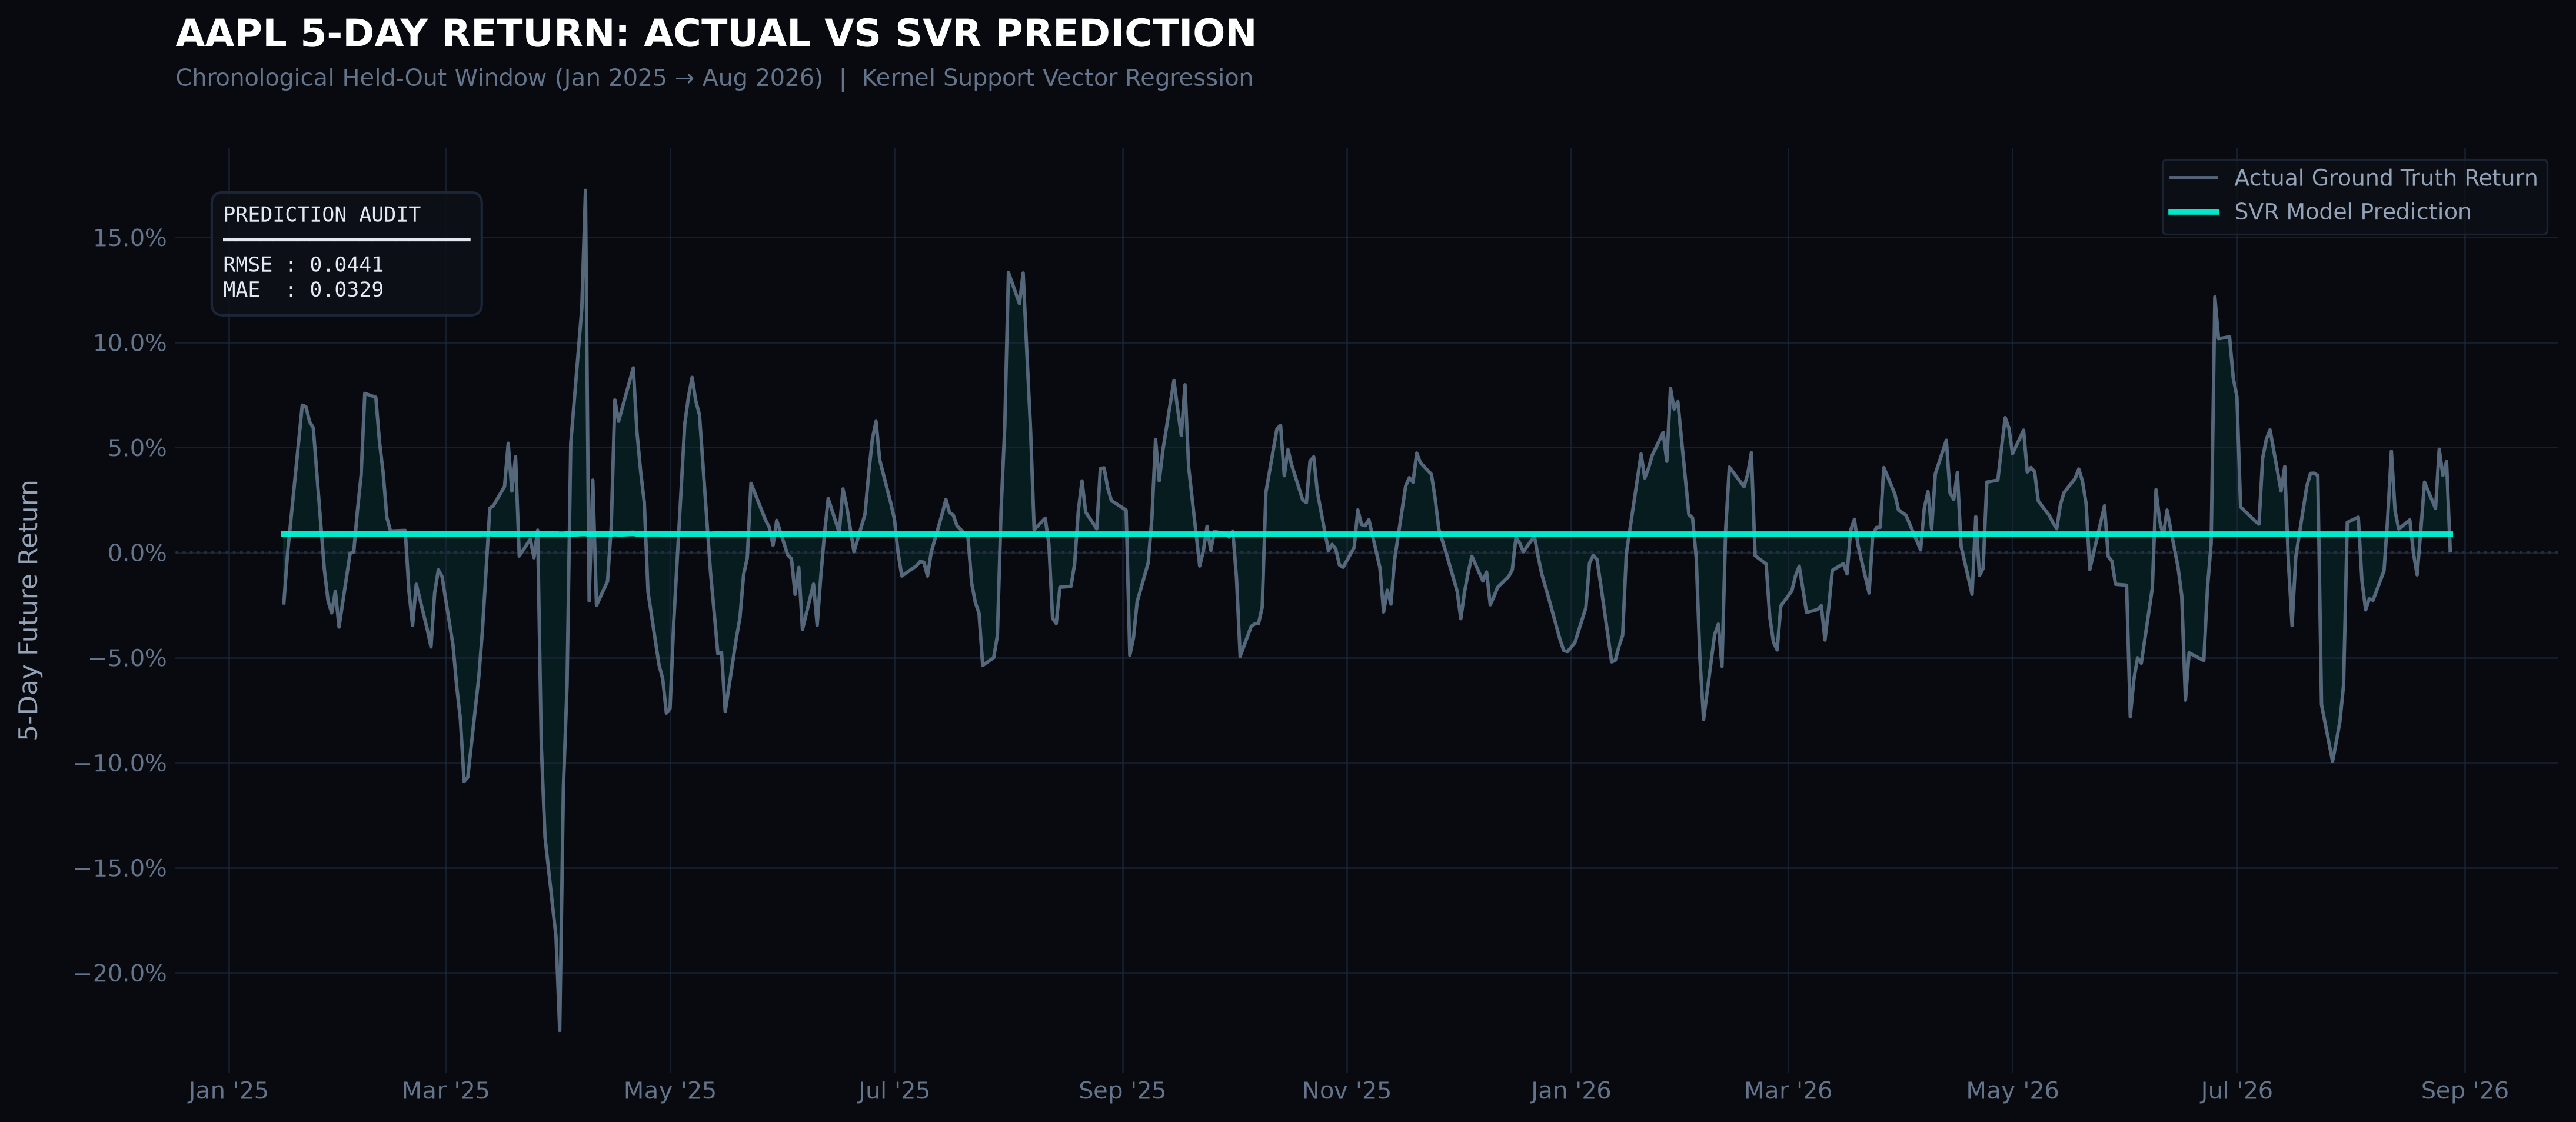

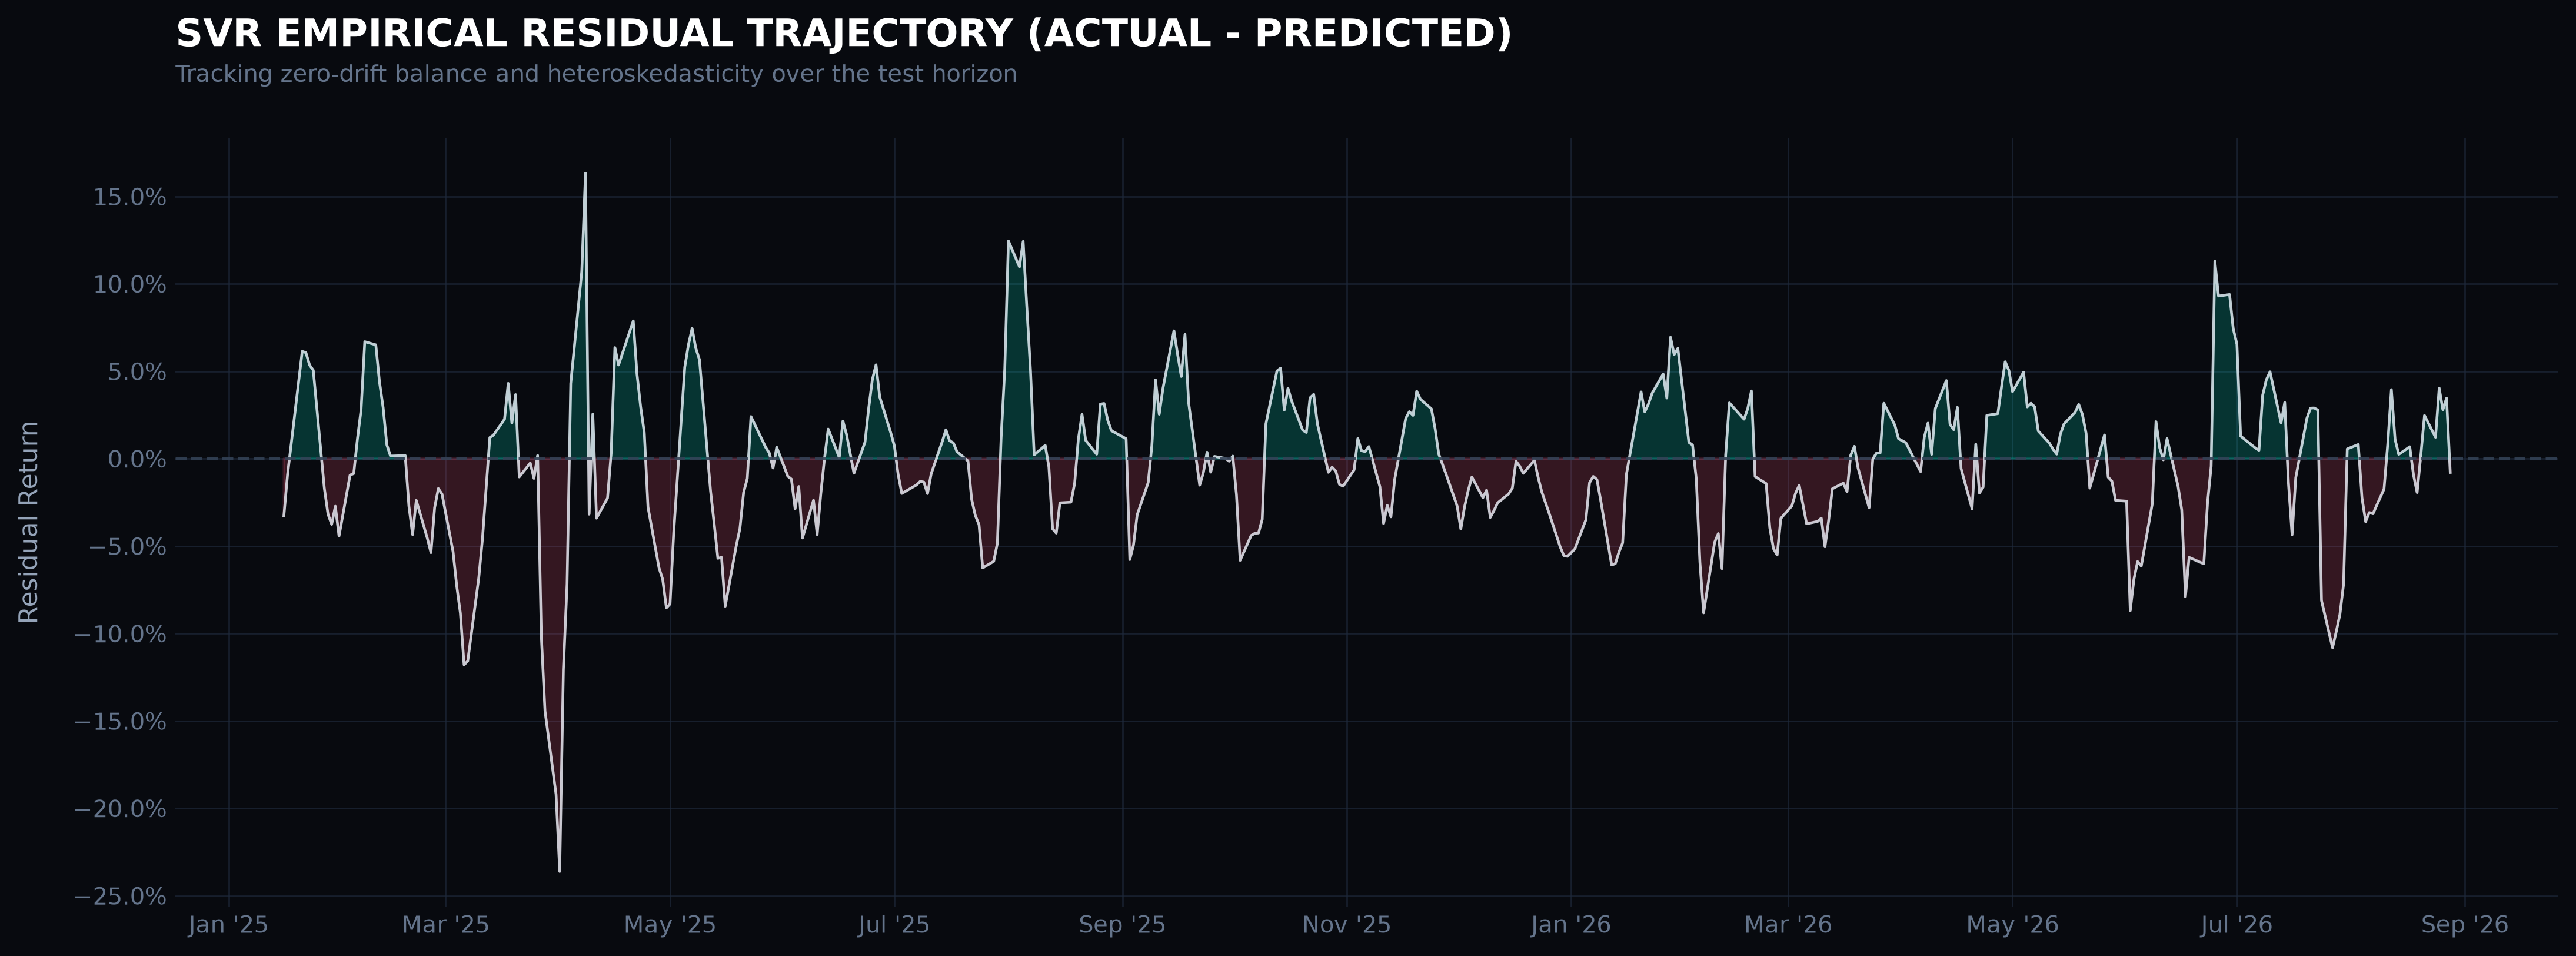

findfont: Failed to find font weight heavy, now using 700.


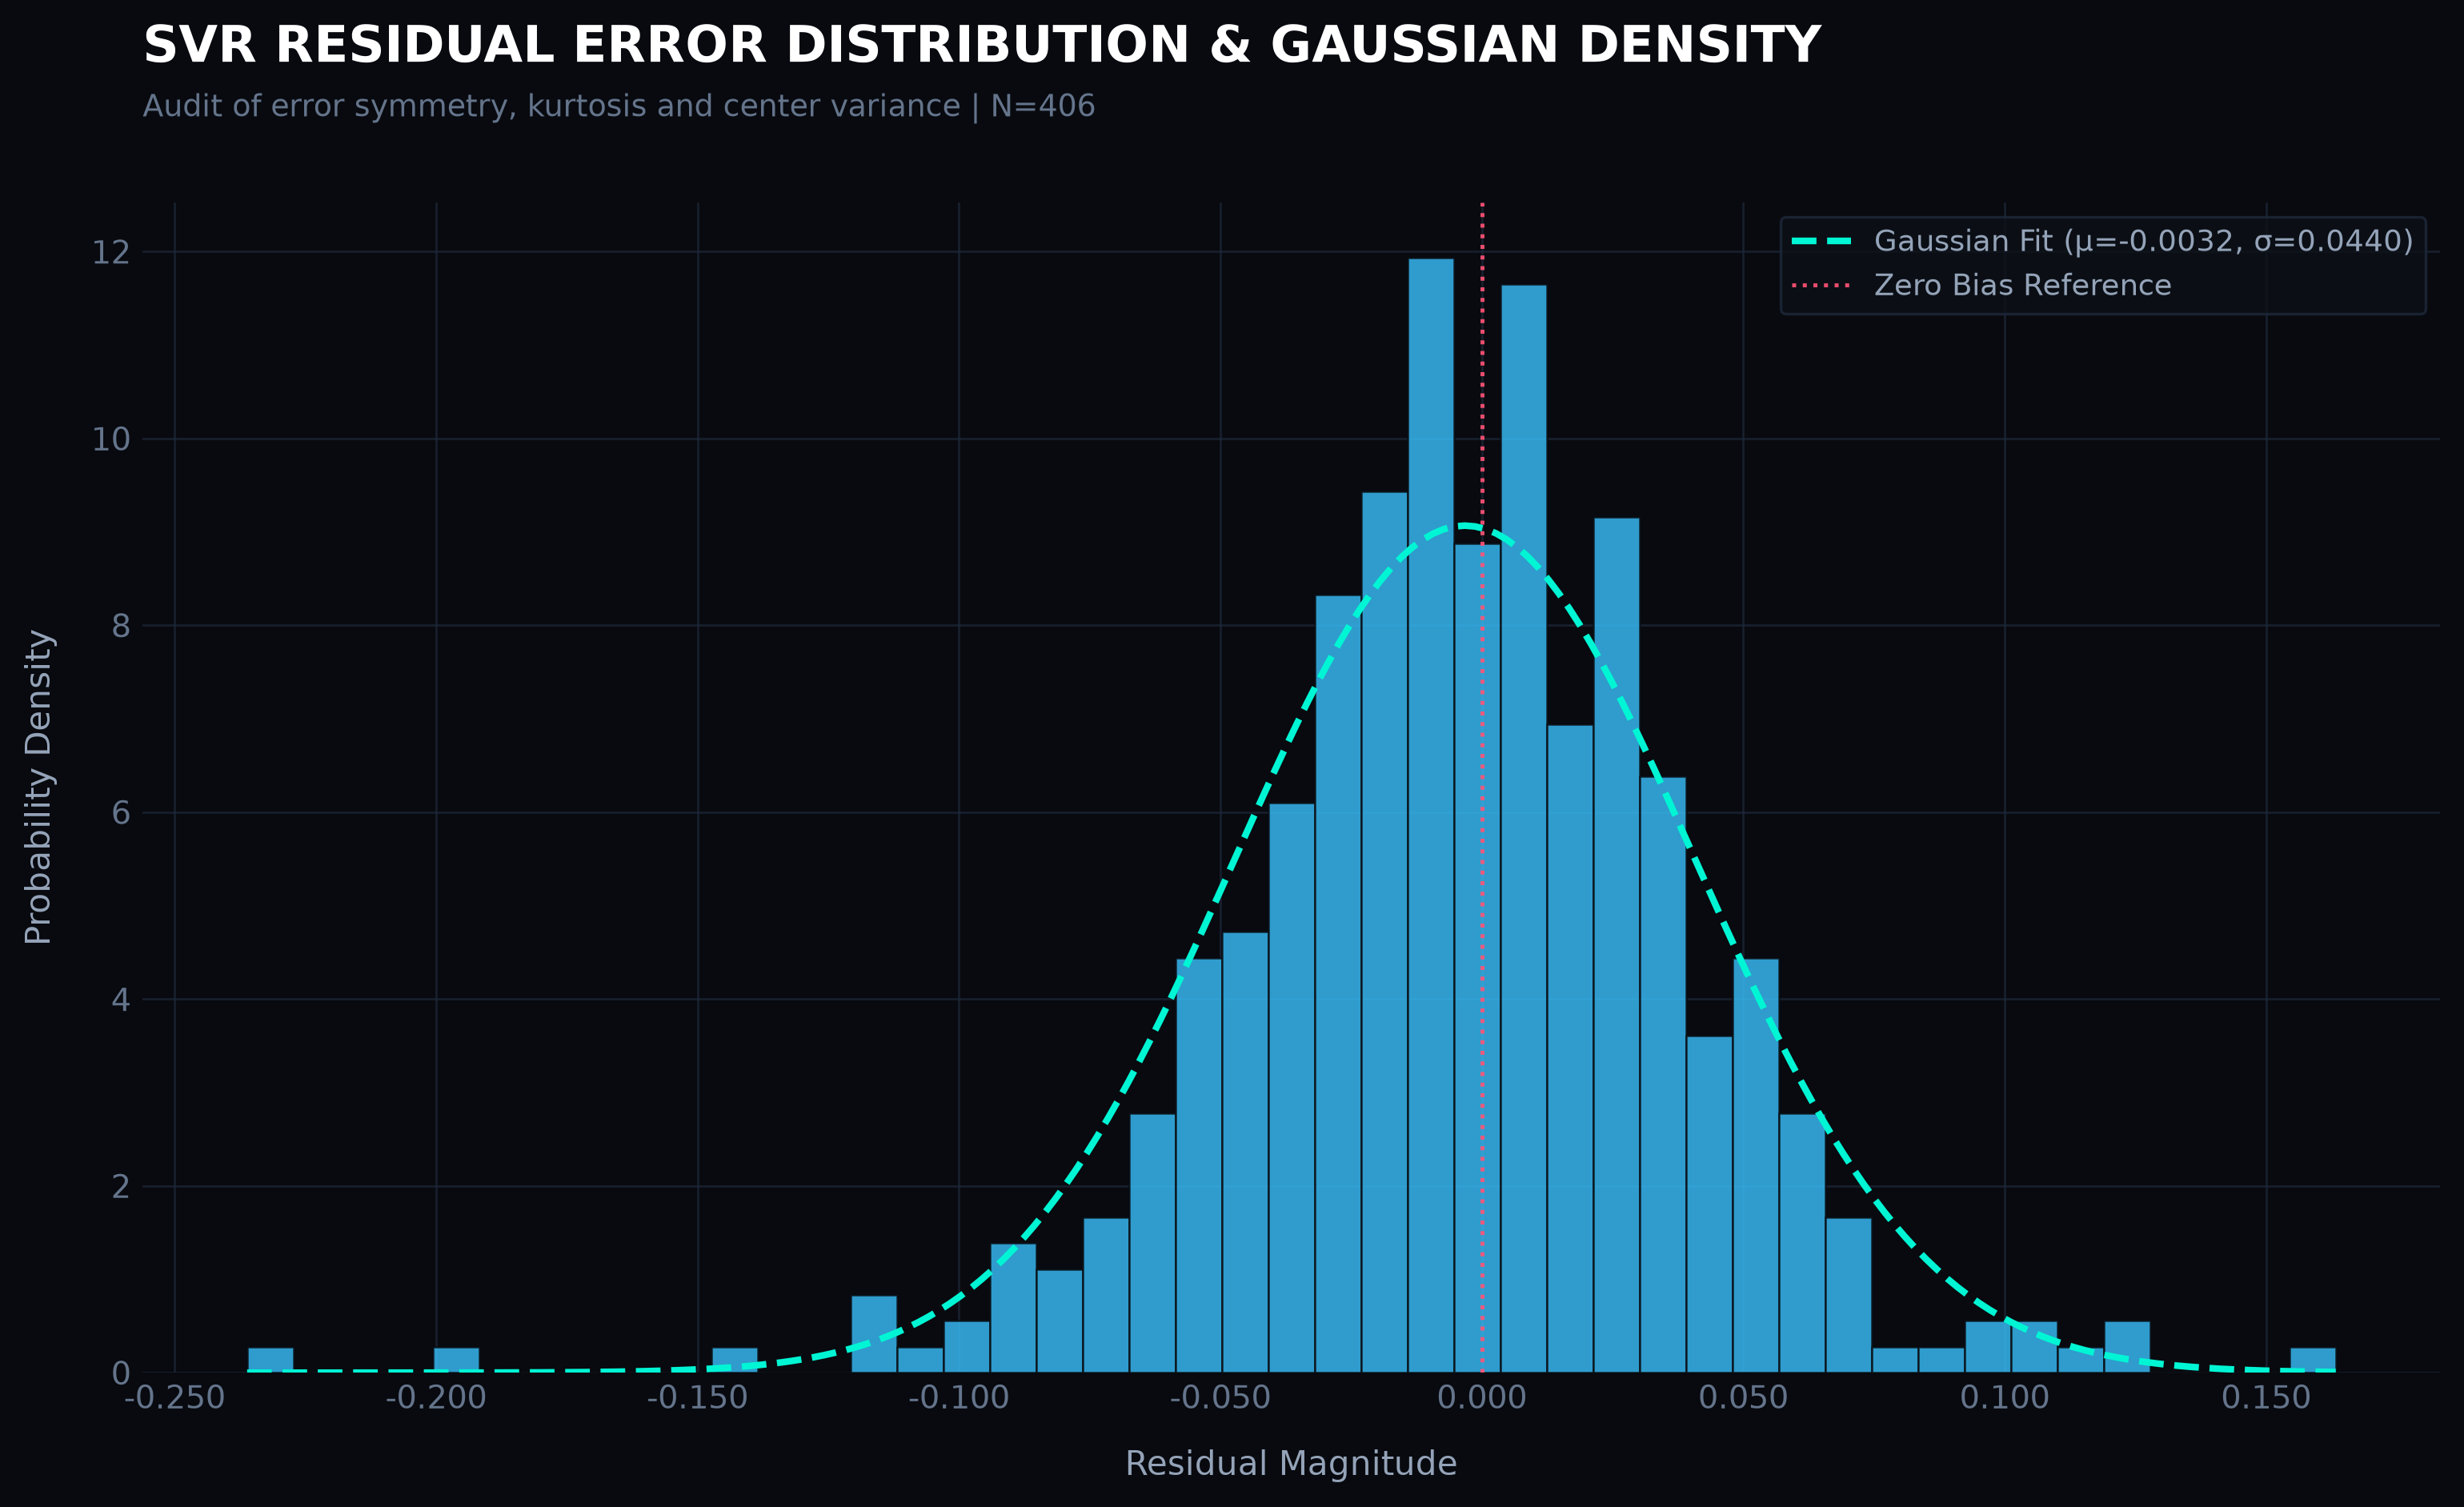

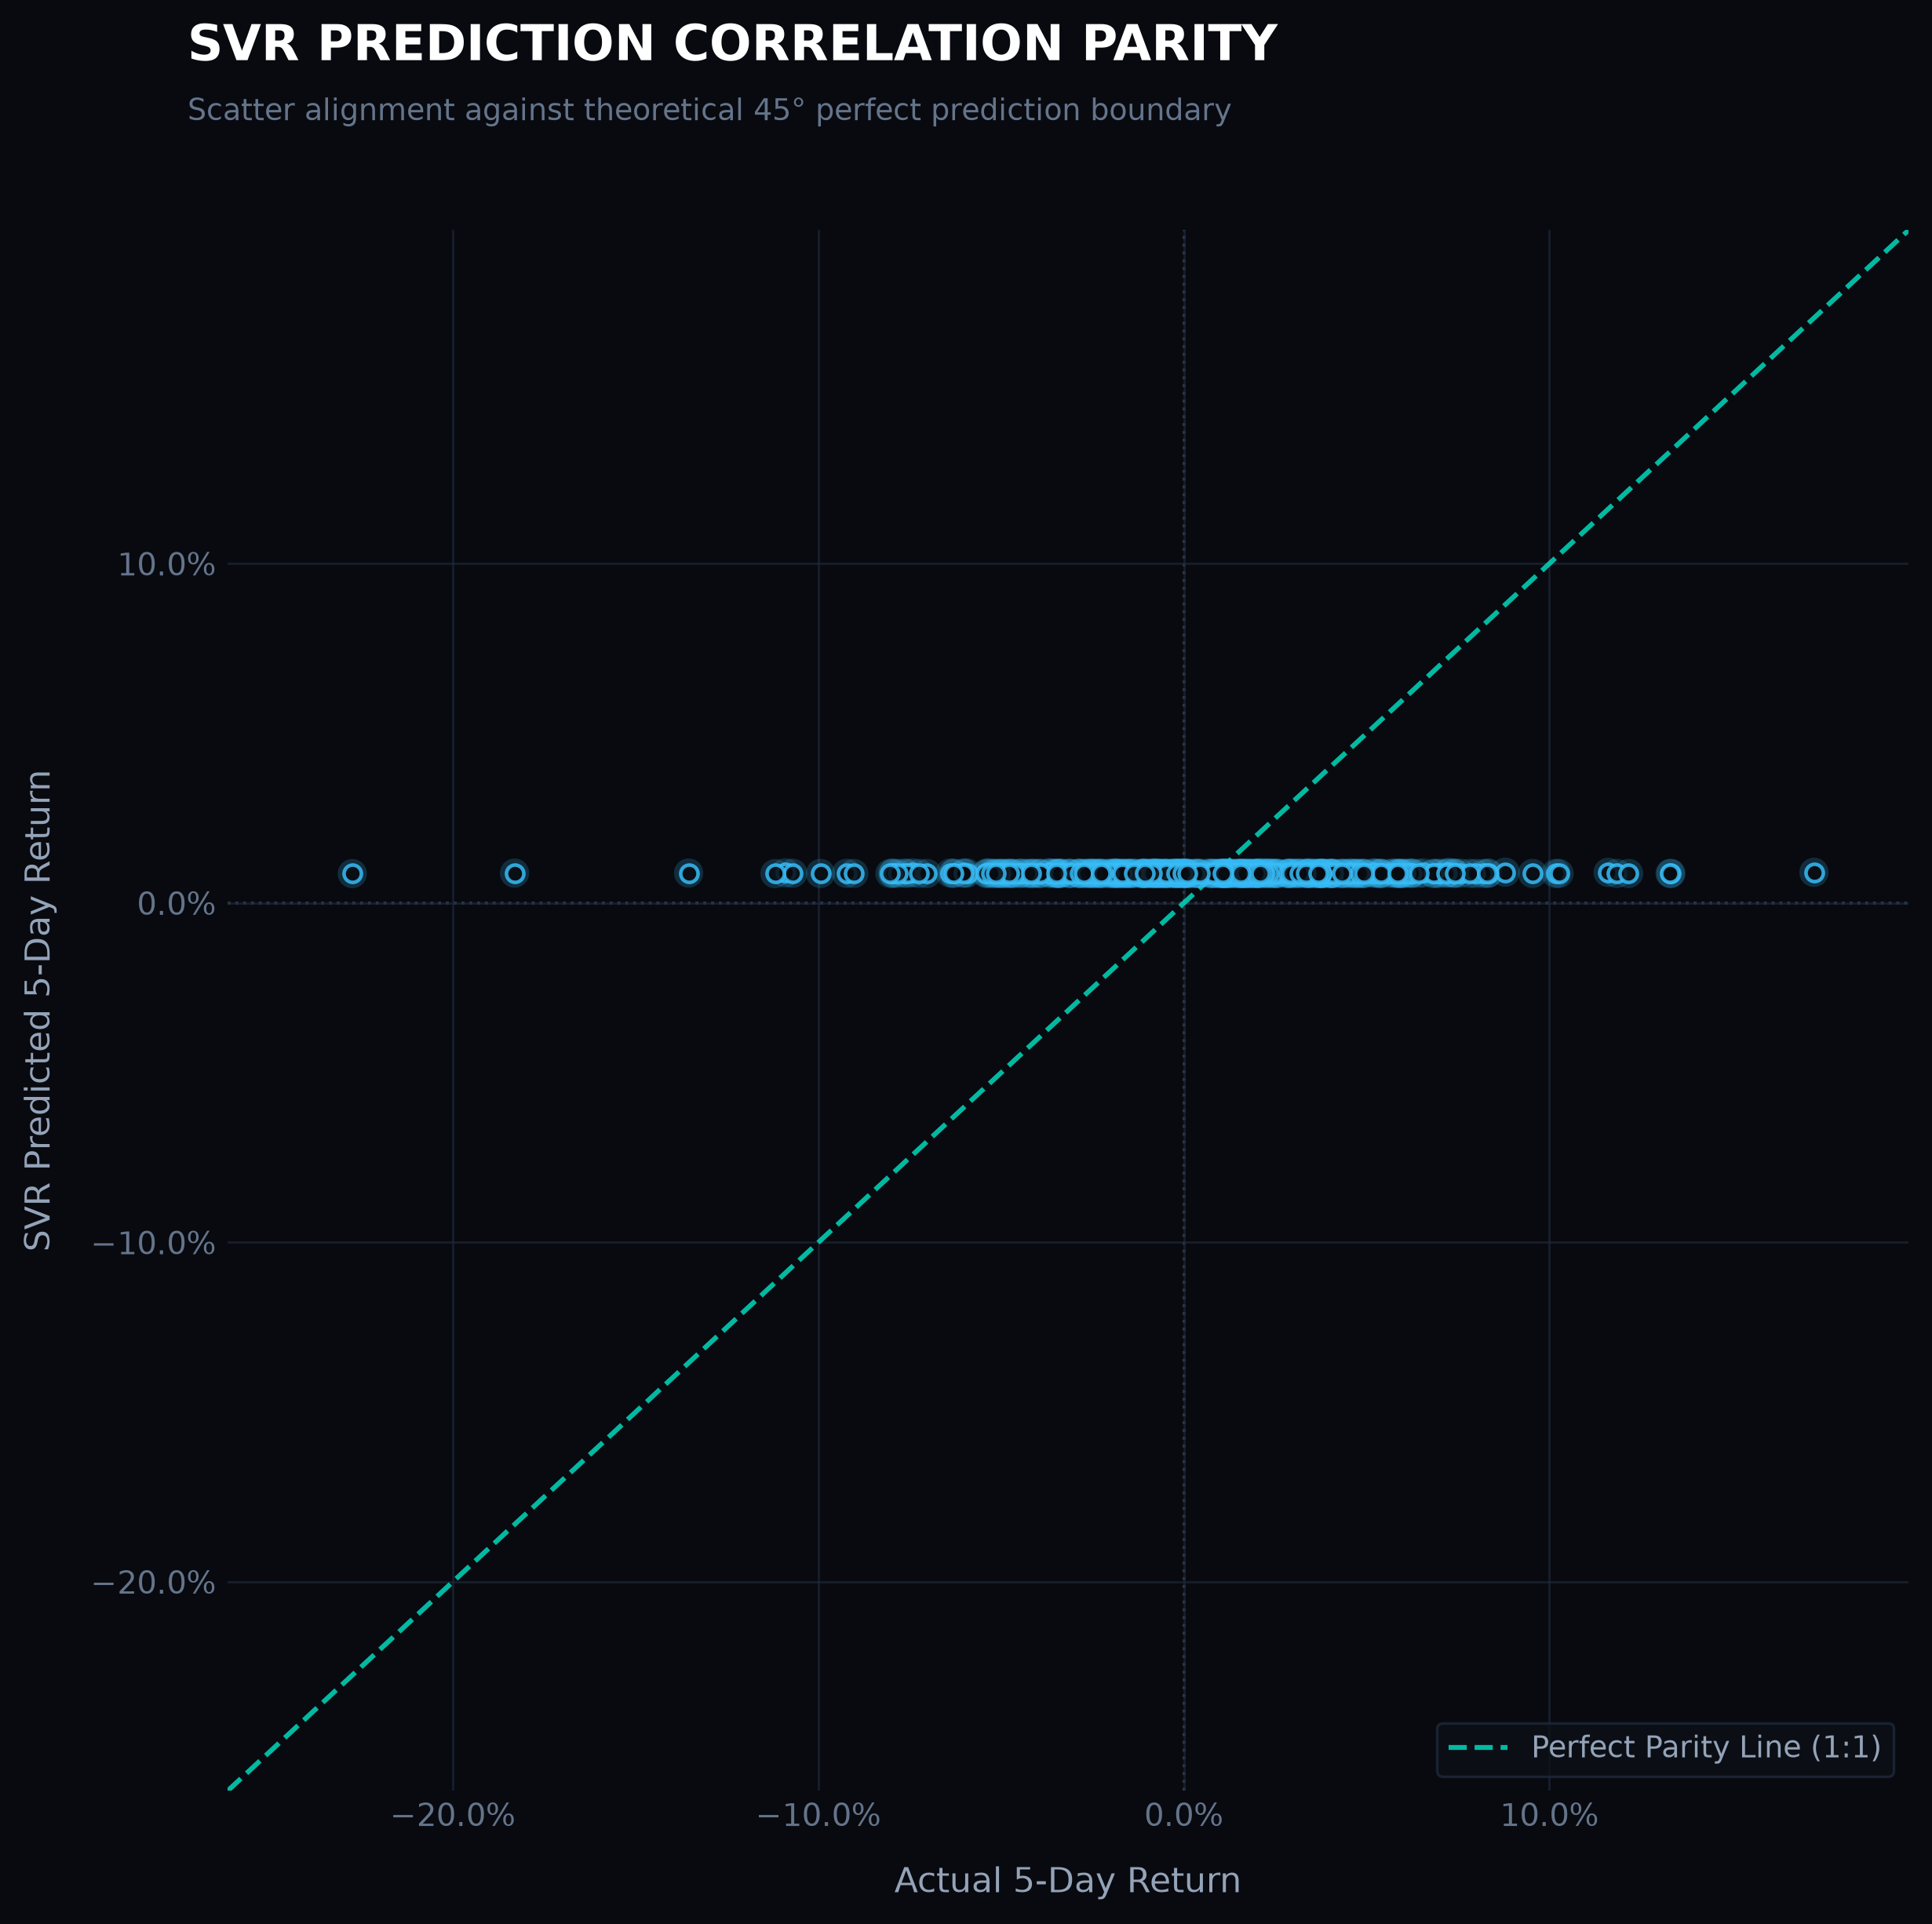

✔ SVR ADVANCED DIAGNOSTIC SUITE EXPORTED (PNG + VECTOR PDF)


,artifact,png_path,pdf_path
0,Actual vs SVR Trajectory,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...
1,Residuals Over Time,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...
2,Residual Distribution & Density,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...
3,Actual vs SVR Scatter Parity,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...,C:\Users\sun\OneDrive\Desktop\Northgate_AI_Sto...


In [39]:
# FINAL CLASSICAL ML 
# SVR Prediction & Residual Diagnostic Plots

from pathlib import Path
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

plt.style.use("dark_background")

plot_df = audit_df.copy()
if not isinstance(plot_df["date"].dtype, pd.DatetimeIndex):
    plot_df["date"] = pd.to_datetime(plot_df["date"])

RESULTS_DIR = Path(globals().get("RESULTS_DIR", "results/classical_ml"))
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

c_actual = "#64748B"   
c_svr = "#00F5D4"       
c_accent = "#38BDF8"   
c_neg = "#FF5376"     
c_pos = "#00F5D4"       
c_zero = "#334155"      

dates = plot_df["date"]
actual = plot_df["actual_future_return_5d"].values
pred = plot_df["svr_prediction"].values
residuals = plot_df["svr_residual"].values

rmse = np.sqrt(np.mean(residuals**2))
mae = np.mean(np.abs(residuals))

# Plot 1 — Actual vs SVR Prediction Over Time

fig1, ax1 = plt.subplots(figsize=(15, 6.8), dpi=300)
fig1.patch.set_facecolor("#080A0F")
ax1.set_facecolor("#080A0F")

ax1.plot(dates, actual, color=c_actual, linewidth=1.4, alpha=0.85, label="Actual Ground Truth Return", zorder=2)
ax1.plot(dates, pred, color=c_svr, linewidth=2.3, alpha=0.95, label="SVR Model Prediction", zorder=4)

ax1.fill_between(dates, pred, actual, color=c_svr, alpha=0.08, zorder=1)
ax1.axhline(0, color=c_zero, linewidth=1.1, linestyle=":", alpha=0.8, zorder=1)

fig1.text(0.06, 0.965, "AAPL 5-DAY RETURN: ACTUAL VS SVR PREDICTION", fontsize=15.5, fontweight="heavy", color="#FFFFFF", ha="left")
fig1.text(0.06, 0.932, f"Chronological Held-Out Window ({dates.iloc[0].strftime('%b %Y')} → {dates.iloc[-1].strftime('%b %Y')})  |  Kernel Support Vector Regression", fontsize=9.5, color="#64748B", ha="left")

badge_p1 = f"PREDICTION AUDIT\n━━━━━━━━━━━━━━━━━━━━\nRMSE : {rmse:.4f}\nMAE  : {mae:.4f}"
ax1.text(0.02, 0.94, badge_p1, transform=ax1.transAxes, ha="left", va="top", fontsize=8.5, fontfamily="monospace", color="#E2E8F0",
         bbox=dict(boxstyle="round,pad=0.55", fc="#0D1117", ec="#1E293B", lw=1.0, alpha=0.92), zorder=6)

ax1.grid(True, color="#1E293B", linestyle="-", linewidth=0.65, alpha=0.7)
for spine in ax1.spines.values():
    spine.set_visible(False)

ax1.tick_params(colors="#64748B", labelsize=9.5, length=0)
ax1.set_ylabel("5-Day Future Return", color="#94A3B8", fontsize=10.5, labelpad=12)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

legend1 = ax1.legend(loc="upper right", frameon=True, facecolor="#0D1117", edgecolor="#1E293B", fontsize=9.2, labelcolor="#94A3B8")
legend1.get_frame().set_linewidth(0.8)

plt.subplots_adjust(top=0.88, bottom=0.11, left=0.06, right=0.96)
actual_vs_svr_path = RESULTS_DIR / "final_classical_ml_actual_vs_svr.png"
actual_vs_svr_pdf = RESULTS_DIR / "final_classical_ml_actual_vs_svr.pdf"
fig1.savefig(actual_vs_svr_path, dpi=300, facecolor=fig1.get_facecolor(), edgecolor="none", bbox_inches="tight")
fig1.savefig(actual_vs_svr_pdf, facecolor=fig1.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.show()
plt.close(fig1)

# Plot 2 — Residuals Over Time (Color-Coded Divergence)

fig2, ax2 = plt.subplots(figsize=(15, 5.8), dpi=300)
fig2.patch.set_facecolor("#080A0F")
ax2.set_facecolor("#080A0F")

ax2.plot(dates, residuals, color="#E2E8F0", linewidth=1.1, alpha=0.85, zorder=3)
ax2.fill_between(dates, residuals, 0, where=(residuals >= 0), color=c_pos, alpha=0.18, interpolate=True, zorder=2)
ax2.fill_between(dates, residuals, 0, where=(residuals < 0), color=c_neg, alpha=0.18, interpolate=True, zorder=2)
ax2.axhline(0, color=c_zero, linewidth=1.2, linestyle="--", alpha=0.9, zorder=4)

fig2.text(0.06, 0.96, "SVR EMPIRICAL RESIDUAL TRAJECTORY (ACTUAL - PREDICTED)", fontsize=15.5, fontweight="heavy", color="#FFFFFF", ha="left")
fig2.text(0.06, 0.925, "Tracking zero-drift balance and heteroskedasticity over the test horizon", fontsize=9.5, color="#64748B", ha="left")

ax2.grid(True, color="#1E293B", linestyle="-", linewidth=0.65, alpha=0.7)
for spine in ax2.spines.values():
    spine.set_visible(False)

ax2.tick_params(colors="#64748B", labelsize=9.5, length=0)
ax2.set_ylabel("Residual Return", color="#94A3B8", fontsize=10.5, labelpad=12)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=1))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

plt.subplots_adjust(top=0.87, bottom=0.12, left=0.06, right=0.96)
residual_time_path = RESULTS_DIR / "final_classical_ml_residuals_over_time.png"
residual_time_pdf = RESULTS_DIR / "final_classical_ml_residuals_over_time.pdf"
fig2.savefig(residual_time_path, dpi=300, facecolor=fig2.get_facecolor(), edgecolor="none", bbox_inches="tight")
fig2.savefig(residual_time_pdf, facecolor=fig2.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.show()
plt.close(fig2)

# Plot 3 — Residual Distribution & Gaussian Density Fit

fig3, ax3 = plt.subplots(figsize=(11, 6.5), dpi=300)
fig3.patch.set_facecolor("#080A0F")
ax3.set_facecolor("#080A0F")

counts, bins, patches = ax3.hist(residuals, bins=45, density=True, color=c_accent, edgecolor="#080A0F", linewidth=0.6, alpha=0.82, zorder=3)

mu, std = np.mean(residuals), np.std(residuals)
x_norm = np.linspace(min(residuals), max(residuals), 200)
p_norm = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_norm - mu) / std)**2)

ax3.plot(x_norm, p_norm, color=c_svr, linewidth=2.0, linestyle="--", label=f"Gaussian Fit (μ={mu:.4f}, σ={std:.4f})", zorder=5)
ax3.axvline(0, color="#FF5376", linewidth=1.2, linestyle=":", alpha=0.9, label="Zero Bias Reference", zorder=4)

fig3.text(0.08, 0.96, "SVR RESIDUAL ERROR DISTRIBUTION & GAUSSIAN DENSITY", fontsize=15, fontweight="heavy", color="#FFFFFF", ha="left")
fig3.text(0.08, 0.925, f"Audit of error symmetry, kurtosis and center variance | N={len(residuals)}", fontsize=9.2, color="#64748B", ha="left")

ax3.grid(True, color="#1E293B", linestyle="-", linewidth=0.65, alpha=0.7)
for spine in ax3.spines.values():
    spine.set_visible(False)

ax3.tick_params(colors="#64748B", labelsize=9.5, length=0)
ax3.set_xlabel("Residual Magnitude", color="#94A3B8", fontsize=10, labelpad=10)
ax3.set_ylabel("Probability Density", color="#94A3B8", fontsize=10, labelpad=10)
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter("%.3f"))

legend3 = ax3.legend(loc="upper right", frameon=True, facecolor="#0D1117", edgecolor="#1E293B", fontsize=8.8, labelcolor="#94A3B8")
legend3.get_frame().set_linewidth(0.8)

plt.subplots_adjust(top=0.87, bottom=0.12, left=0.08, right=0.95)
residual_distribution_path = RESULTS_DIR / "final_classical_ml_residual_distribution.png"
residual_distribution_pdf = RESULTS_DIR / "final_classical_ml_residual_distribution.pdf"
fig3.savefig(residual_distribution_path, dpi=300, facecolor=fig3.get_facecolor(), edgecolor="none", bbox_inches="tight")
fig3.savefig(residual_distribution_pdf, facecolor=fig3.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.show()
plt.close(fig3)

# Plot 4 — Actual vs Predicted Scatter (Calibration Quadrants)

fig4, ax4 = plt.subplots(figsize=(8.5, 8.5), dpi=300)
fig4.patch.set_facecolor("#080A0F")
ax4.set_facecolor("#080A0F")

min_val = min(actual.min(), pred.min()) * 1.15
max_val = max(actual.max(), pred.max()) * 1.15

ax4.plot([min_val, max_val], [min_val, max_val], color=c_svr, linestyle="--", linewidth=1.5, alpha=0.75, label="Perfect Parity Line (1:1)", zorder=2)
ax4.axhline(0, color=c_zero, linewidth=0.9, linestyle=":", zorder=1)
ax4.axvline(0, color=c_zero, linewidth=0.9, linestyle=":", zorder=1)

ax4.scatter(actual, pred, s=80, color=c_accent, alpha=0.20, edgecolors="none", zorder=3)
ax4.scatter(actual, pred, s=28, color="#080A0F", edgecolors=c_accent, linewidths=1.1, alpha=0.85, zorder=4)

fig4.text(0.08, 0.965, "SVR PREDICTION CORRELATION PARITY", fontsize=15, fontweight="heavy", color="#FFFFFF", ha="left")
fig4.text(0.08, 0.935, "Scatter alignment against theoretical 45° perfect prediction boundary", fontsize=9.2, color="#64748B", ha="left")

ax4.grid(True, color="#1E293B", linestyle="-", linewidth=0.65, alpha=0.7)
for spine in ax4.spines.values():
    spine.set_visible(False)

ax4.tick_params(colors="#64748B", labelsize=9.5, length=0)
ax4.set_xlabel("Actual 5-Day Return", color="#94A3B8", fontsize=10.5, labelpad=10)
ax4.set_ylabel("SVR Predicted 5-Day Return", color="#94A3B8", fontsize=10.5, labelpad=10)

ax4.set_xlim(min_val, max_val)
ax4.set_ylim(min_val, max_val)
ax4.xaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=1))
ax4.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=1))

legend4 = ax4.legend(loc="lower right", frameon=True, facecolor="#0D1117", edgecolor="#1E293B", fontsize=9, labelcolor="#94A3B8")
legend4.get_frame().set_linewidth(0.8)

plt.subplots_adjust(top=0.88, bottom=0.10, left=0.10, right=0.94)
scatter_path = RESULTS_DIR / "final_classical_ml_actual_vs_svr_scatter.png"
scatter_pdf = RESULTS_DIR / "final_classical_ml_actual_vs_svr_scatter.pdf"
fig4.savefig(scatter_path, dpi=300, facecolor=fig4.get_facecolor(), edgecolor="none", bbox_inches="tight")
fig4.savefig(scatter_pdf, facecolor=fig4.get_facecolor(), edgecolor="none", bbox_inches="tight")
plt.show()
plt.close(fig4)

# Manifest & Artifact Logging

plot_artifacts = pd.DataFrame({
    "artifact": [
        "Actual vs SVR Trajectory",
        "Residuals Over Time",
        "Residual Distribution & Density",
        "Actual vs SVR Scatter Parity",],
    "png_path": [
        str(actual_vs_svr_path),
        str(residual_time_path),
        str(residual_distribution_path),
        str(scatter_path),],
    "pdf_path": [
        str(actual_vs_svr_pdf),
        str(residual_time_pdf),
        str(residual_distribution_pdf),
        str(scatter_pdf),],})

plot_artifacts_path = RESULTS_DIR / "final_classical_ml_diagnostic_plot_manifest.csv"
plot_artifacts.to_csv(plot_artifacts_path, index=False)

print("=" * 80)
print("✔ SVR ADVANCED DIAGNOSTIC SUITE EXPORTED (PNG + VECTOR PDF)")
print("=" * 80)
display(plot_artifacts)

In [40]:
# FINAL CLASSICAL ML
# Statistical Residual & Error Audit

from scipy import stats

# Residual statistics

residuals = audit_df["svr_residual"]

residual_statistics = {
    "count": len(residuals),
    "mean": residuals.mean(),
    "median": residuals.median(),
    "std": residuals.std(),
    "min": residuals.min(),
    "max": residuals.max(),
    "q01": residuals.quantile(0.01),
    "q05": residuals.quantile(0.05),
    "q25": residuals.quantile(0.25),
    "q75": residuals.quantile(0.75),
    "q95": residuals.quantile(0.95),
    "q99": residuals.quantile(0.99),
    "MAE": residuals.abs().mean(),
    "RMSE": np.sqrt(np.mean(residuals ** 2))}

residual_stats_df = pd.DataFrame(
    [residual_statistics])

# Error comparison: SVR vs Naive

actual = audit_df["actual_future_return_5d"]

svr_abs_error = (
    actual - audit_df["svr_prediction"]
).abs()

naive_abs_error = (
    actual - audit_df["naive_random_walk_prediction"]
).abs()

audit_df["svr_absolute_error"] = svr_abs_error
audit_df["naive_absolute_error"] = naive_abs_error

audit_df["svr_better_than_naive"] = (
    svr_abs_error < naive_abs_error)

svr_better_count = (
    audit_df["svr_better_than_naive"].sum())

naive_better_count = (
    (~audit_df["svr_better_than_naive"]).sum())

# Paired error difference

error_difference = (
    naive_abs_error - svr_abs_error)

mean_error_difference = error_difference.mean()

# Paired Wilcoxon test

try:
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(
        svr_abs_error,
        naive_abs_error,
        alternative="two-sided")
except ValueError:
    wilcoxon_stat = np.nan
    wilcoxon_p = np.nan

# Residual normality diagnostics

try:
    shapiro_stat, shapiro_p = stats.shapiro(
        residuals)
except ValueError:
    shapiro_stat = np.nan
    shapiro_p = np.nan

skewness = stats.skew(residuals)
kurtosis_excess = stats.kurtosis(
    residuals,
    fisher=True)

# Directional baseline

actual_positive_rate = (
    (actual > 0).mean() * 100)

svr_positive_rate = (
    (audit_df["svr_prediction"] > 0).mean() * 100)

# Largest absolute errors

largest_errors = (
    audit_df[
        [
            "date",
            "actual_future_return_5d",
            "svr_prediction",
            "svr_residual",
            "svr_absolute_error"]]
    .sort_values(
        "svr_absolute_error",
        ascending=False)
    .head(10)
    .reset_index(drop=True))

print("=" * 70)
print("FINAL CLASSICAL ML — STATISTICAL ERROR AUDIT")
print("=" * 70)

print("\nResidual statistics:")
display(residual_stats_df)

print("\nSVR vs Naive absolute-error comparison:")
print(f"SVR lower-error observations   : {svr_better_count}")
print(f"Naive lower/equal observations : {naive_better_count}")
print(
    f"SVR lower-error share          : "
    f"{svr_better_count / len(audit_df) * 100:.2f}%")

print(
    f"\nMean (Naive AE - SVR AE)       : "
    f"{mean_error_difference:.8f}")

print("\nPaired Wilcoxon test:")
print(f"Statistic                      : {wilcoxon_stat}")
print(f"p-value                        : {wilcoxon_p}")

print("\nResidual distribution:")
print(f"Skewness                       : {skewness:.6f}")
print(f"Excess kurtosis                : {kurtosis_excess:.6f}")

print("\nShapiro-Wilk diagnostic:")
print(f"Statistic                      : {shapiro_stat}")
print(f"p-value                        : {shapiro_p}")

print("\nDirectional baseline:")
print(f"Actual positive rate           : {actual_positive_rate:.2f}%")
print(f"SVR positive prediction rate   : {svr_positive_rate:.2f}%")

print("\nLargest SVR absolute errors:")
display(largest_errors)

# Save statistical audit

statistical_audit = pd.DataFrame({
    "metric": [
        "observations",
        "residual_mean",
        "residual_median",
        "residual_std",
        "residual_min",
        "residual_max",
        "residual_q01",
        "residual_q05",
        "residual_q25",
        "residual_q75",
        "residual_q95",
        "residual_q99",
        "MAE",
        "RMSE",
        "SVR_lower_error_count",
        "Naive_lower_or_equal_error_count",
        "SVR_lower_error_share_pct",
        "mean_naive_abs_error_minus_svr_abs_error",
        "wilcoxon_statistic",
        "wilcoxon_p_value",
        "residual_skewness",
        "residual_excess_kurtosis",
        "shapiro_statistic",
        "shapiro_p_value",
        "actual_positive_rate_pct",
        "svr_positive_prediction_rate_pct"],

    "value": [
        len(residuals),
        residuals.mean(),
        residuals.median(),
        residuals.std(),
        residuals.min(),
        residuals.max(),
        residuals.quantile(0.01),
        residuals.quantile(0.05),
        residuals.quantile(0.25),
        residuals.quantile(0.75),
        residuals.quantile(0.95),
        residuals.quantile(0.99),
        svr_abs_error.mean(),
        np.sqrt(np.mean((actual - audit_df["svr_prediction"]) ** 2)),
        svr_better_count,
        naive_better_count,
        svr_better_count / len(audit_df) * 100,
        mean_error_difference,
        wilcoxon_stat,
        wilcoxon_p,
        skewness,
        kurtosis_excess,
        shapiro_stat,
        shapiro_p,
        actual_positive_rate,
        svr_positive_rate]})

statistical_audit_path = (
    RESULTS_DIR /
    "final_classical_ml_statistical_error_audit.csv")

largest_errors_path = (
    RESULTS_DIR /
    "final_classical_ml_largest_svr_errors.csv")

statistical_audit.to_csv(
    statistical_audit_path,
    index=False)

largest_errors.to_csv(
    largest_errors_path,
    index=False)

print("\n" + "=" * 70)
print("✅ STATISTICAL AUDIT SAVED")
print("=" * 70)

print(statistical_audit_path)
print(largest_errors_path)

FINAL CLASSICAL ML — STATISTICAL ERROR AUDIT

Residual statistics:


,count,mean,median,std,min,max,q01,q05,q25,q75,q95,q99,MAE,RMSE
0,406,-0.003249,-0.001395,0.044058,-0.236148,0.163319,-0.117794,-0.070989,-0.027509,0.02477,0.063192,0.109597,0.03291,0.044123



SVR vs Naive absolute-error comparison:
SVR lower-error observations   : 208
Naive lower/equal observations : 198
SVR lower-error share          : 51.23%

Mean (Naive AE - SVR AE)       : 0.00026806

Paired Wilcoxon test:
Statistic                      : 39706.0
p-value                        : 0.4976626503559314

Residual distribution:
Skewness                       : -0.434574
Excess kurtosis                : 2.918677

Shapiro-Wilk diagnostic:
Statistic                      : 0.9703174842066867
p-value                        : 2.4066232233646064e-07

Directional baseline:
Actual positive rate           : 55.17%
SVR positive prediction rate   : 100.00%

Largest SVR absolute errors:


,date,actual_future_return_5d,svr_prediction,svr_residual,svr_absolute_error
0,2025-04-01,-0.227474,0.008673,-0.236148,0.236148
1,2025-03-31,-0.183091,0.008827,-0.191918,0.191918
2,2025-04-08,0.172370,0.009051,0.163319,0.163319
3,2025-03-28,-0.135475,0.008846,-0.144321,0.144321
4,2025-08-01,0.133264,0.008723,0.124541,0.124541
5,2025-08-05,0.133011,0.008723,0.124289,0.124289
6,2025-04-02,-0.111841,0.008678,-0.120519,0.120519
7,2025-03-06,-0.108996,0.008904,-0.117900,0.117900
8,2025-03-07,-0.106998,0.008773,-0.115771,0.115771
9,2026-06-25,0.121679,0.008722,0.112957,0.112957



✅ STATISTICAL AUDIT SAVED
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_classical_ml_statistical_error_audit.csv
C:\Users\sun\OneDrive\Desktop\Northgate_AI_Stock_Predictor\results\classical_ml\final_classical_ml_largest_svr_errors.csv
